# GUPPY PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------

main_dir = Path(".").resolve()
#timepoints = ["Preinduction", "W1", "W2", "W3"]

timepoints = ["Preinduction", "W1", "W2"]
#timepoints = ["Preinduction"]

#focus on preinduction for now to save time 
#timepoints = ["Preinduction"]
#timepoints = ["Preinduction", "W3"]


# Center-point zone substrings (FLEXIBLE MATCHING)
nosepoint_substrings = [
    "Arena / Center-point",         # NEW
    "O1_prevC1 / Center-point",
    "O2_prevC2 / Center-point",
    "O1_round / Center-point",
    "O2_round / Center-point",
    "C1_prevO1 / Center-point",
    "C2_prevO2 / Center-point",
    "NeutralZone / Center-point",
]

# Fixed colors keyed by inner substring (order doesn’t matter)
zone_colors = {
    "Arena / Center-point": "#999999",         # grey
    "O1_prevC1 / Center-point": "#E41A1C",     # red
    "O2_prevC2 / Center-point": "#377EB8",     # blue
    "O1_round / Center-pointnt": "#E41A1C",     # red
    "O2_round / Center-pointnt": "#377EB8",     # blue
    "C1_prevO1 / Center-point": "#4DAF4A",     # green
    "C2_prevO2 / Center-point": "#984EA3",     # purple
    "NeutralZone / Center-point": "#FF7F00",   # orange
}

video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

# with the new mice
def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423", "398", "400", "459", "450", "584", "597"}:
        return "NE"
    if id_clean in {"374", "429", "461", "463", "402"}:
        return "WT"
    return None

def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id



def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = None
    for p in fp_folder.glob("*.csv"):
        if fp_id.lower() in p.name.lower():
            #fp_csv = p
            fil = fp_id + '.csv'
            fp_csv = fp_folder / fil
            break
    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            #ts_csv = p
            import os
            directory, filename = os.path.split(p)

            # Remove leading "._" if present
            new_filename = filename.lstrip("._") if filename.startswith("._") else filename

            # Join back together
            new_path = os.path.join(directory, new_filename)
            
            ts_csv = new_path
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv



def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    """Robust detection of video ON/OFF timestamps."""
    # Time column
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    # Digital channel
    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    # No digital info → use full recording
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    # If no transitions → full interval
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    # Use first True and first False
    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    # Fallback
    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)

    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Time_s
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    # Flexible matching of Center-point zone columns
    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break

    if not matched_cols:
        raise ValueError(f"No Center-point zones found in {eth_path.name}")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        mask = eth[beh] == 1
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"]
        ends = eth.loc[diff == -1, "Time_s"]

        if mask.iloc[0]:
            starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
        if mask.iloc[-1]:
            ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

        for s, e in zip(starts, ends):
            segments.append(
                {"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e),
                 "Duration_s": float(e - s)}
            )
    return pd.DataFrame(segments)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    # LED 1 – isosbestic
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 – GCaMP
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # Ethogram
    for i, beh in enumerate(beh_cols):
        color = _guess_zone_color(beh)
        subset = eth_timeline[eth_timeline["Behavior"] == beh]
        for _, row in subset.iterrows():
            axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
                         height=0.6, color=color)

    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (Center-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)


# ==========================================================
# Main loop
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # Load FP
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            # Align timestamps
            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            # Detect channel
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
            }

            # Load EthoVision
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols) #timeline for behaviours

            # added this to store timeline to use in kernel smoothing in later code blocks
            # --- inside your main loop, after timeline is created ---
            #timeline = _ethogram_segments(eth, matched_cols)  # already there

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,   # <-- NEW: store timeline
                "beh_cols": matched_cols
            }


            # Plot trial
            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")



=== Processing timepoint: Preinduction ===
✔ Raw data-EPM_Preinduction_cohort2_FP-Trial     1.xlsx → ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1_zones.png

=== Processing timepoint: W1 ===
[WARN] No Raw data-*.xlsx files in /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/PFC/EPM_Center_point/Test_noise_461/W1/Export files

=== Processing timepoint: W2 ===
[WARN] No Raw data-*.xlsx files in /Users/annastuckert/Downloads/Git_repositories/FP_behaviour_analysis/PFC/EPM_Center_point/Test_noise_461/W2/Export files


In [2]:
#pkl_path = r'C:\Users\soren\Documents\EPM_Combined\pickles'
#
#import pickle
#
#pickle.dump(fp_traces, open('C:/Users/soren/Documents/EPM_Combined/pickles/fp_traces.pkl', 'wb'))
#pickle.dump(fp_trim, open('C:/Users/soren/Documents/EPM_Combined/pickles/fp_trim.pkl', 'wb'))
#pickle.dump(timeline, open('C:/Users/soren/Documents/EPM_Combined/pickles/timeline.pkl', 'wb'))
#pickle.dump(eth, open('C:/Users/soren/Documents/EPM_Combined/pickles/eth.pkl', 'wb'))
#pickle.dump(gcamp_df, open('C:/Users/soren/Documents/EPM_Combined/pickles/gcamp_df.pkl', 'wb'))
#pickle.dump(iso_df, open('C:/Users/soren/Documents/EPM_Combined/pickles/iso_df.pkl', 'wb'))
#pickle.dump(matched_cols, open('C:/Users/soren/Documents/EPM_Combined/pickles/matched_cols.pkl', 'wb'))
#pickle.dump(nosepoint_substrings, open('C:/Users/soren/Documents/EPM_Combined/pickles/nosepoint_substrings.pkl', 'wb'))
#pickle.dump(timepoints, open('C:/Users/soren/Documents/EPM_Combined/pickles/timepoints.pkl', 'wb'))
#pickle.dump(ts, open('C:/Users/soren/Documents/EPM_Combined/pickles/ts.pkl', 'wb'))
#pickle.dump(zone_colors, open('C:/Users/soren/Documents/EPM_Combined/pickles/zone_colors.pkl', 'wb'))
#

In [3]:
list(fp_traces.keys())[:1]
first_key = next(iter(fp_traces))
fp_traces[first_key]


{'iso':        Time_video  G0_iso415
 0         0.02000   0.025181
 1         0.06000   0.025314
 2         0.10000   0.025165
 3         0.14000   0.025175
 4         0.18000   0.025189
 ...           ...        ...
 14993   599.73984   0.024748
 14994   599.77984   0.024760
 14995   599.81984   0.024750
 14996   599.85984   0.024802
 14997   599.89984   0.024775
 
 [14998 rows x 2 columns],
 'gcamp':        Time_video  G0_gcamp470
 0         0.00000     0.029073
 1         0.04000     0.029003
 2         0.08000     0.029127
 3         0.12000     0.029096
 4         0.16000     0.029093
 ...           ...          ...
 14993   599.71984     0.028504
 14994   599.75984     0.028555
 14995   599.79984     0.028511
 14996   599.83984     0.028540
 14997   599.87984     0.028558
 
 [14998 rows x 2 columns],
 'mouse_id': '461',
 'genotype': 'WT',
 'timeline':                                  Behavior  Start_time_s  End_time_s  \
 0         In zone 2(Arena / Center-point)         0.000   

In [4]:
excluded_ids = {}

fp_traces = {
    k: v for k, v in fp_traces.items()
    if v["mouse_id"] not in excluded_ids
}

import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()

fp_traces_df["mouse_id"].unique()

array(['461'], dtype=object)

In [5]:
import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()


,iso,gcamp,mouse_id,genotype,timeline,beh_cols
Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1,Time_video G0_iso415 0 0.02000...,Time_video G0_gcamp470 0 0.000...,461,WT,Behavior Sta...,"[In zone 2(Arena / Center-point), In zone 2(O1..."


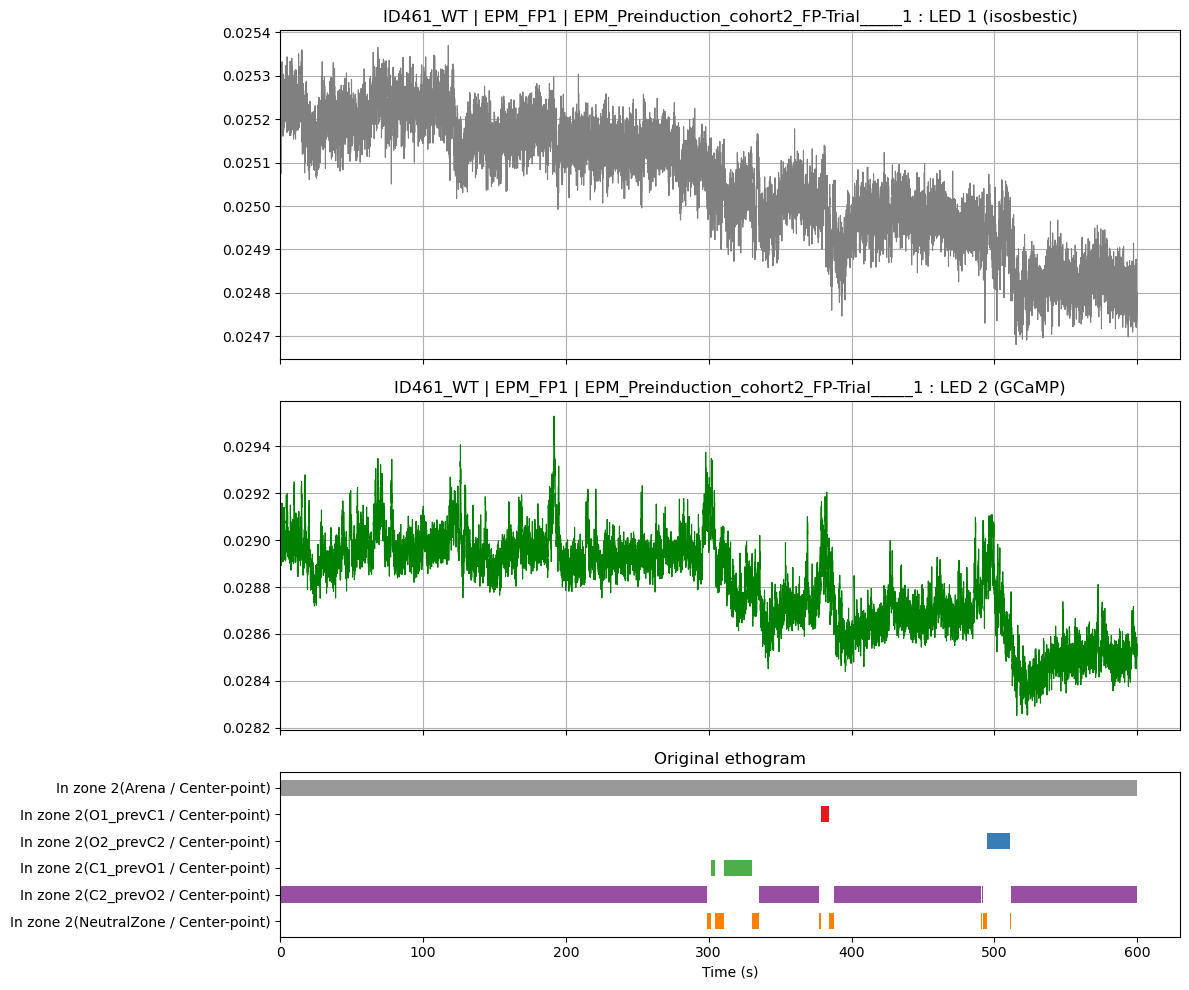

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

plt.tight_layout()
plt.show()


In [7]:
timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone 2(Arena / Center-point),0.000,600.011,600.011
25,In zone 2(C2_prevO2 / Center-point),0.000,4.521,4.521
40,In zone 2(NeutralZone / Center-point),4.521,4.541,0.020
26,In zone 2(C2_prevO2 / Center-point),4.541,4.621,0.080
41,In zone 2(NeutralZone / Center-point),4.621,4.661,0.040
...,...,...,...,...
38,In zone 2(C2_prevO2 / Center-point),493.381,493.401,0.020
70,In zone 2(NeutralZone / Center-point),493.401,494.701,1.300
13,In zone 2(O2_prevC2 / Center-point),494.701,511.206,16.505
71,In zone 2(NeutralZone / Center-point),511.206,511.466,0.260


Issues: 
- fix residual time introduced in arranged (add to last timestamp? next iteration start from previous?)

In [8]:
def smoothing_kernel(data, grainularity = 0.1, kernel_size = 5):
    """
    Smooths timeline data using a kernel.

    Args:
        data (pd.DataFrame): Timeline data.
        grainularity (float): The grainularity that the timeline data should be split up with (seconds).
        kernel_size (int): The number of 'frames' (defined by the grainularity) the kernel looks ahead 
        and behind when determining the new lable.

    Returns:
        pd.DataFrame: The timeline data reassembled with the new labels in the column 'kernel_label'.
    """
    timeline_exploded = pd.DataFrame({'timestamp' : [], 'label' : []})

    #def explode_timeline(timeline, grainularity):
    for _, row in data.iterrows():
        # timestamps = np.arange(row['Start_time_s'], row['End_time_s'], grainularity)
        timestamps = np.arange(row['Start_time_s'], row['End_time_s'] + grainularity, grainularity)

        labels = row['Behavior'] #* len(timestamps)

        timeline_exploded = pd.concat([timeline_exploded, 
                                       pd.DataFrame({'timestamp' : timestamps, 'label' : labels})])

    timeline_exploded = timeline_exploded.reset_index()

    kernel_content = []

    def most_common(lst):
        return max(set(lst), key=lst.count)

    new_labels = []

    for i, row in timeline_exploded.iterrows():
        if i < kernel_size:
            kernel_content = timeline_exploded[ : i + kernel_size]['label']

        elif i + kernel_size > len(timeline_exploded):
            kernel_content = timeline_exploded[i - (kernel_size - 1) : ]['label']

        else:
            kernel_content = timeline_exploded[i - (kernel_size - 1) : i + kernel_size]['label']
        
        new_labels.append(most_common(kernel_content.to_list()))

    timeline_exploded['kernel_label'] = new_labels

    current_label = ''

    timeline_kernel_labels = pd.DataFrame()


    # After your existing loop that builds timeline_kernel_labels
    for i, row in timeline_exploded.iterrows():
        if current_label == row['kernel_label']:
            pass
        elif current_label == '':
            current_label = row['kernel_label']
            Start_time_s = row['timestamp']
        elif current_label != row['kernel_label']:
            timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                                pd.DataFrame({
                                                    'Behavior' : [current_label],
                                                    'Start_time_s' : [Start_time_s],
                                                    'End_time_s' : row['timestamp'],
                                                    'Duration_s' : row['timestamp'] - Start_time_s
                                                })])
            Start_time_s = row['timestamp']
            current_label = row['kernel_label']

    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])
   # code for removing anything shorter than 1 s
    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])

    # --- FILTER: Remove segments shorter than 1 second ---
    timeline_kernel_labels = timeline_kernel_labels[timeline_kernel_labels['Duration_s'] >= 1.0].reset_index(drop=True)



    return timeline_kernel_labels

timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 50) #when granulairty is 0.1, it says every frame represents 0.1 second. the smaller granulairty, the less the end pieces weigh in the decision to what behaviour is being conducted




In [9]:
timeline_kernel_labels

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone 2(C2_prevO2 / Center-point),0.100,300.005,299.905
1,In zone 2(NeutralZone / Center-point),300.005,303.386,3.381
2,In zone 2(C1_prevO1 / Center-point),303.386,305.187,1.801
3,In zone 2(NeutralZone / Center-point),305.187,310.487,5.300
4,In zone 2(C1_prevO1 / Center-point),310.487,330.094,19.607
5,In zone 2(NeutralZone / Center-point),330.094,334.975,4.881
6,In zone 2(C2_prevO2 / Center-point),334.975,378.248,43.273
7,In zone 2(O1_prevC1 / Center-point),378.248,384.409,6.161
8,In zone 2(NeutralZone / Center-point),384.409,387.370,2.961
9,In zone 2(C2_prevO2 / Center-point),387.370,493.341,105.971


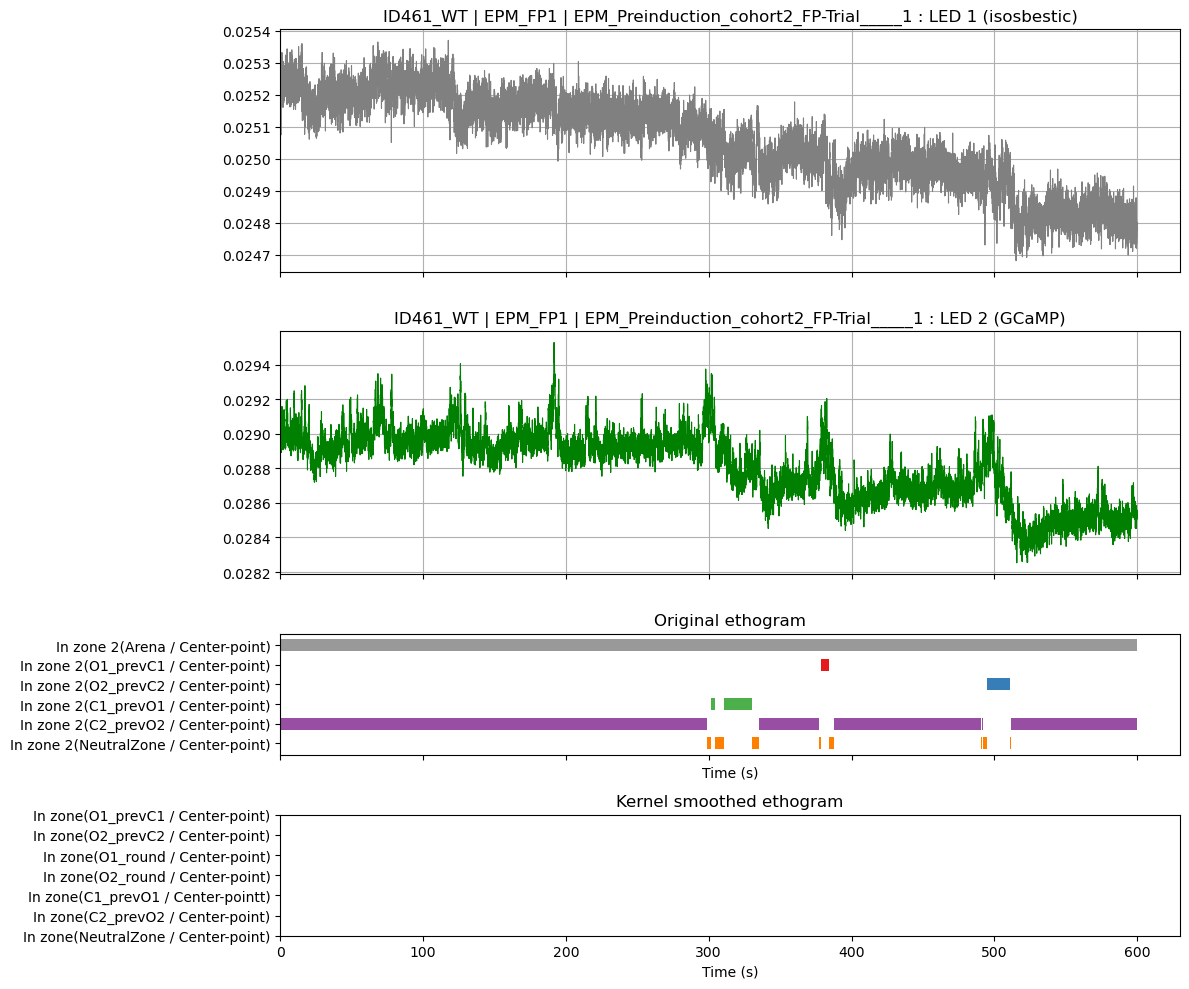

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2,1, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 20) #play around with adjusting kernel size and granularity
#beh_cols_clean = timeline_kernel_labels["Behavior"].unique()
beh_cols_clean = [ # samme rækkefølge som plottet ovenfor
'In zone(O1_prevC1 / Center-point)',
'In zone(O2_prevC2 / Center-point)',
'In zone(O1_round / Center-point)',
'In zone(O2_round / Center-point)',
'In zone(C1_prevO1 / Center-pointt)',
'In zone(C2_prevO2 / Center-point)',
'In zone(NeutralZone / Center-point)'
]
for i, beh in enumerate(beh_cols_clean):
    color = _guess_zone_color(beh)
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[3].set_yticks(range(len(beh_cols_clean)))
axes[3].set_yticklabels(beh_cols_clean)
axes[3].invert_yaxis()
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Kernel smoothed ethogram")

plt.tight_layout()
plt.show()


In [11]:
# sanity check - number of entries into different zones

# --- Count occurrences for each behavior in this kernel-smoothed ethogram ---
print("\nKernel-smoothed ethogram occurrences (as plotted):")

for beh in beh_cols_clean:
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    n_occurrences = len(subset)
    print(f"{beh}: {n_occurrences} instance(s)")

    # Optional: print detailed start/end/duration
    for idx, row in subset.iterrows():
        print(f"  Start: {row['Start_time_s']:.3f}, "
              f"End: {row['End_time_s']:.3f}, "
              f"Duration: {row['Duration_s']:.3f}")



Kernel-smoothed ethogram occurrences (as plotted):
In zone(O1_prevC1 / Center-point): 0 instance(s)
In zone(O2_prevC2 / Center-point): 0 instance(s)
In zone(O1_round / Center-point): 0 instance(s)
In zone(O2_round / Center-point): 0 instance(s)
In zone(C1_prevO1 / Center-pointt): 0 instance(s)
In zone(C2_prevO2 / Center-point): 0 instance(s)
In zone(NeutralZone / Center-point): 0 instance(s)


In [12]:
print(timeline_kernel_labels) # check around 455, there are smoe very short instances

                                 Behavior  Start_time_s  End_time_s  \
0     In zone 2(C2_prevO2 / Center-point)         0.000     298.845   
1   In zone 2(NeutralZone / Center-point)       298.845     301.705   
2     In zone 2(C1_prevO1 / Center-point)       301.806     305.147   
3   In zone 2(NeutralZone / Center-point)       305.147     310.749   
4     In zone 2(C1_prevO1 / Center-point)       310.749     330.094   
5   In zone 2(NeutralZone / Center-point)       330.094     334.975   
6     In zone 2(C2_prevO2 / Center-point)       334.975     378.148   
7     In zone 2(O1_prevC1 / Center-point)       378.348     384.089   
8   In zone 2(NeutralZone / Center-point)       384.089     387.650   
9     In zone 2(C2_prevO2 / Center-point)       387.650     492.000   
10  In zone 2(NeutralZone / Center-point)       492.000     494.701   
11    In zone 2(O2_prevC2 / Center-point)       494.701     511.406   
12    In zone 2(C2_prevO2 / Center-point)       511.406     600.066   
13    

# generate the above plot for all trials

In [13]:
#print(timeline_kernel_labels['Behavior'].unique())

print(timeline_kernel_labels['Behavior'].unique())

['In zone 2(C2_prevO2 / Center-point)'
 'In zone 2(NeutralZone / Center-point)'
 'In zone 2(C1_prevO1 / Center-point)'
 'In zone 2(O1_prevC1 / Center-point)'
 'In zone 2(O2_prevC2 / Center-point)']


In [14]:
list(fp_traces.keys())

['Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1']

In [15]:
timeline_kernel_labels

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone 2(C2_prevO2 / Center-point),0.000,298.845,298.845
1,In zone 2(NeutralZone / Center-point),298.845,301.705,2.860
2,In zone 2(C1_prevO1 / Center-point),301.806,305.147,3.341
3,In zone 2(NeutralZone / Center-point),305.147,310.749,5.602
4,In zone 2(C1_prevO1 / Center-point),310.749,330.094,19.345
5,In zone 2(NeutralZone / Center-point),330.094,334.975,4.881
6,In zone 2(C2_prevO2 / Center-point),334.975,378.148,43.173
7,In zone 2(O1_prevC1 / Center-point),378.348,384.089,5.741
8,In zone 2(NeutralZone / Center-point),384.089,387.650,3.561
9,In zone 2(C2_prevO2 / Center-point),387.650,492.000,104.350


In [16]:
timeline_kernel_labels.sort_values('Start_time_s')

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone 2(C2_prevO2 / Center-point),0.000,298.845,298.845
1,In zone 2(NeutralZone / Center-point),298.845,301.705,2.860
2,In zone 2(C1_prevO1 / Center-point),301.806,305.147,3.341
3,In zone 2(NeutralZone / Center-point),305.147,310.749,5.602
4,In zone 2(C1_prevO1 / Center-point),310.749,330.094,19.345
5,In zone 2(NeutralZone / Center-point),330.094,334.975,4.881
6,In zone 2(C2_prevO2 / Center-point),334.975,378.148,43.173
7,In zone 2(O1_prevC1 / Center-point),378.348,384.089,5.741
8,In zone 2(NeutralZone / Center-point),384.089,387.650,3.561
9,In zone 2(C2_prevO2 / Center-point),387.650,492.000,104.350


In [17]:
def nose_point_fixer(data):
    """
    1) Adds missing 'prevC' nose-point rows when 'round' nose-point rows appear.
    2) Merges consecutive observations with the same behavior if they are timewise connected.
    """

    # --- Step 1: Add missing prevC rows ---
    for i in range(len(data)):
        row = data.iloc[i]

        # O1
        if 'O1_round / Nose-point' in row.Behavior:
            behavior = [b for b in timeline_kernel_labels.Behavior.unique()
                        if 'O1_prevC1 / Nose-point' in b][0]

            new_row = {
                'Behavior': behavior,
                'Start_time_s': row.Start_time_s,
                'End_time_s': row.End_time_s,
                'Duration_s': row.Duration_s,
            }
            data.loc[len(data)] = new_row

        # O2
        if 'O2_round / Nose-point' in row.Behavior:
            behavior = [b for b in timeline_kernel_labels.Behavior.unique()
                        if 'O2_prevC2 / Nose-point' in b][0]

            new_row = {
                'Behavior': behavior,
                'Start_time_s': row.Start_time_s,
                'End_time_s': row.End_time_s,
                'Duration_s': row.Duration_s,
            }
            data.loc[len(data)] = new_row

    # Sort after adding rows
    data = data.sort_values("Start_time_s").reset_index(drop=True)

    # --- Step 2: Merge consecutive rows with same behavior ---
    merged = []
    current = data.iloc[0].copy()

    for i in range(1, len(data)):
        row = data.iloc[i]

        # If same behavior AND timewise connected (touching or overlapping)
        if (row.Behavior == current.Behavior) and (row.Start_time_s <= current.End_time_s):
            # Extend the current interval
            current.End_time_s = max(current.End_time_s, row.End_time_s)
            current.Duration_s = current.End_time_s - current.Start_time_s
        else:
            # Save finished interval
            merged.append(current)
            current = row.copy()

    # Append last interval
    merged.append(current)

    # Convert back to DataFrame
    merged_df = pd.DataFrame(merged)

    return merged_df


In [18]:
# # test on one trial


# # ==========================================================
# # Apply smoothing_kernel and plot kernel-smoothed ethograms for all trials
# # ==========================================================

# #for trial_key, trial_data in fp_traces.items():
# #trial_key = 'Preinduction__ID374_WT__EPM_FP2_1__EPM_preinduction_BigArena_his_res-Trial_____3'
# #trial_key = 'Preinduction__ID459_NE__EPM_FP_1_2__EPM_preinduction_BigArena_his_res-Trial_____8'
# #trial_key = 'W2__ID429_WT__EPM_FP4_1__EPM_W2_C1-Trial_____5'

# trial_data = fp_traces[trial_key]
# try:
#     # Extract FP traces and timeline
#     iso_df = trial_data["iso"]
#     gcamp_df = trial_data["gcamp"]
#     timeline = trial_data["timeline"]
#     mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
#     fp_id = trial_key.split("__")[1]
#     trial_stub = "__".join(trial_key.split("__")[2:])
#     # # Filter out arena zone before smoothing
#     # timeline_filter = timeline[timeline['Behavior'] != 'In zone(Arena / Nose-point)'] \
#     #                   .sort_values('Start_time_s')
#     # # Apply your original smoothing kernel
#     # timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
#     # Filter out arena zone before smoothing
#     timeline_filter = timeline[
#         ~timeline['Behavior'].str.contains('Arena / Nose-point', case=False)
#     ].sort_values('Start_time_s')
#     # Apply your original smoothing kernel
#     timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
#     # enlongate flanking segments
#     #print(timeline_kernel_labels)
#     #print("DIVIDE")
#     timeline_kernel_labels = nose_point_fixer(timeline_kernel_labels)
#     #print(timeline_kernel_labels)
    
#     # Store kernel-smoothed timeline for later access
#     trial_data["timeline_kernel"] = timeline_kernel_labels
#     # Plot
#     fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
#                              gridspec_kw={"height_ratios": [2, 2, 1, 1]})
#     # --- FP traces ---
#     iso_col = [c for c in iso_df.columns if c != "Time_video"][0]    # dynamically get numeric column
#     gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]
#     axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
#     axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
#     axes[0].grid(True)
#     axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
#     axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
#     axes[1].grid(True)
#     # --- Original ethogram ---
#     beh_cols_orig = trial_data["beh_cols"]
#     for i, beh in enumerate(beh_cols_orig):
#         color = _guess_zone_color(beh)
#         subset = timeline[timeline["Behavior"] == beh]
#         for _, row in subset.iterrows():
#             axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#     axes[2].set_yticks(range(len(beh_cols_orig)))
#     axes[2].set_yticklabels(beh_cols_orig)
#     axes[2].invert_yaxis()
#     axes[2].set_xlabel("Time (s)")
#     axes[2].set_title("Original ethogram")
#     # --- Kernel-smoothed ethogram ---
#     beh_cols_clean = [b for b in beh_cols_orig if 'Arena / Nose-point' not in b]  # same order as original, arena removed
#     for i, beh in enumerate(beh_cols_clean):
#         color = _guess_zone_color(beh)
#         subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
#         for _, row in subset.iterrows():
#             axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#     axes[3].set_yticks(range(len(beh_cols_clean)))
#     axes[3].set_yticklabels(beh_cols_clean)
#     axes[3].invert_yaxis()
#     axes[3].set_xlabel("Time (s)")
#     axes[3].set_title("Kernel smoothed ethogram")
#     plt.tight_layout()
#     plt.show()
# except Exception as e:
#     print(f"[WARN] Could not plot trial {trial_key}: {e}")

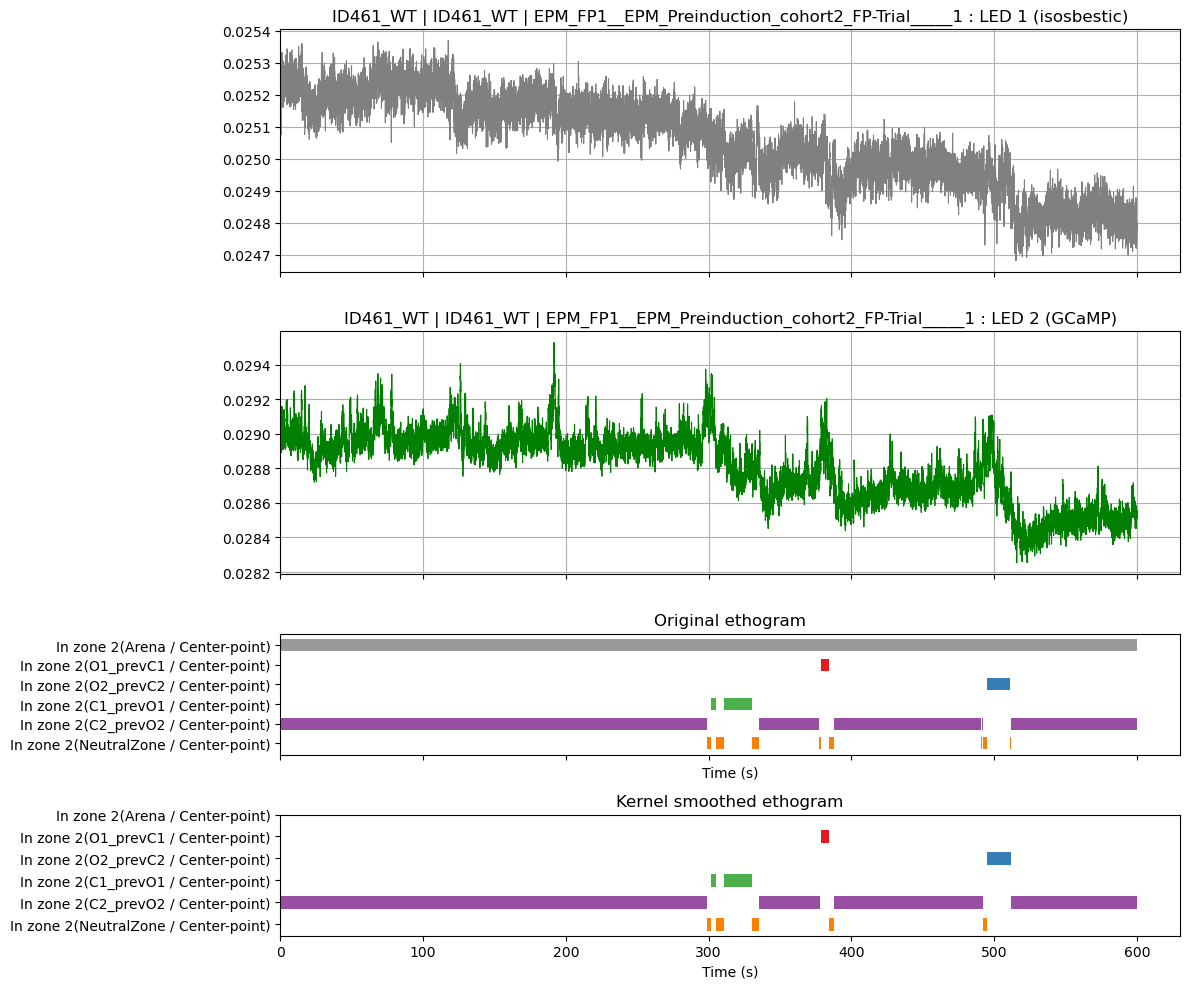

In [19]:
# ==========================================================
# Apply smoothing_kernel and plot kernel-smoothed ethograms for all trials
# ==========================================================

for trial_key, trial_data in fp_traces.items():
    try:
        # Extract FP traces and timeline
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]
        timeline = trial_data["timeline"]
        mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
        fp_id = trial_key.split("__")[1]
        trial_stub = "__".join(trial_key.split("__")[2:])

        # # Filter out arena zone before smoothing
        # timeline_filter = timeline[timeline['Behavior'] != 'In zone(Arena / Nose-point)'] \
        #                   .sort_values('Start_time_s')

        # # Apply your original smoothing kernel
        # timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        # Filter out arena zone before smoothing
        timeline_filter = timeline[
            ~timeline['Behavior'].str.contains('Arena / Nose-point', case=False)
        ].sort_values('Start_time_s')

        # Apply your original smoothing kernel
        timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        timeline_kernel_labels = nose_point_fixer(timeline_kernel_labels)
        
        # Store kernel-smoothed timeline for later access
        trial_data["timeline_kernel"] = timeline_kernel_labels


        # Plot
        fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1, 1]})

        # --- FP traces ---
        iso_col = [c for c in iso_df.columns if c != "Time_video"][0]    # dynamically get numeric column
        gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]

        axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
        axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
        axes[0].grid(True)

        axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
        axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
        axes[1].grid(True)

        # --- Original ethogram ---
        beh_cols_orig = trial_data["beh_cols"]
        for i, beh in enumerate(beh_cols_orig):
            color = _guess_zone_color(beh)
            subset = timeline[timeline["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[2].set_yticks(range(len(beh_cols_orig)))
        axes[2].set_yticklabels(beh_cols_orig)
        axes[2].invert_yaxis()
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Original ethogram")

        # --- Kernel-smoothed ethogram ---
        beh_cols_clean = [b for b in beh_cols_orig if 'Arena / Nose-point' not in b]  # same order as original, arena removed
        for i, beh in enumerate(beh_cols_clean):
            color = _guess_zone_color(beh)
            subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[3].set_yticks(range(len(beh_cols_clean)))
        axes[3].set_yticklabels(beh_cols_clean)
        axes[3].invert_yaxis()
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Kernel smoothed ethogram")



        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] Could not plot trial {trial_key}: {e}")


In [20]:
for trial_key, trial_data in fp_traces.items():
    print(f"\nTrial: {trial_key}")
    if "timeline_kernel" not in trial_data:
        print("  No kernel-smoothed ethogram found.")
        continue

    tk = trial_data["timeline_kernel"]

    # Count number of separate occurrences for each behavior
    counts = tk["Behavior"].value_counts()
    for beh, n in counts.items():
        print(f"  {beh}: {n} instance(s)")



Trial: Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1
  In zone 2(NeutralZone / Center-point): 5 instance(s)
  In zone 2(C2_prevO2 / Center-point): 4 instance(s)
  In zone 2(C1_prevO1 / Center-point): 2 instance(s)
  In zone 2(O1_prevC1 / Center-point): 1 instance(s)
  In zone 2(O2_prevC2 / Center-point): 1 instance(s)


In [21]:
# Get the last trial key
last_key = list(fp_traces.keys())[-1]
trial_data = fp_traces[last_key]

print(f"Full kernel-smoothed timeline for trial: {last_key}\n")

if "timeline_kernel" in trial_data:
    tk = trial_data["timeline_kernel"]
    # Print all columns
    print(tk.to_string(index=False))
else:
    print("No kernel-smoothed ethogram found for this trial.")


Full kernel-smoothed timeline for trial: Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1

                             Behavior  Start_time_s  End_time_s  Duration_s
  In zone 2(C2_prevO2 / Center-point)         0.000     298.845     298.845
In zone 2(NeutralZone / Center-point)       298.845     301.705       2.860
  In zone 2(C1_prevO1 / Center-point)       301.806     305.147       3.341
In zone 2(NeutralZone / Center-point)       305.147     310.749       5.602
  In zone 2(C1_prevO1 / Center-point)       310.749     330.094      19.345
In zone 2(NeutralZone / Center-point)       330.094     334.975       4.881
  In zone 2(C2_prevO2 / Center-point)       334.975     378.148      43.173
  In zone 2(O1_prevC1 / Center-point)       378.348     384.089       5.741
In zone 2(NeutralZone / Center-point)       384.089     387.650       3.561
  In zone 2(C2_prevO2 / Center-point)       387.650     492.000     104.350
In zone 2(NeutralZone / Center-point)       492.0

In [22]:
# Get the last trial key
last_key = list(fp_traces.keys())[-1]
trial_data = fp_traces[last_key]

print(f"Kernel-smoothed timeline for trial: {last_key} — O1 only\n")

if "timeline_kernel" in trial_data:
    tk = trial_data["timeline_kernel"]
    # Filter for O1 behavior
    tk_o1 = tk[tk["Behavior"] == "In zone(O2_prevC2 / Nose-point)"].sort_values("Start_time_s")
    if tk_o1.empty:
        print("No O1 entries found in this trial.")
    else:
        print(tk_o1.to_string(index=False))
else:
    print("No kernel-smoothed ethogram found for this trial.")


Kernel-smoothed timeline for trial: Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1 — O1 only

No O1 entries found in this trial.


# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [23]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


In [25]:
# Show the first key
first_key = list(coregistered_traces.keys())[0]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


First trial key: Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1
   Time_video    iso415  gcamp470
0        0.00  0.025181  0.029073
1        0.04  0.025314  0.029003
2        0.08  0.025165  0.029127
3        0.12  0.025175  0.029096
4        0.16  0.025189  0.029093


# Preprocessing

## Lowpass filtering to reduce noise.
https://github.com/ThomasAkam/photometry_preprocessing/blob/master/.ipynb_checkpoints/Photometry%20data%20preprocessing-checkpoint.ipynb



In [26]:
import os
import numpy as  np
import pylab as plt
from scipy.signal import medfilt, butter, filtfilt
from scipy.stats import linregress
from scipy.optimize import curve_fit, minimize

#set default plot properties
plt.rcParams['figure.figsize'] = [14, 12] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams['axes.labelsize'] = 12     #Set default axes label size 
plt.rcParams['axes.titlesize']=15
plt.rcParams['axes.titleweight']='heavy'
plt.rcParams['ytick.labelsize']= 10
plt.rcParams['xtick.labelsize']= 10
plt.rcParams['legend.fontsize']=12
plt.rcParams['legend.markerscale']=2

# Denoising

We lowpass filter the signals to reduce high frequency noise, using a zero phase filter with a 10Hz cutoff frequency.

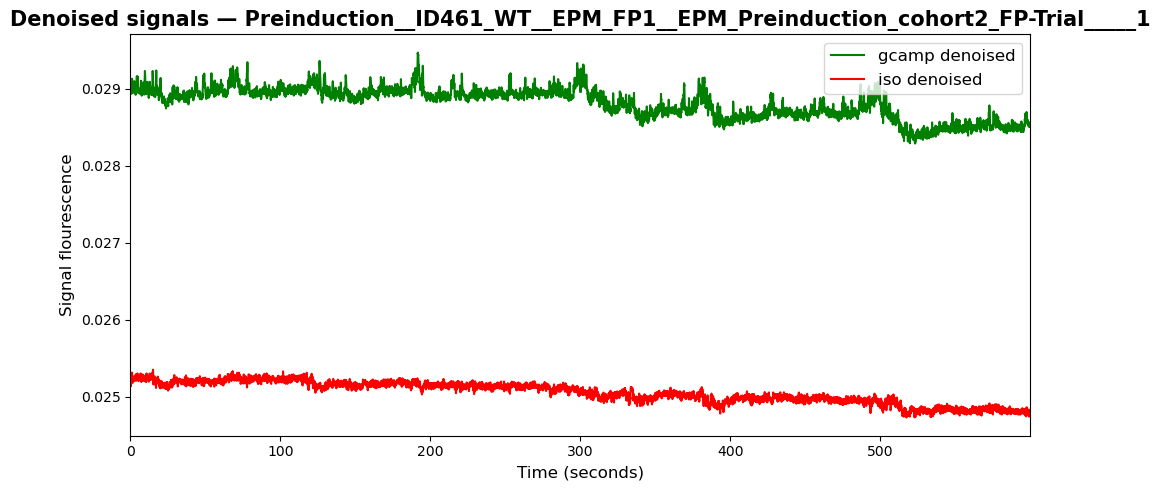

Index(['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised'], dtype='object')


In [27]:

from scipy.signal import butter, filtfilt

sampling_rate = 50

# EXACT same filter design
b, a = butter(2, 10, btype='low', fs=sampling_rate)


for key, df in coregistered_traces.items():
    
    # Apply filtering EXACTLY like notebook
    df["gcamp_denoised"] = filtfilt(b, a, df["gcamp470"].values)
    df["iso_denoised"]   = filtfilt(b, a, df["iso415"].values)


trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

fig, ax = plt.subplots(figsize=(10,5))

# Plot both signals on same axis
plot1 = ax.plot(df["Time_video"], df["gcamp_denoised"], 'g', label='gcamp denoised')
plot2 = ax.plot(df["Time_video"], df["iso_denoised"], 'r', label='iso denoised')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Signal flourescence')
ax.set_title(f'Denoised signals — {trial_key}')

# Same legend logic
lines = plot1 + plot2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

#check denoising added to original dataframe:
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

# Zoomed in plot to see denoising more clearly

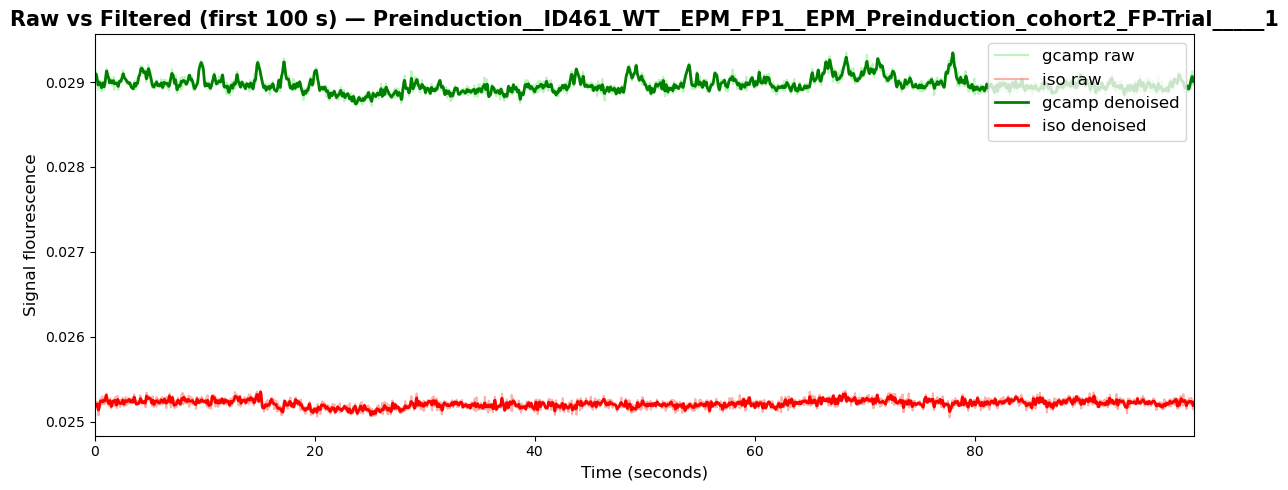

In [28]:
# Select trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

# --- Zoom window ---
df_zoom = df[df["Time_video"] <= 100]

fig, ax = plt.subplots(figsize=(12,5))

# RAW signals (faint)
ax.plot(df_zoom["Time_video"], df_zoom["gcamp470"], color='lightgreen', alpha=0.6, label='gcamp raw')
ax.plot(df_zoom["Time_video"], df_zoom["iso415"],   color='salmon',     alpha=0.6, label='iso raw')

# FILTERED signals (bold)
ax.plot(df_zoom["Time_video"], df_zoom["gcamp_denoised"], 'g', linewidth=2, label='gcamp denoised')
ax.plot(df_zoom["Time_video"], df_zoom["iso_denoised"],   'r', linewidth=2, label='iso denoised')

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Signal flourescence")
ax.set_title(f"Raw vs Filtered (first 100 s) — {trial_key}")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Photbleaching correction via double exponential fit (like neurophotometrics guide)
One way of removing the influence of bleaching is to fit an exponential decay to the data and subtract this exponential fit from the signal (note, some groups divide the signal by the baseline rather than subtracting the baseline, see Fiber Photometry Primer for more discussion). In practice we find that a double exponential fit is preferable to a single exponential fit because there are typically multiple sources of fluorescence that contribute to the bleaching (e.g. autofluorescence from fiber, autofluorescence from brain tissue, and flurophore fluorescence), which may bleach at different rates, so a single exponential fit can be overly restrictive.


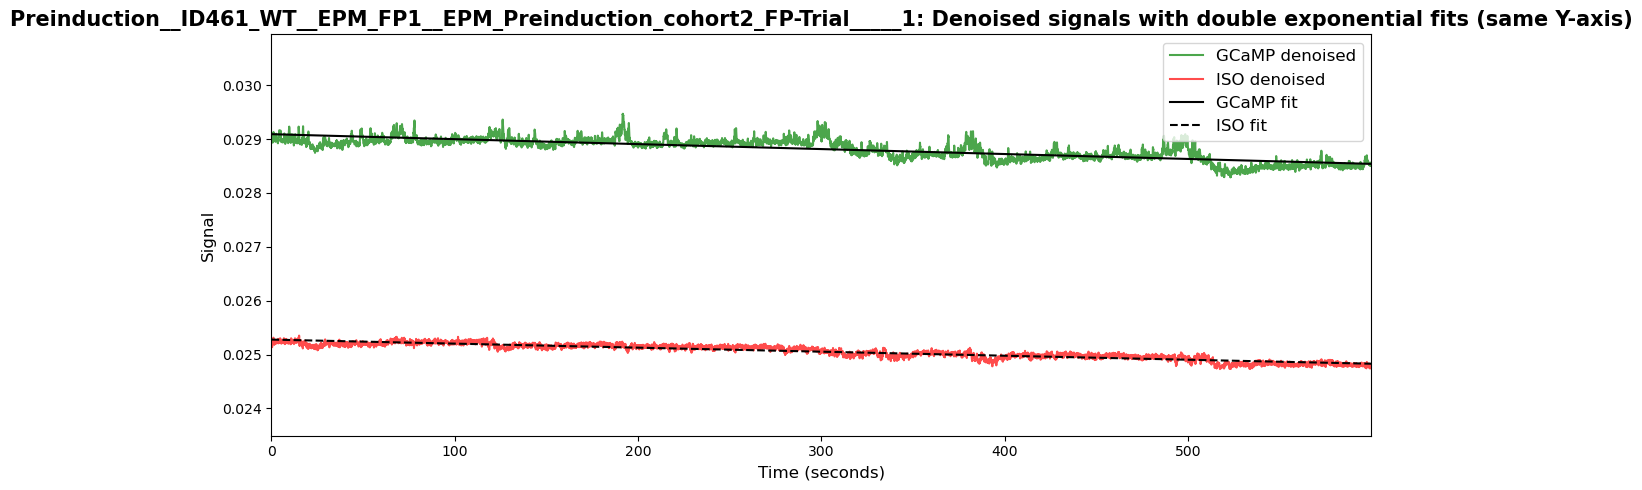

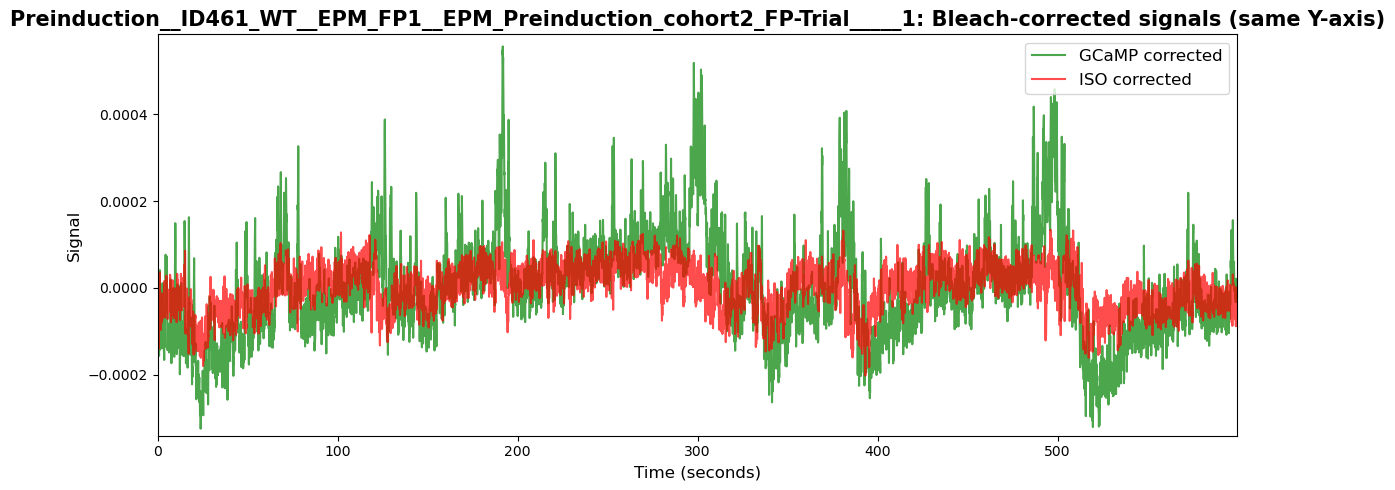

Index(['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised',
       'gcamp_expfit', 'gcamp_bleach_corrected', 'iso_expfit',
       'iso_bleach_corrected'],
      dtype='object')


In [29]:


from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Double exponential function
# ----------------------------------------------------------
def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    """
    Compute a double exponential function with constant offset.
    Parameters
    ----------
    t           : array_like, time vector in seconds
    const       : amplitude of constant offset
    amp_fast    : amplitude of fast component
    amp_slow    : amplitude of slow component
    tau_slow    : time constant of slow component (s)
    tau_multiplier : time constant of fast component relative to slow
    """
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

# Store fits and corrected signals
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # -------------------------
    # Fit GCaMP
    # -------------------------
    max_sig = np.max(df["gcamp_denoised"])
    initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
    bounds = ([0, 0, 0, 600, 0], [max_sig, max_sig, max_sig, 36000, 1])

    try:
        gcamp_params, _ = curve_fit(double_exponential, time_seconds, df["gcamp_denoised"],
                                    p0=initial_params, bounds=bounds, maxfev=1000)
        df["gcamp_expfit"] = double_exponential(time_seconds, *gcamp_params)
        df["gcamp_bleach_corrected"] = df["gcamp_denoised"] - df["gcamp_expfit"]
    except Exception as e:
        print(f"[WARN] Could not fit GCaMP for {trial_key}: {e}")
        df["gcamp_expfit"] = np.zeros_like(time_seconds)
        df["gcamp_bleach_corrected"] = df["gcamp_denoised"].copy()

    # -------------------------
    # Fit ISO
    # -------------------------
    max_sig = np.max(df["iso_denoised"])
    initial_params = [max_sig/2, max_sig/4, max_sig/4, 3600, 0.1]
    bounds = ([0, 0, 0, 600, 0], [max_sig, max_sig, max_sig, 36000, 1])

    try:
        iso_params, _ = curve_fit(double_exponential, time_seconds, df["iso_denoised"],
                                  p0=initial_params, bounds=bounds, maxfev=1000)
        df["iso_expfit"] = double_exponential(time_seconds, *iso_params)
        df["iso_bleach_corrected"] = df["iso_denoised"] - df["iso_expfit"]
    except Exception as e:
        print(f"[WARN] Could not fit ISO for {trial_key}: {e}")
        df["iso_expfit"] = np.zeros_like(time_seconds)
        df["iso_bleach_corrected"] = df["iso_denoised"].copy()

    # -------------------------
    # Plot: Denoised signals with exponential fits
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    plot1 = ax1.plot(time_seconds, df["gcamp_denoised"], 'g', alpha=0.7, label='GCaMP denoised')
    plot3 = ax1.plot(time_seconds, df["gcamp_expfit"], 'k', linewidth=1.5, label='GCaMP fit')
    plot2 = ax1.plot(time_seconds, df["iso_denoised"], 'r', alpha=0.7, label='ISO denoised')
    plot4 = ax1.plot(time_seconds, df["iso_expfit"], 'k', linestyle='--', linewidth=1.5, label='ISO fit')

    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Signal')
    ax1.set_title(f'{trial_key}: Denoised signals with double exponential fits (same Y-axis)')

    lines = plot1 + plot2 + plot3 + plot4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    ymin = min(df["gcamp_denoised"].min(), df["iso_denoised"].min()) * 0.95
    ymax = max(df["gcamp_denoised"].max(), df["iso_denoised"].max()) * 1.05
    ax1.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Plot: Bleach-corrected signals
    # -------------------------
    fig, ax2 = plt.subplots(figsize=(12,5))
    plot1_corr = ax2.plot(time_seconds, df["gcamp_bleach_corrected"], 'g', alpha=0.7, label='GCaMP corrected')
    plot2_corr = ax2.plot(time_seconds, df["iso_bleach_corrected"], 'r', alpha=0.7, label='ISO corrected')

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Signal')
    ax2.set_title(f'{trial_key}: Bleach-corrected signals (same Y-axis)')

    # Y-axis limits based on corrected signals
    ymin_corr = min(df["gcamp_bleach_corrected"].min(), df["iso_bleach_corrected"].min()) * 1.05
    ymax_corr = max(df["gcamp_bleach_corrected"].max(), df["iso_bleach_corrected"].max()) * 1.05
    ax2.set_ylim(ymin_corr, ymax_corr)

    lines_corr = plot1_corr + plot2_corr
    labels_corr = [l.get_label() for l in lines_corr]
    ax2.legend(lines_corr, labels_corr, loc='upper right')

    plt.tight_layout()
    plt.show()

#check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

Processing Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1


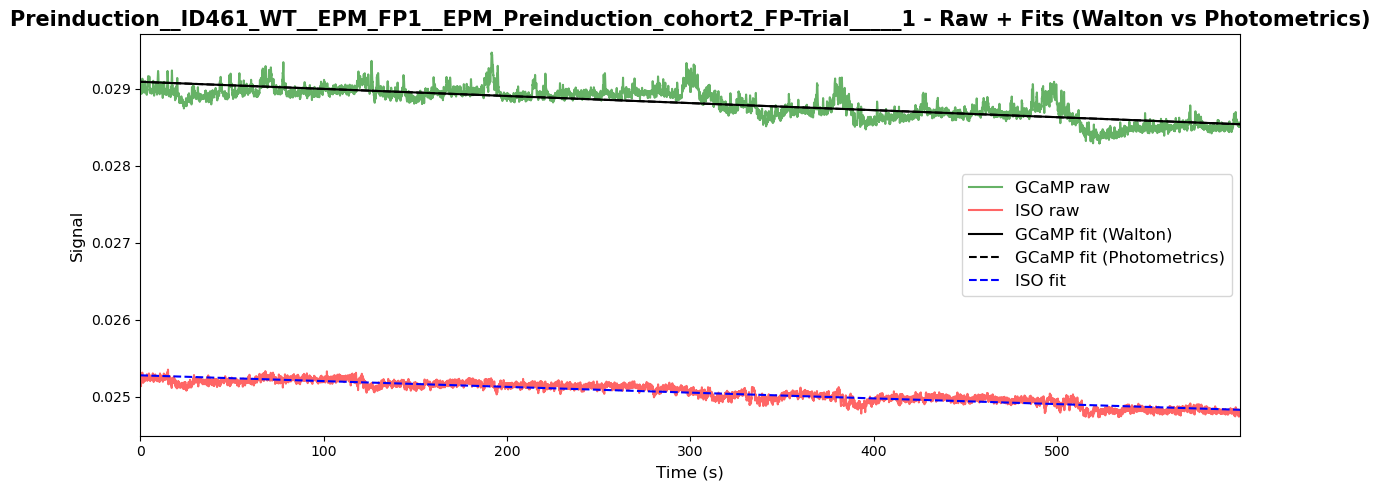

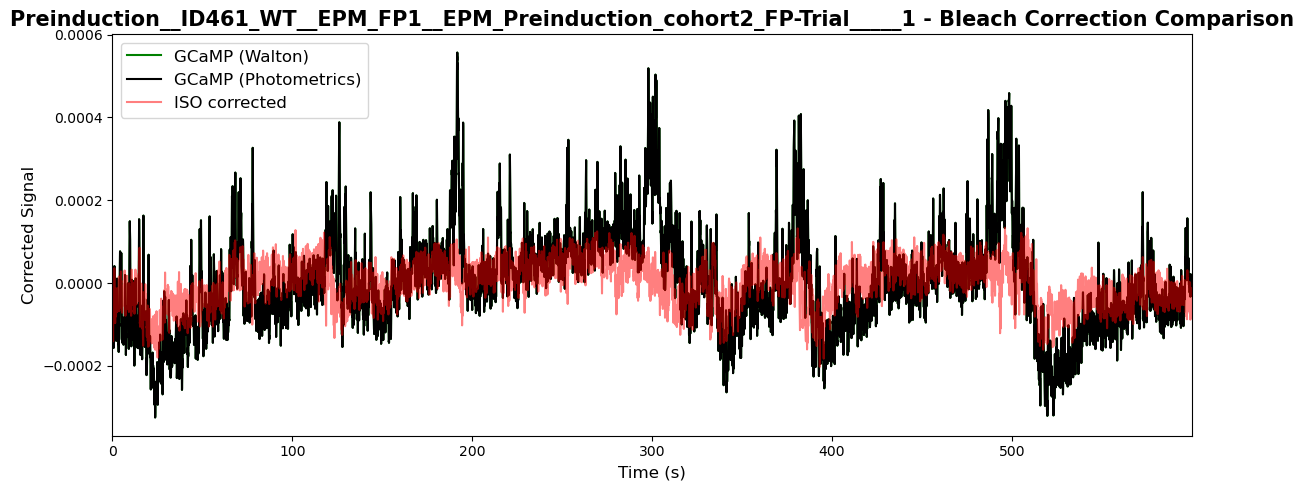

In [30]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Double exponential
# ----------------------------------------------------------
def double_exponential(t, const, amp_fast, amp_slow, tau_slow, tau_multiplier):
    tau_fast = tau_slow * tau_multiplier
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

# ==========================================================
# Loop through trials
# ==========================================================
for trial_key, df in coregistered_traces.items():

    print(f"Processing {trial_key}")
    time_seconds = df["Time_video"].values

    # ======================================================
    # WALTON METHOD (old)
    # ======================================================
    # --- GCaMP fit ---
    max_g = np.max(df["gcamp_denoised"])
    p0 = [max_g/2, max_g/4, max_g/4, 3600, 0.1]
    bounds = ([0,0,0,600,0],[max_g,max_g,max_g,36000,1])

    gcamp_params, _ = curve_fit(double_exponential, time_seconds, df["gcamp_denoised"],
                                p0=p0, bounds=bounds, maxfev=5000)
    df["gcamp_expfit_walton"] = double_exponential(time_seconds, *gcamp_params)

    # --- ISO fit ---
    max_iso = np.max(df["iso_denoised"])
    p0_iso = [max_iso/2, max_iso/4, max_iso/4, 3600, 0.1]

    iso_params, _ = curve_fit(double_exponential, time_seconds, df["iso_denoised"],
                              p0=p0_iso, bounds=bounds, maxfev=5000)
    df["iso_expfit_walton"] = double_exponential(time_seconds, *iso_params)

    # --- Walton correction ---
    df["gcamp_corrected_walton"] = df["gcamp_denoised"] - df["gcamp_expfit_walton"]
    df["iso_corrected_walton"]   = df["iso_denoised"] - df["iso_expfit_walton"]

    # ======================================================
    # PHOTOMETRICS METHOD (new)
    # ======================================================
    # Reuse ISO fit
    df["iso_expfit_photometrics"] = df["iso_expfit_walton"]

    X = df["iso_expfit_photometrics"].values
    y = df["gcamp_denoised"].values

    m, b = np.polyfit(X, y, 1)
    df["gcamp_expfit_photometrics"] = m * X + b

    # --- Photometrics correction ---
    df["gcamp_corrected_photometrics"] = df["gcamp_denoised"] - df["gcamp_expfit_photometrics"]
    df["iso_corrected_photometrics"]   = df["iso_denoised"] - df["iso_expfit_photometrics"]

    # ======================================================
    # PLOTTING
    # ======================================================
    plot_trials = True

    if plot_trials:

        # -------- Plot 1: RAW + FITS --------
        fig, ax = plt.subplots(figsize=(12,5))

        ax.plot(time_seconds, df["gcamp_denoised"], 'g', alpha=0.6, label='GCaMP raw')
        ax.plot(time_seconds, df["iso_denoised"], 'r', alpha=0.6, label='ISO raw')

        ax.plot(time_seconds, df["gcamp_expfit_walton"], 'k', label='GCaMP fit (Walton)')
        ax.plot(time_seconds, df["gcamp_expfit_photometrics"], 'k--', label='GCaMP fit (Photometrics)')

        ax.plot(time_seconds, df["iso_expfit_walton"], 'b--', label='ISO fit')

        ax.set_title(f"{trial_key} - Raw + Fits (Walton vs Photometrics)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend()
        plt.tight_layout()
        plt.show()

        # -------- Plot 2: BLEACH CORRECTION --------
        fig, ax = plt.subplots(figsize=(12,5))

        ax.plot(time_seconds, df["gcamp_corrected_walton"], 'g', label='GCaMP (Walton)')
        ax.plot(time_seconds, df["gcamp_corrected_photometrics"], 'k', label='GCaMP (Photometrics)')

        ax.plot(time_seconds, df["iso_corrected_walton"], 'r', alpha=0.5, label='ISO corrected')

        ax.set_title(f"{trial_key} - Bleach Correction Comparison")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Corrected Signal")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Motion correction

We now do motion correction by finding the best linear fit of the TdTomato signal to the dLight signal and subtracting this estimated motion component from the dLight signal. We will use the data that was bleaching corrected using the double exponential fit as this is less likely to remove meaningful slow variation in the signals.
first single trial

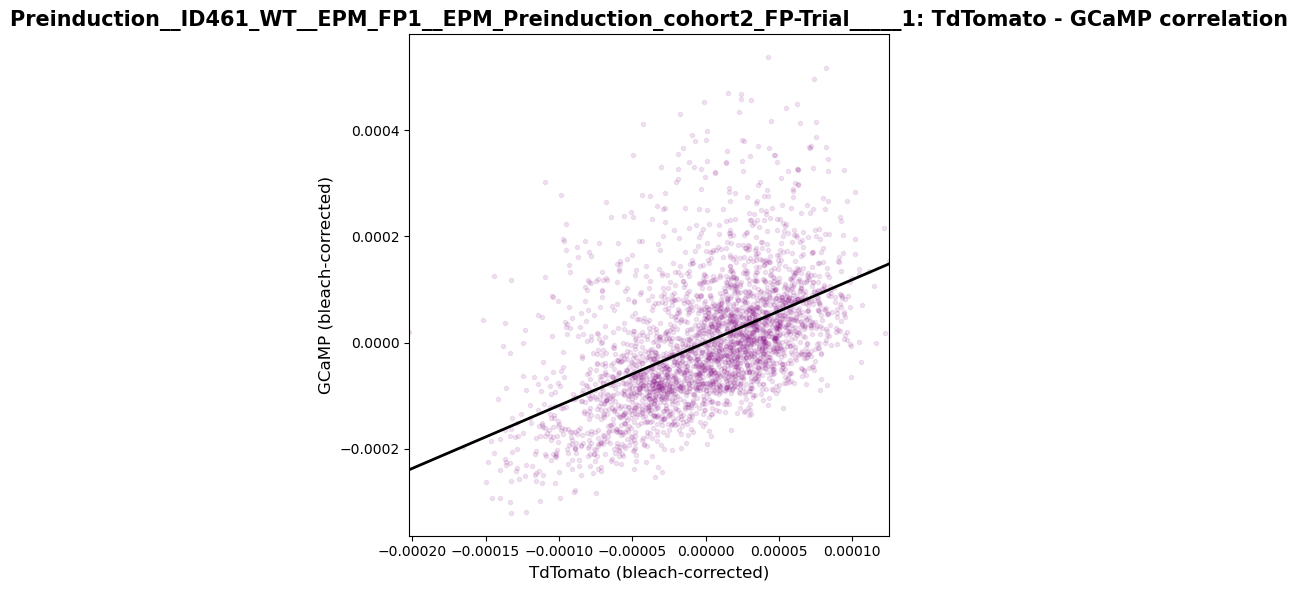

Slope    : 1.186
Intercept: -0.000
R-squared: 0.256
p-value  : 0.000e+00
Std err  : 0.017


In [31]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Pick first trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

# Use bleach-corrected signals
x = df["iso_bleach_corrected"].values       # TdTom / ISO
y = df["gcamp_bleach_corrected"].values    # GCaMP

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Scatter plot (downsample every 5 points for clarity)
plt.figure(figsize=(6,6))
plt.scatter(x[::5], y[::5], alpha=0.1, marker='.', color='purple')

# Regression line
line_x = np.array(plt.xlim())
line_y = intercept + slope*line_x
plt.plot(line_x, line_y, color='black', linewidth=2)

plt.xlabel('TdTomato (bleach-corrected)')
plt.ylabel('GCaMP (bleach-corrected)')
plt.title(f'{trial_key}: TdTomato - GCaMP correlation')
plt.tight_layout()
plt.show()

# Print regression stats
print(f"Slope    : {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value  : {p_value:.3e}")
print(f"Std err  : {std_err:.3f}")

We can see that as expected the signals have a positive correlation due to the common contribution of movement to each. We can also see from the slope of the fit being 1.37 that the movement artifacts in the gcamp channel are a bit bigger (I think , not too ure what this means) than in the iso channel. From paper: This is likely because the shorter wavelength excitation light used for dLight excites much more autofluorescence from patch cords and bulk brain tissue, and as a large area diffuse source, autofluorescence is generally less affected by movement. For the same reason movement artifacts in isosbestic control channels, which use short wavelength excitation, are typically smaller than in the dLight channel. so I think it makes sense the movement artifacts in my gcamp channel is estimated to be bigger than in my iso channel makes sense?

We now calculate the estimated motion component of the dLight signal and subtract to get the motion corrected signal.

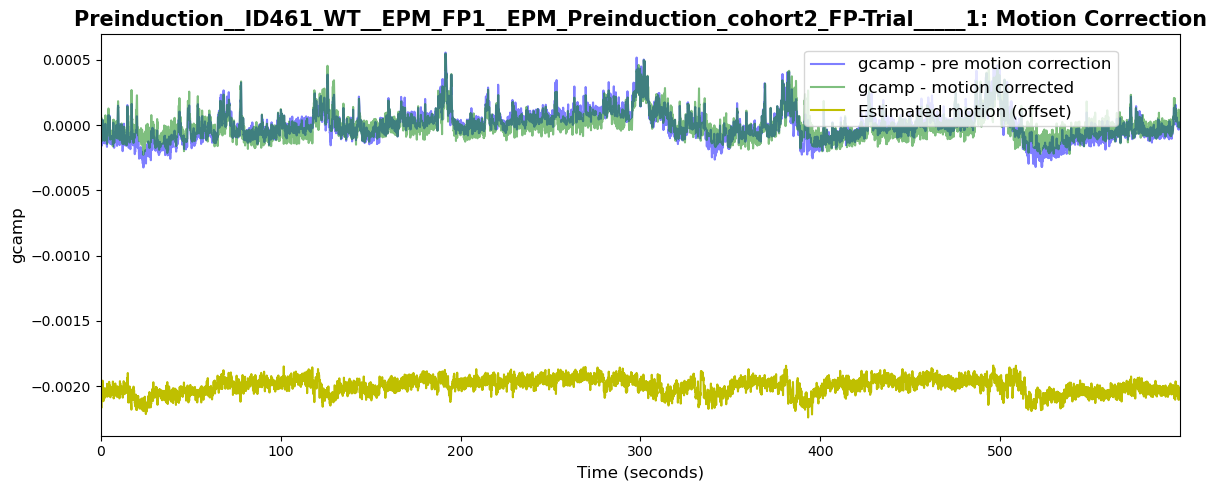

Slope    : 1.186
Intercept: -0.000
R-squared: 0.256
p-value  : 0.000e+00
Std err  : 0.017


In [32]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# Pick first trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

time_seconds = df["Time_video"].values

# Signals to use
iso_detrended = df["iso_bleach_corrected"].values      # ISO / TdTom
gcamp_detrended = df["gcamp_bleach_corrected"].values   # GCaMP / dLight

# ---------------------------------------------------------
# Linear regression: motion correction - i think this is the same linear regression method as oreviously used, but check (but just done after photobleaching correction and denoising)
# ---------------------------------------------------------
slope, intercept, r_value, p_value, std_err = linregress(iso_detrended, gcamp_detrended)

# Estimate motion contribution
gcamp_est_motion = intercept + slope * iso_detrended
gcamp__motion_corrected = gcamp_detrended - gcamp_est_motion

# ---------------------------------------------------------
# Plot motion correction
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,5))

# Pre-motion corrected
plot1 = ax1.plot(time_seconds, gcamp_detrended, 'b', alpha=0.5, label='gcamp - pre motion correction')

# Motion-corrected
plot3 = ax1.plot(time_seconds, gcamp__motion_corrected, 'g', alpha=0.5, label='gcamp - motion corrected')

# Estimated motion
plot4 = ax1.plot(time_seconds, gcamp_est_motion - 0.002, 'y', label='Estimated motion (offset)')

# Example reward cues (optional)
# reward_cue_times = np.array([...])  # define if you have reward timestamps
# reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 0.08),
#                        label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('gcamp')
ax1.set_title(f'{trial_key}: Motion Correction')

# Combine legend
lines = plot1 + plot3 + plot4  # + reward_ticks if used
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))


plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print regression stats
# ---------------------------------------------------------
print(f"Slope    : {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value  : {p_value:.3e}")
print(f"Std err  : {std_err:.3f}")






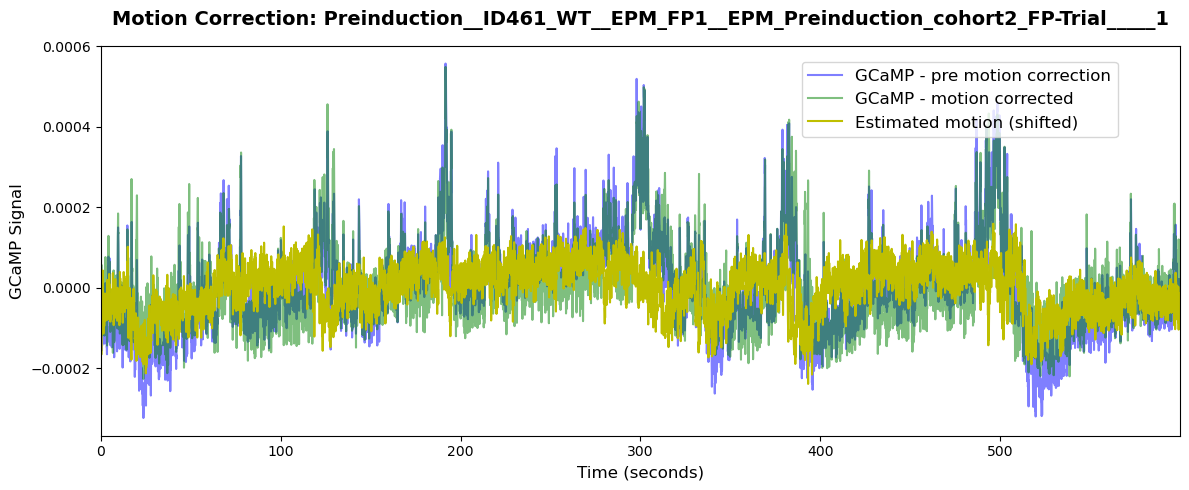


Trial: Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1
 Slope    : 1.186
 Intercept: -0.000
 R-squared: 0.256
 p-value  : 0.000e+00
 Std err  : 0.017
Index(['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised',
       'gcamp_expfit', 'gcamp_bleach_corrected', 'iso_expfit',
       'iso_bleach_corrected', 'gcamp_expfit_walton', 'iso_expfit_walton',
       'gcamp_corrected_walton', 'iso_corrected_walton',
       'iso_expfit_photometrics', 'gcamp_expfit_photometrics',
       'gcamp_corrected_photometrics', 'iso_corrected_photometrics',
       'gcamp_motion_corrected', 'gcamp_est_motion'],
      dtype='object')


In [33]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store motion-corrected traces
motion_corrected_traces = {}

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    
    time_seconds = df["Time_video"].values
    
    # Bleach-corrected signals
    iso_detrended = df["iso_bleach_corrected"].values      # TdTom / ISO
    gcamp_detrended = df["gcamp_bleach_corrected"].values  # GCaMP / dLight

    # ---------------------------------------------------------
    # Linear regression: motion correction
    # ---------------------------------------------------------
    slope, intercept, r_value, p_value, std_err = linregress(iso_detrended, gcamp_detrended)

    # Estimate motion contribution
    gcamp_est_motion = intercept + slope * iso_detrended
    gcamp_motion_corrected = gcamp_detrended - gcamp_est_motion

    # Store results
    motion_corrected_traces[trial_key] = {
        "gcamp_motion_corrected": gcamp_motion_corrected,
        "gcamp_est_motion": gcamp_est_motion,
        "slope": slope,
        "intercept": intercept,
        "r_value": r_value,
        "p_value": p_value,
        "std_err": std_err,
        "time_seconds": time_seconds
    }

    # ---------------------------------------------------------
    # Plot motion correction
    # ---------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    # Pre-motion corrected
    plot1 = ax1.plot(time_seconds, gcamp_detrended, 'b', alpha=0.5, label='GCaMP - pre motion correction')
    
    # Motion-corrected
    plot3 = ax1.plot(time_seconds, gcamp_motion_corrected, 'g', alpha=0.5, label='GCaMP - motion corrected')
    
    # Shift motion trace for visual alignment
    motion_offset = gcamp_detrended.mean() - gcamp_motion_corrected.mean()
    plot4 = ax1.plot(time_seconds, gcamp_est_motion + motion_offset, 'y', label='Estimated motion (shifted)')
    
    # Auto Y-axis limits based on the range of signals
    combined = np.concatenate([gcamp_detrended, gcamp_motion_corrected, gcamp_est_motion + motion_offset])
    y_min, y_max = combined.min(), combined.max()
    y_padding = (y_max - y_min) * 0.05  # 5% padding
    ax1.set_ylim(y_min - y_padding, y_max + y_padding)
    
    # Add trial key at top
    ax1.set_title(f'Motion Correction: {trial_key}', fontsize=14, pad=15)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP Signal')
    
    # Combine legend
    lines = plot1 + plot3 + plot4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    # Optional zoom per trial
    # ax1.set_xlim(1000, 1060)
    
    plt.tight_layout()
    plt.show()
    
    # Print regression stats
    print(f"\nTrial: {trial_key}")
    print(f" Slope    : {slope:.3f}")
    print(f" Intercept: {intercept:.3f}")
    print(f" R-squared: {r_value**2:.3f}")
    print(f" p-value  : {p_value:.3e}")
    print(f" Std err  : {std_err:.3f}")

    #add the variables to the data frame
    df["gcamp_motion_corrected"] = gcamp_motion_corrected
    df["gcamp_est_motion"] = gcamp_est_motion

 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

## Normalisation

Typically in a photometry experiment we want to combine data across sessions and/or subjects. This is complicated by the fact that different sessions may have different levels of fluorphore expression, excitation light and autofluorescence. It is therefore desirable to normalise the data to reduce this variability. The two most widely used ways of doing this are computing dF/F or z-scores.

Method 1: dF/F

To compute dF/F we divide the signal changes (dF) by the baseline fluorescence (F) and multiply by 100 to convert to percent. The dF is just the motion corrected signal plotted above. The baseline fluorescence F changes over the course of the session due to photobleaching, and is just the baseline we estimated with our double exponential fit.
Question: if using the old exp fit from gcamp, wouldnt that one have a much higher number, and a curve?

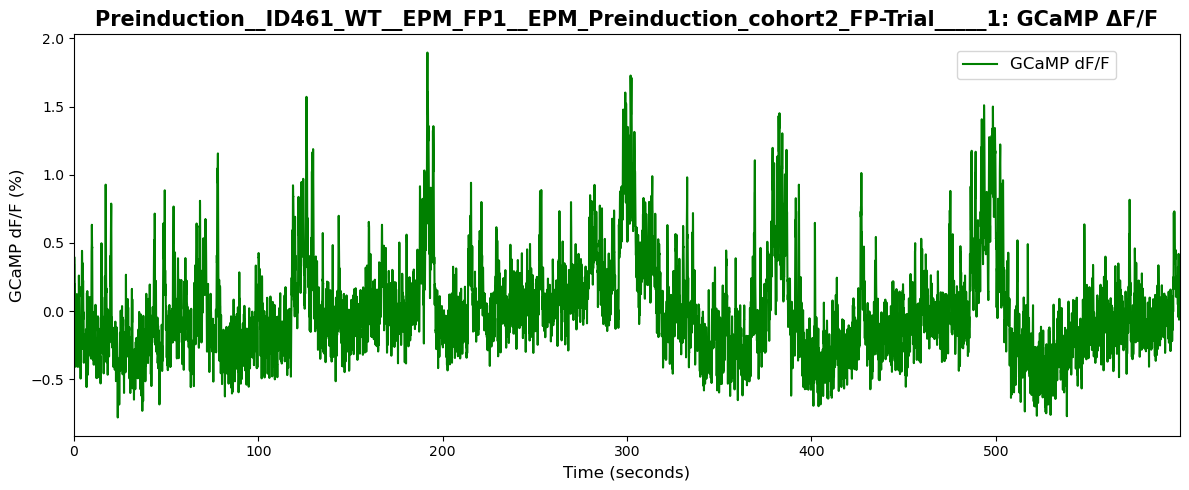

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a trial
trial_key = list(coregistered_traces.keys())[0]
df = coregistered_traces[trial_key]

time_seconds = df["Time_video"].values

# Compute ΔF/F (%) using motion-corrected signal and exponential fit - so it is not divided by the iso signal, but by the double exponential fit from earlier - however, that was fit before bleach correction, so why do we divide by this? wouldn't this have the bleaching slope with it, which our new trace does not? would it be better to divide by the bleach corrected iso signal? or even add motion correction to the iso signal and divide by the motion-corrected iso signal?
gcamp_dF_F = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit"]

# Example reward cue times (replace with your actual reward timestamps if available)
# reward_cue_times = np.array([...])
# For now, we'll just leave this commented or empty if you don't have them
reward_cue_times = np.array([])  

# Plot ΔF/F
fig, ax1 = plt.subplots(figsize=(12,5))

plot1 = ax1.plot(time_seconds, gcamp_dF_F, 'g', label='GCaMP dF/F')
if reward_cue_times.size > 0:
    reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                            label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('GCaMP dF/F (%)')
ax1.set_title(f'{trial_key}: GCaMP ΔF/F')

# Legend
lines = plot1
if reward_cue_times.size > 0:
    lines += reward_ticks
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))


plt.tight_layout()
plt.show()

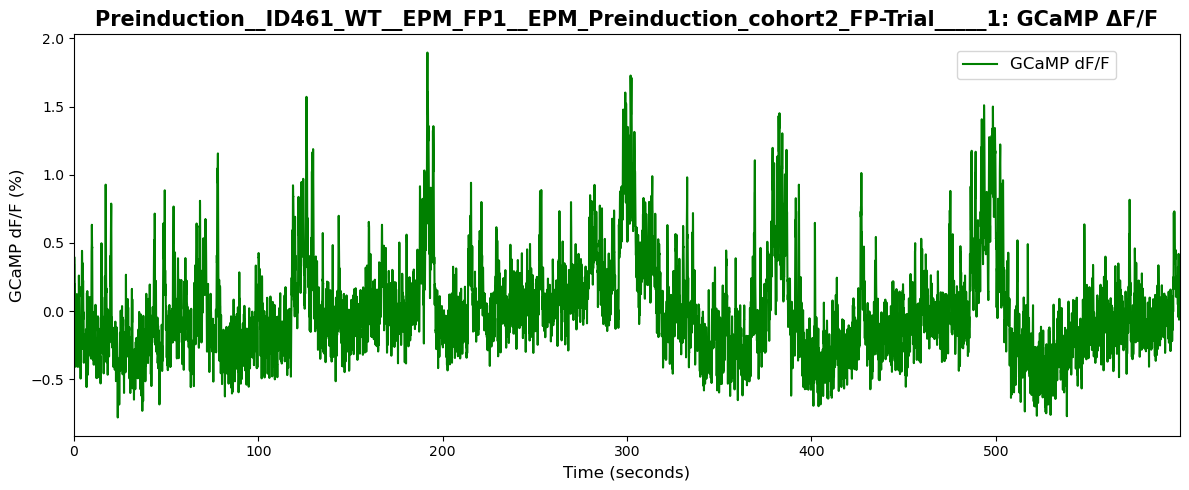

Index(['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised',
       'gcamp_expfit', 'gcamp_bleach_corrected', 'iso_expfit',
       'iso_bleach_corrected', 'gcamp_expfit_walton', 'iso_expfit_walton',
       'gcamp_corrected_walton', 'iso_corrected_walton',
       'iso_expfit_photometrics', 'gcamp_expfit_photometrics',
       'gcamp_corrected_photometrics', 'iso_corrected_photometrics',
       'gcamp_motion_corrected', 'gcamp_est_motion', 'gcamp_dF_F'],
      dtype='object')


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Example reward cue times (replace with actual timestamps if available)
reward_cue_times = np.array([])

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # Compute ΔF/F (%) for GCaMP (gcamp_bleach_corrected / gcamp_expfit)
    df["gcamp_dF_F"] = 100 * df["gcamp_motion_corrected"] / df["gcamp_expfit"]

    # Optional: compute ΔF/F for ISO channel if desired
    # df["iso_dF_F"] = 100 * df["iso_bleach_corrected"] / df["iso_expfit"]

    # -------------------------
    # Plot ΔF/F for each trial
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    plot1 = ax1.plot(time_seconds, df["gcamp_dF_F"], 'g', label='GCaMP dF/F')
    
    if reward_cue_times.size > 0:
        reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                                label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP dF/F (%)')
    ax1.set_title(f'{trial_key}: GCaMP ΔF/F')
    
    # Combine legend
    lines = plot1
    if reward_cue_times.size > 0:
        lines += reward_ticks
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    
    plt.tight_layout()
    plt.show()
    #add the variables to the data frame
    #df["gcamp_motion_corrected"] = gcamp_motion_corrected
    #df["gcamp_est_motion"] = gcamp_est_motion


 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

Method 2: Z-scoring

Alternatively, we can normalise the data by z-scoring each session - i.e. subtracting the mean and dividing by the standard deviation.

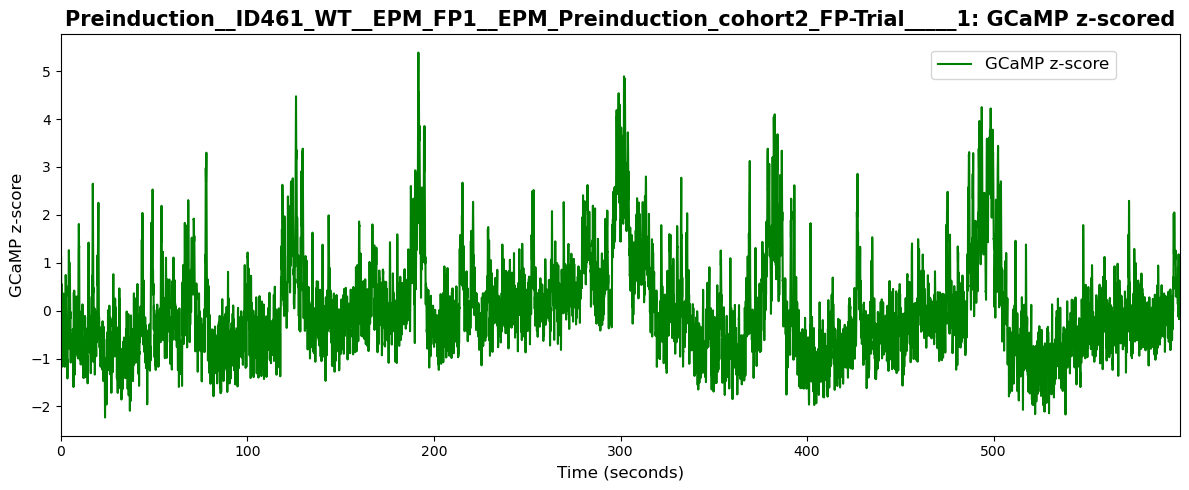

Index(['Time_video', 'iso415', 'gcamp470', 'gcamp_denoised', 'iso_denoised',
       'gcamp_expfit', 'gcamp_bleach_corrected', 'iso_expfit',
       'iso_bleach_corrected', 'gcamp_expfit_walton', 'iso_expfit_walton',
       'gcamp_corrected_walton', 'iso_corrected_walton',
       'iso_expfit_photometrics', 'gcamp_expfit_photometrics',
       'gcamp_corrected_photometrics', 'iso_corrected_photometrics',
       'gcamp_motion_corrected', 'gcamp_est_motion', 'gcamp_dF_F', 'gcamp_z'],
      dtype='object')


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Example reward cue times (replace with actual timestamps if available)
reward_cue_times = np.array([])

# Loop over all trials
for trial_key, df in coregistered_traces.items():
    time_seconds = df["Time_video"].values

    # Compute z-score for motion- and bleach-corrected GCaMP
    df["gcamp_z"] = (df["gcamp_motion_corrected"] - np.mean(df["gcamp_motion_corrected"])) / np.std(df["gcamp_motion_corrected"])

    # Optional: compute z-score for ISO if desired
    # df["iso_z"] = (df["iso_corrected"] - np.mean(df["iso_corrected"])) / np.std(df["iso_corrected"])

    # -------------------------
    # Plot z-scored GCaMP for each trial
    # -------------------------
    fig, ax1 = plt.subplots(figsize=(12,5))
    
    plot1 = ax1.plot(time_seconds, df["gcamp_z"], 'g', label='GCaMP z-score')
    
    if reward_cue_times.size > 0:
        reward_ticks = ax1.plot(reward_cue_times, np.full(np.size(reward_cue_times), 6),
                                label='Reward Cue', color='w', marker="v", mfc='k', mec='k', ms=8)
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('GCaMP z-score')
    ax1.set_title(f'{trial_key}: GCaMP z-scored')
    
    # Combine legend
    lines = plot1
    if reward_cue_times.size > 0:
        lines += reward_ticks
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(0.95, 0.98))
    
    
    plt.tight_layout()
    plt.show()

 #check columns added to overall dataframe
first_key = list(coregistered_traces.keys())[0]
print(coregistered_traces[first_key].columns)

# Putting together corrections to ethovision ethogram and FP preprocessed traces

below code uses all the preprocessed signals, also the intermediares + skip to the next block to see only delta F over F signal

In [37]:
def map_behavior_to_time(time_vector, timeline_kernel):
    """
    Map the kernel-smoothed behavior to each timepoint in the FP time vector.
    
    Args:
        time_vector (np.array): FP time points (Time_video)
        timeline_kernel (pd.DataFrame): Kernel-smoothed ethogram with columns
                                        ['Behavior', 'Start_time_s', 'End_time_s']
    Returns:
        np.array: Behavior label for each time point
    """
    behavior_at_time = np.array(["Unknown"] * len(time_vector), dtype=object)

    for _, row in timeline_kernel.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]

    return behavior_at_time


In [38]:
combined_trials = {}

for key in coregistered_traces.keys():
    df = coregistered_traces[key].copy()
    if "timeline_kernel" in fp_traces[key]:
        timeline_kernel = fp_traces[key]["timeline_kernel"]
        df["Behavior"] = map_behavior_to_time(df["Time_video"].values, timeline_kernel)
    else:
        df["Behavior"] = "Unknown"  # fallback
    combined_trials[key] = df


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_dff_with_ethogram(df, key, save_dir=None):
    """
    Plot only the dF/F (%) signal together with kernel-smoothed ethogram.

    df must contain:
        Time_video
        dFF
        Behavior
    """
    time = df["Time_video"].values
    dFF = df["gcamp_dF_F"].values
    behaviors = df["Behavior"].values

    # Unique behaviors and colors
    beh_labels = np.unique(behaviors)
    colors = plt.cm.tab10(np.arange(len(beh_labels)))  # up to 10 colors
    beh_color_map = dict(zip(beh_labels, colors))

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # Plot dF/F
    ax.plot(time, dFF, color="purple", linewidth=1)
    ax.set_ylabel("dF/F (%)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — dF/F with kernel-smoothed ethogram")

    # Overlay ethogram as colored bands
    for beh in beh_labels:
        mask = behaviors == beh
        ax.fill_between(time, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=mask, color=beh_color_map[beh], alpha=0.2, step="post")

    # Legend for behaviors
    handles = [mpatches.Patch(color=beh_color_map[b], alpha=0.3, label=b) for b in beh_labels]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


example_key = list(combined_trials.keys())[0]

def get_behavior_color_map(behaviors):

    behaviors = np.array(behaviors, dtype=object)
    unique_beh = np.unique(behaviors[~pd.isna(behaviors)])

    color_map = {}

    COLORS = {
        "C1_prevO1": (1.0, 0.0, 0.0, 1.0),        # red
        "C2_prevO2": (1.0, 0.5, 0.0, 1.0),        # orange

        "NeutralZone": (1.0, 1.0, 0.0, 1.0),      # yellow

        "O1_prevC1": (0.6, 0.8, 1.0, 1.0),        # light blue
        "O1_round":  (0.0, 0.2, 0.8, 1.0),        # dark blue

        "O2_prevC2": (0.6, 1.0, 0.6, 1.0),        # light green
        "O2_round":  (0.0, 0.5, 0.0, 1.0),        # dark green

        "Other": (0.4, 0.4, 0.4, 1.0)  # grey        # fallback (green dark)
    }

    def normalize(s):
        return str(s).lower().replace(" ", "")

    for b in unique_beh:
        if pd.isna(b):
            continue

        s = normalize(b)

        if "c1_prevo1" in s:
            color_map[b] = COLORS["C1_prevO1"]

        elif "c2_prevo2" in s:
            color_map[b] = COLORS["C2_prevO2"]

        elif "neutralzone" in s:
            color_map[b] = COLORS["NeutralZone"]

        elif "o1_prevc1" in s:
            color_map[b] = COLORS["O1_prevC1"]

        elif "o1_round" in s:
            color_map[b] = COLORS["O1_round"]

        elif "o2_prevc2" in s:
            color_map[b] = COLORS["O2_prevC2"]

        elif "o2_round" in s:
            color_map[b] = COLORS["O2_round"]

        else:
            color_map[b] = COLORS["Other"]

    return color_map

beh_color_map = get_behavior_color_map(combined_trials[example_key]["Behavior"].values)

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_dff_with_ethogram(df, key, save_dir=None):
    """
    Plot dF/F (%) signal together with behavior ethogram overlay.
    Uses custom behavior color mapping (O1/O2/C1/C2 structure).
    """

    time = df["Time_video"].values
    dFF = df["gcamp_dF_F"].values
    behaviors = df["Behavior"].values

    # --- USE YOUR CUSTOM COLOR MAP ---
    beh_color_map = get_behavior_color_map(behaviors)
    beh_labels = list(beh_color_map.keys())

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))

    # dF/F trace
    ax.plot(time, dFF, color="purple", linewidth=1)
    ax.set_ylabel("dF/F (%)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{key} — dF/F with ethogram")

    # IMPORTANT: lock y-limits BEFORE overlays
    ymin, ymax = ax.get_ylim()

    # --- ETHOGRAM OVERLAY ---
    for beh in beh_labels:
        mask = behaviors == beh

        ax.fill_between(
            time,
            ymin,
            ymax,
            where=mask,
            color=beh_color_map[beh],
            alpha=0.25,
            step="post"
        )

    # --- LEGEND ---
    handles = [
        mpatches.Patch(color=color, alpha=0.4, label=label)
        for label, color in beh_color_map.items()
    ]

    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    # --- SAVE OR SHOW ---
    if save_dir is not None:
        out = save_dir / f"{key}_dFF_ethogram.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()

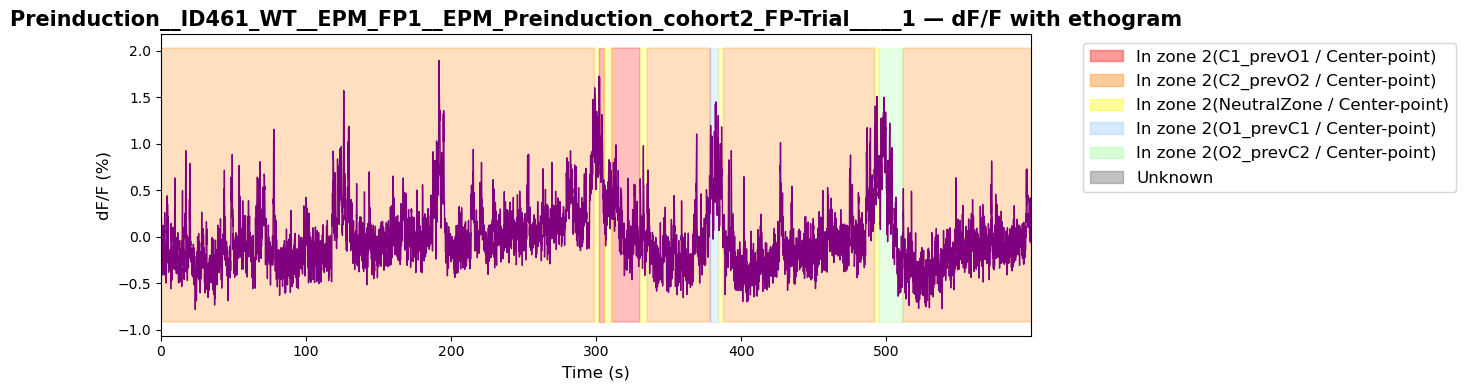

In [44]:
example_key = list(combined_trials.keys())[0]
plot_dff_with_ethogram(combined_trials[example_key], example_key)


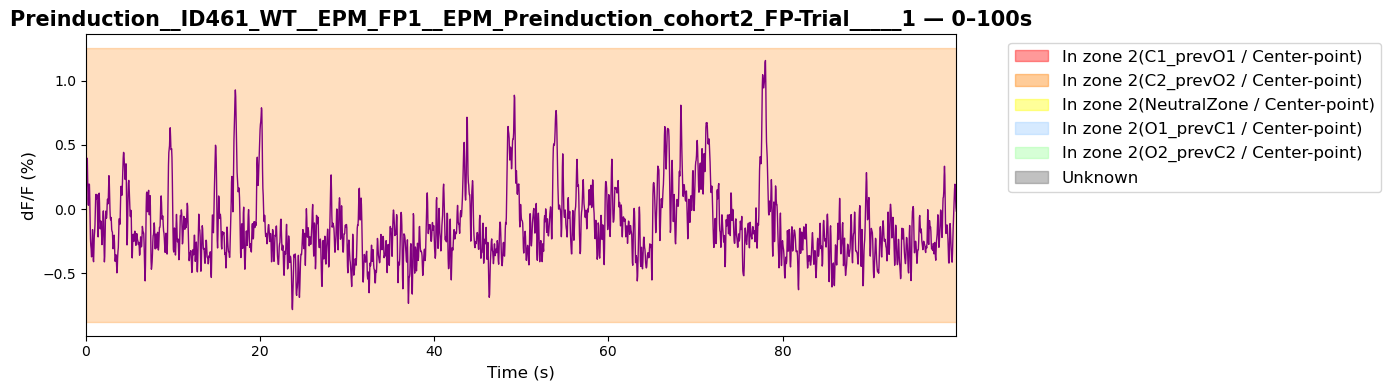

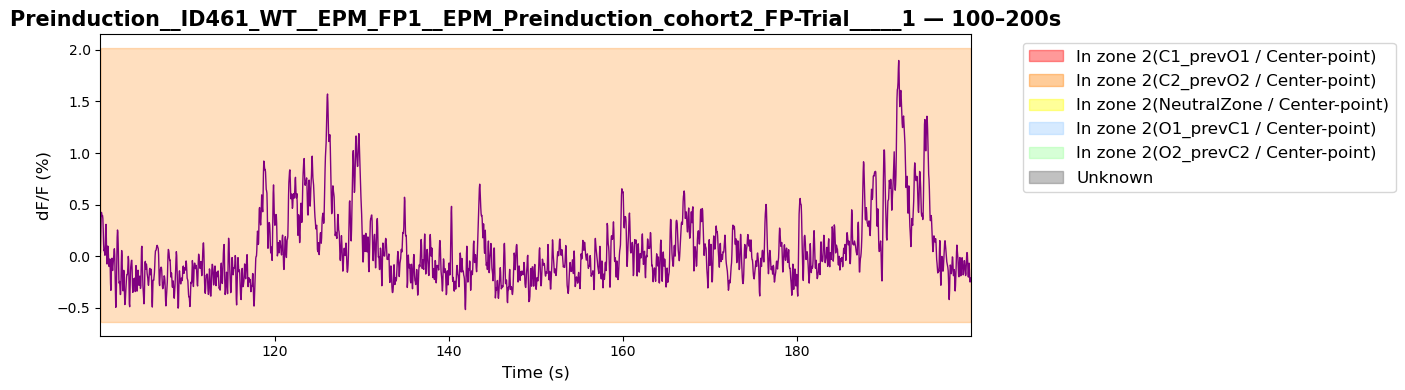

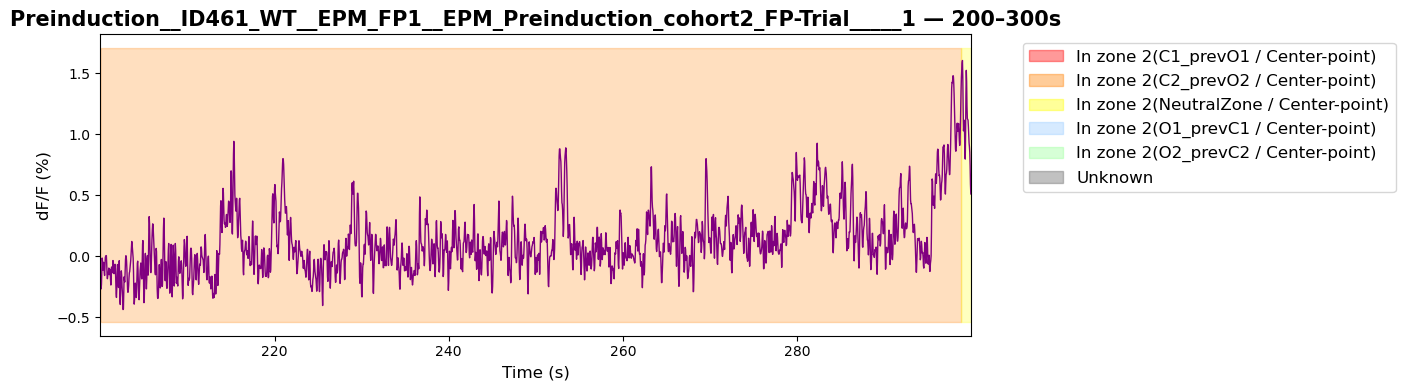

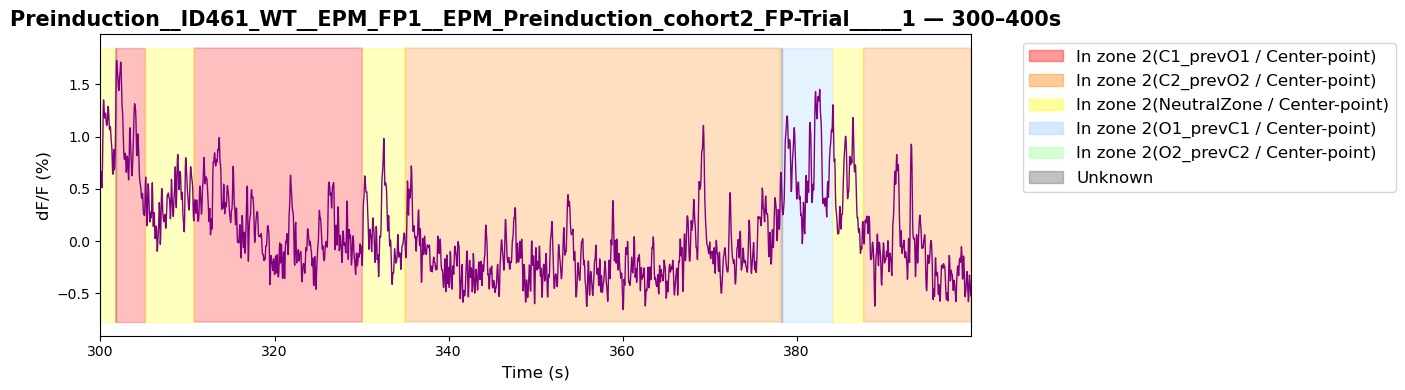

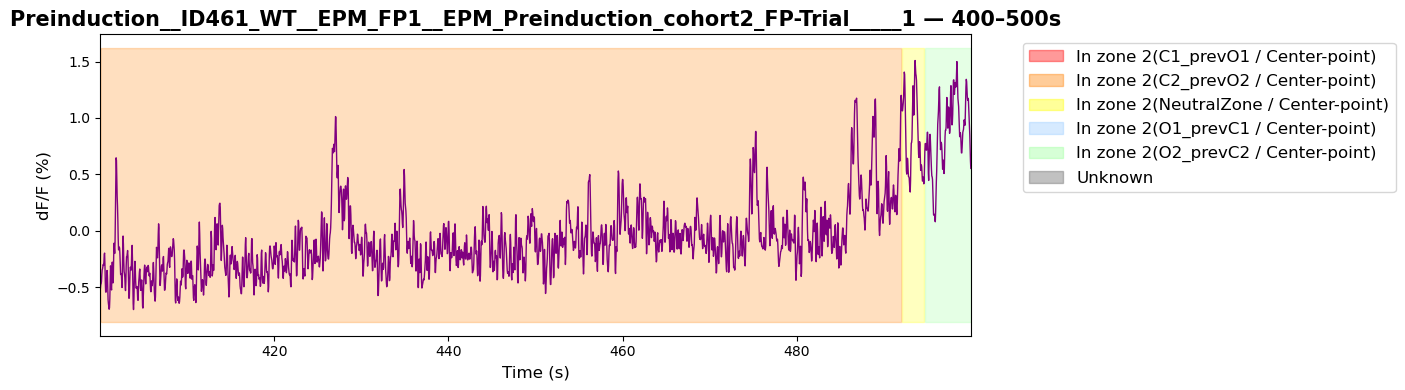

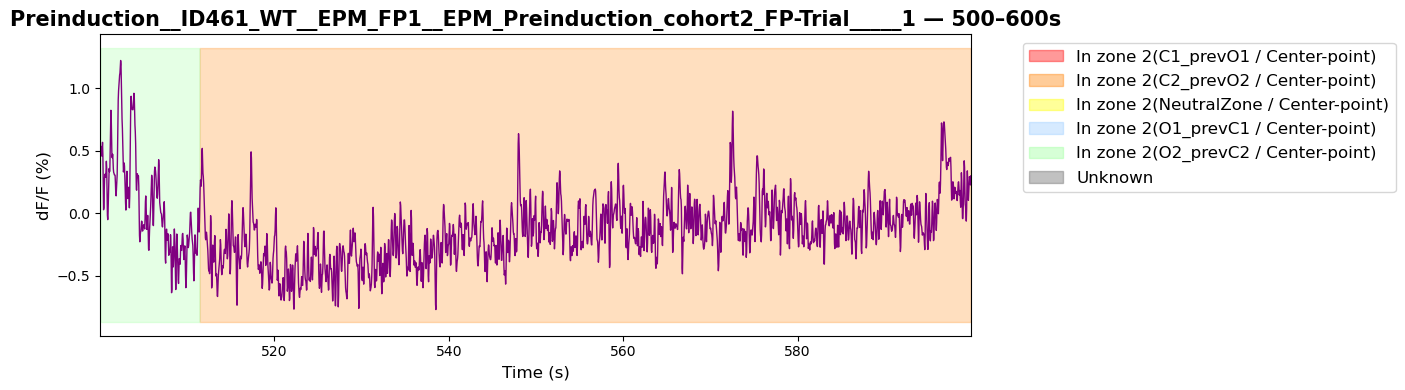

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_dff_with_ethogram_zoomed(df, key, window=100, save_dir=None):
    """
    Plot dF/F with ethogram in consecutive zoomed windows (default 100s).
    """

    time = df["Time_video"].values
    dFF = df["gcamp_dF_F"].values
    behaviors = df["Behavior"].values

    # Color map (your custom scheme)
    beh_color_map = get_behavior_color_map(behaviors)
    beh_labels = list(beh_color_map.keys())

    start = 0
    end = time.max()
    segment_idx = 0

    while start < end:
        stop = start + window
        mask_time = (time >= start) & (time < stop)

        fig, ax = plt.subplots(1, 1, figsize=(14, 4))

        # --- dF/F trace (zoomed) ---
        ax.plot(time[mask_time], dFF[mask_time],
                color="purple", linewidth=1)

        ax.set_ylabel("dF/F (%)")
        ax.set_xlabel("Time (s)")
        ax.set_title(f"{key} — {start:.0f}–{stop:.0f}s")

        # lock y-limits for ethogram overlay
        ymin, ymax = ax.get_ylim()

        # --- ethogram overlay ---
        for beh in beh_labels:
            mask = (behaviors == beh) & mask_time

            ax.fill_between(
                time,
                ymin,
                ymax,
                where=mask,
                color=beh_color_map[beh],
                alpha=0.25,
                step="post"
            )

        # --- legend ---
        handles = [
            mpatches.Patch(color=c, alpha=0.4, label=b)
            for b, c in beh_color_map.items()
        ]

        ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()

        # --- save or show ---
        if save_dir is not None:
            out = save_dir / f"{key}_zoom_{segment_idx}.png"
            plt.savefig(out, dpi=200)
            plt.close()
        else:
            plt.show()

        start += window
        segment_idx += 1

example_key = list(combined_trials.keys())[0]

plot_dff_with_ethogram_zoomed(
    combined_trials[example_key],
    example_key,
    window=100
)

# PERI EVENT PLOTS CORRECTED SIGNAL


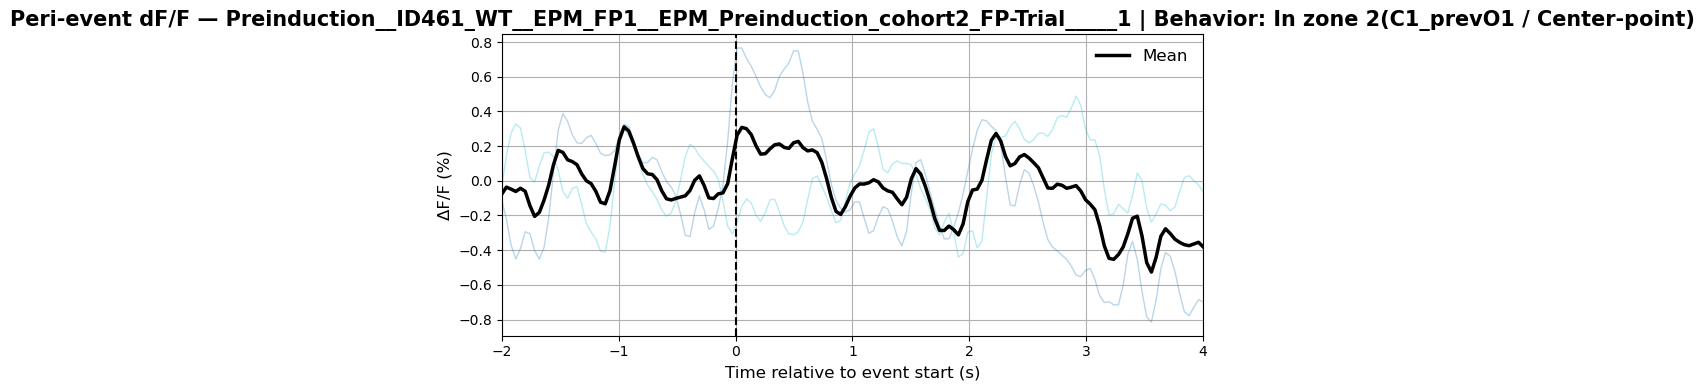

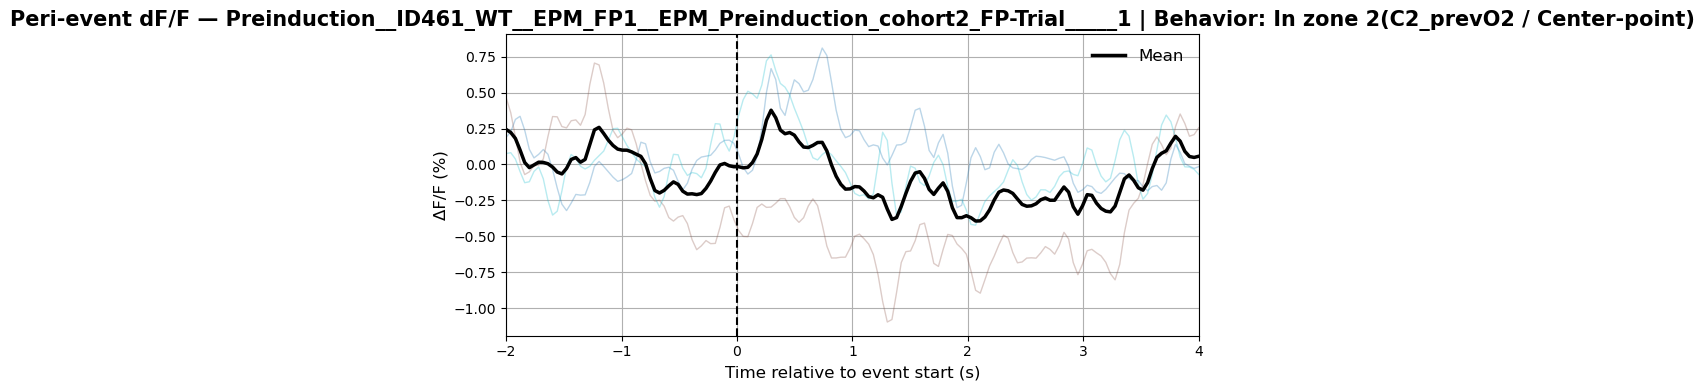

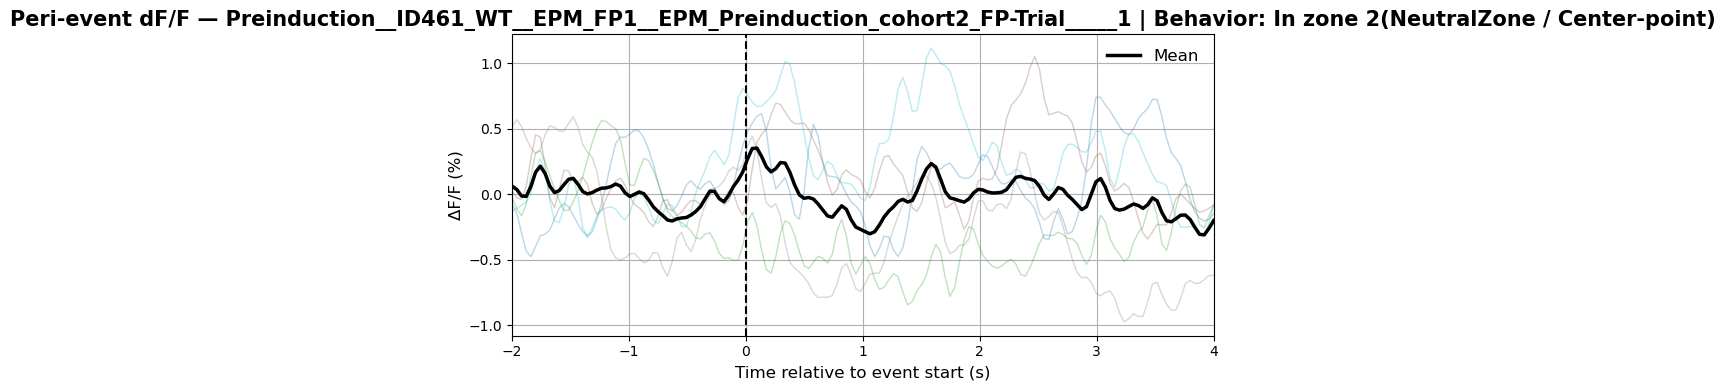

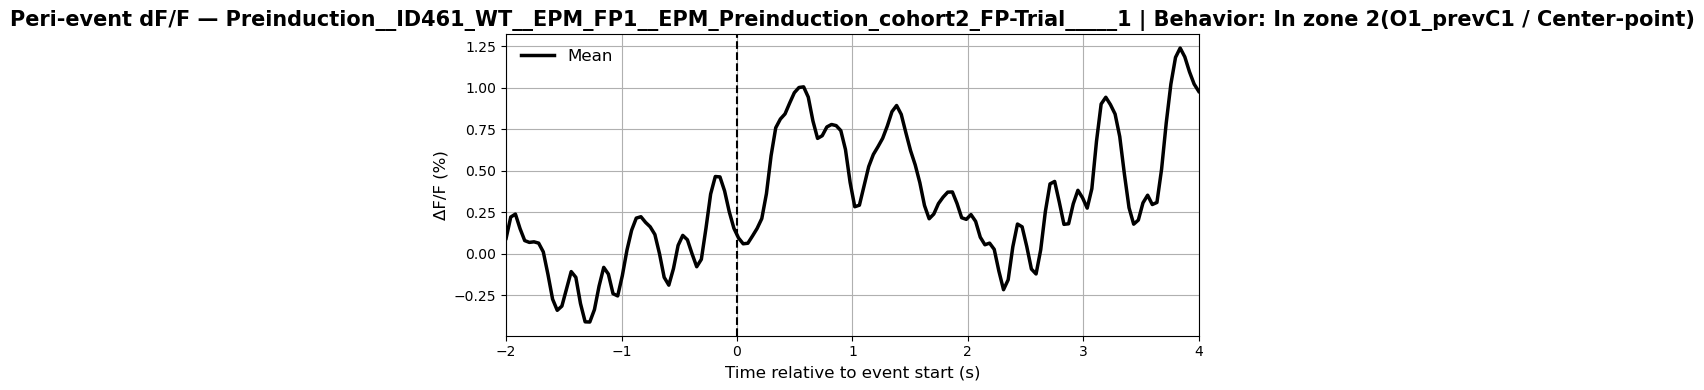

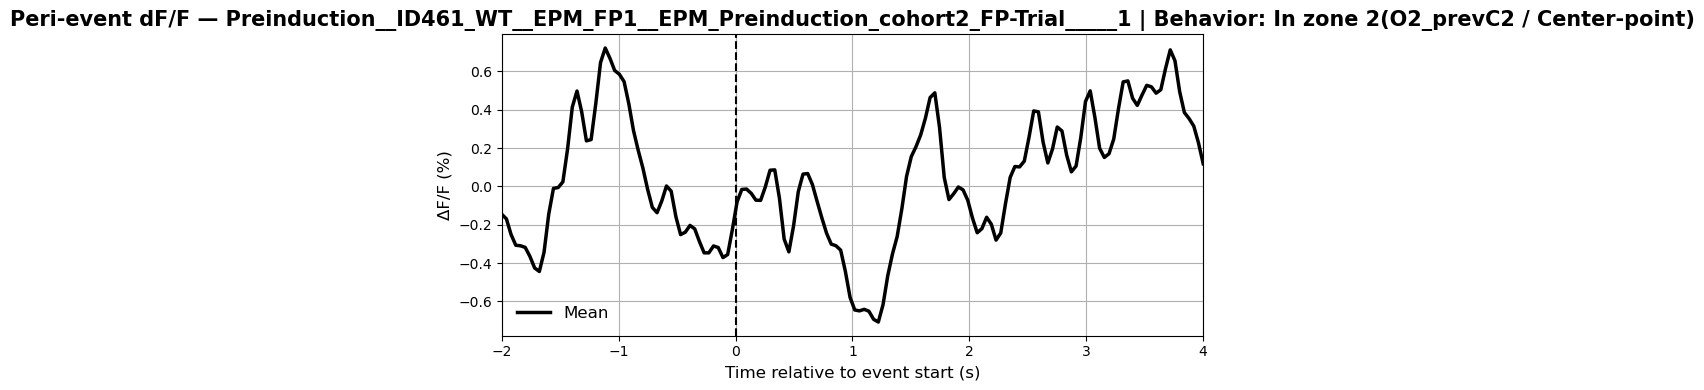

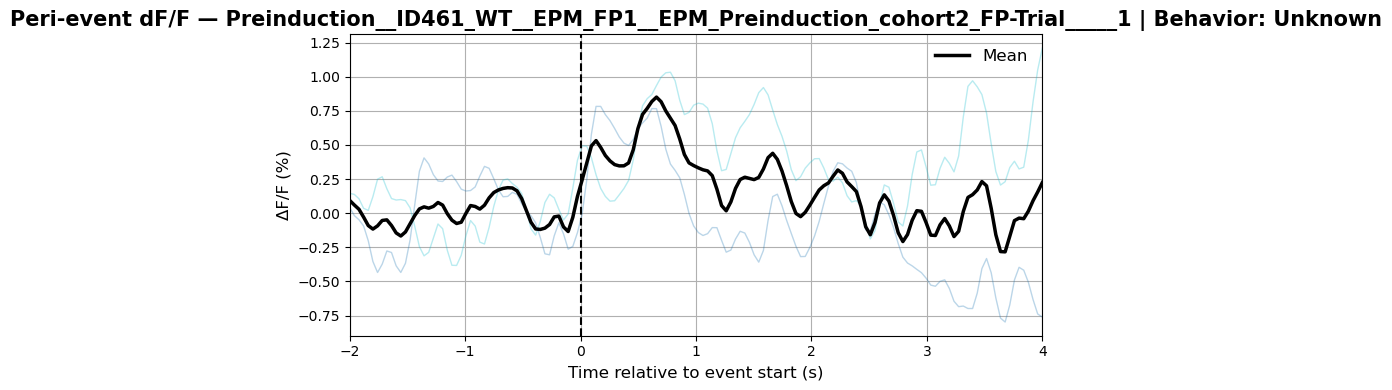

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0      # seconds before event
post_s = 4.0     # seconds after event
min_stay_s = 0   # optional, if you want to filter very short events

# Pick first trial
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()

time_vec = df["Time_video"].values
signal_vec = df["gcamp_dF_F"].values
behaviors = df["Behavior"].values

# Unique behaviors
unique_beh = np.unique(behaviors)

# Loop over behaviors
for beh in unique_beh:
    # Find event starts (transition into this behavior)
    mask = (behaviors == beh)
    mask_int = mask.astype(int)  # convert bool to int
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # rising edges

    # Skip if no events
    if len(event_starts_idx) == 0:
        print(f"No events found for {beh}")
        continue

    # Convert pre/post window to samples
    fps = 1 / np.mean(np.diff(time_vec))  # effective sampling rate
    pre_n = int(pre_s * fps)
    post_n = int(post_s * fps)

    # Collect peri-event segments
    segments = []
    for idx in event_starts_idx:
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            seg = signal_vec[idx-pre_n : idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [49]:
#okay do this, but instead of a defined time window, take the entire length of the occurrence, plus 5 s before and after the event.

In [51]:
import numpy as np
import pandas as pd

# Pick the trial
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key]

behaviors = df["Behavior"].values
unique_beh = np.unique(behaviors)

# Count number of instances (rising edges into each behavior)
event_counts = {}

for beh in unique_beh:
    mask = (behaviors == beh)
    mask_int = mask.astype(int)
    diffs = np.diff(np.r_[0, mask_int])  # prepend 0 for first element
    event_starts_idx = np.where(diffs == 1)[0]  # transitions into behavior
    event_counts[beh] = len(event_starts_idx)

# Convert to DataFrame for display
event_counts_df = pd.DataFrame.from_dict(event_counts, orient="index", columns=["Num_Instances"])
event_counts_df.index.name = "Behavior"
event_counts_df


,Num_Instances
Behavior,
In zone 2(C1_prevO1 / Center-point),2
In zone 2(C2_prevO2 / Center-point),4
In zone 2(NeutralZone / Center-point),5
In zone 2(O1_prevC1 / Center-point),1
In zone 2(O2_prevC2 / Center-point),1
Unknown,2


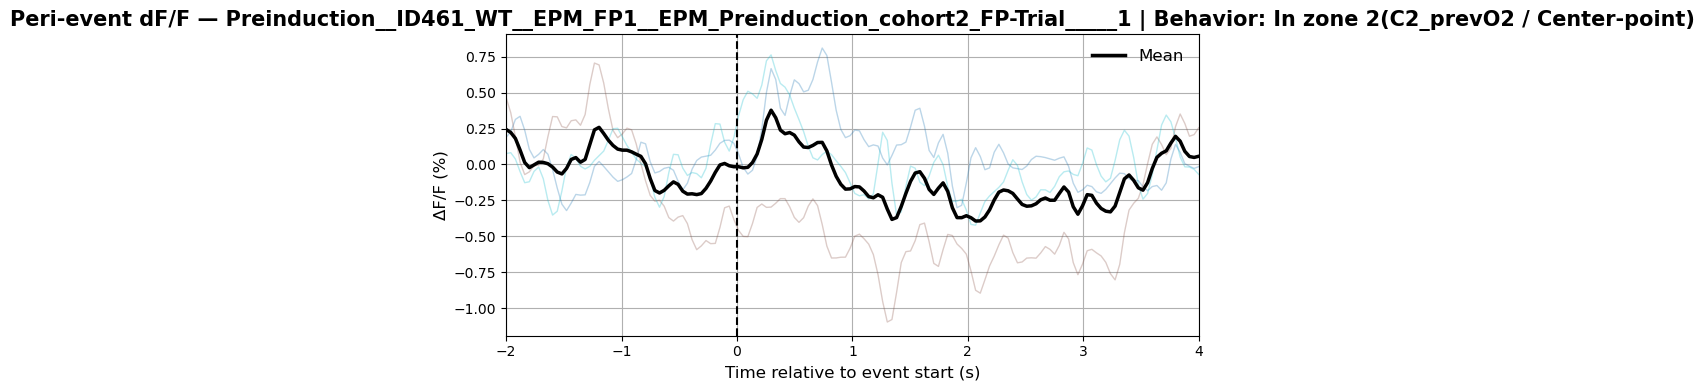

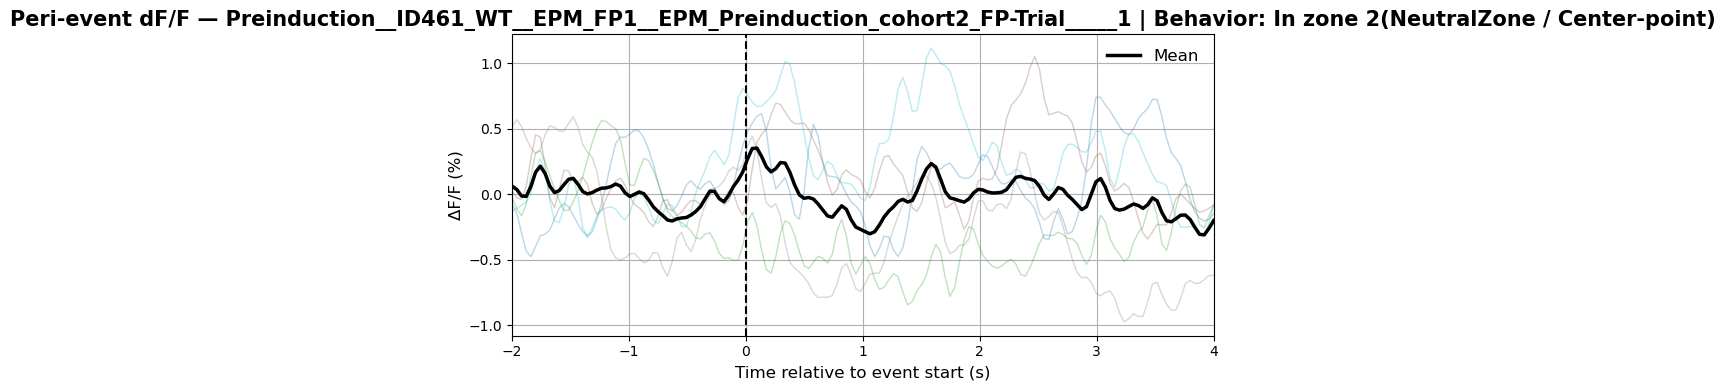

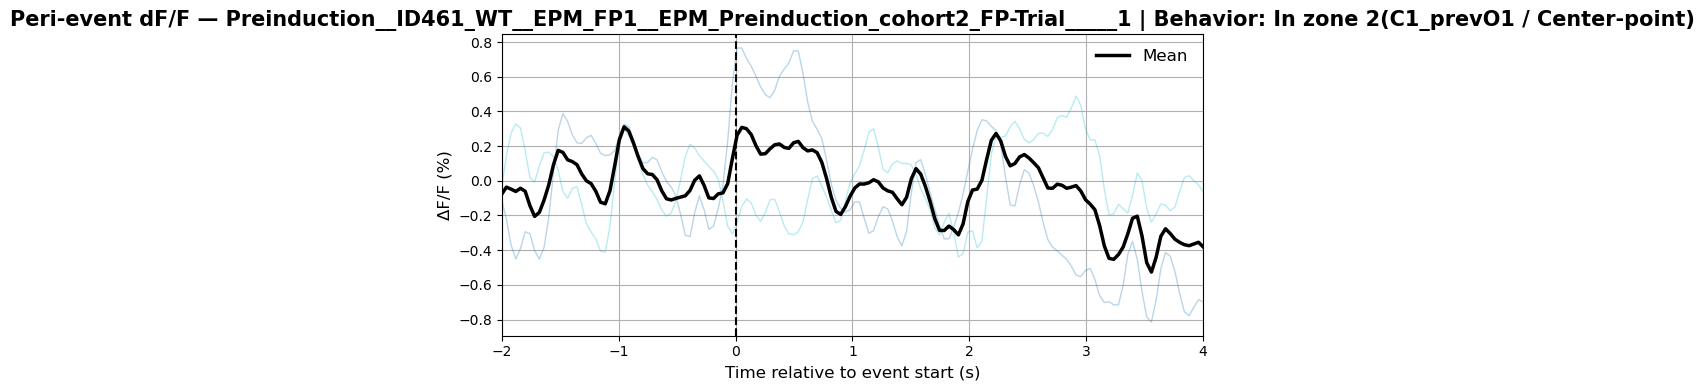

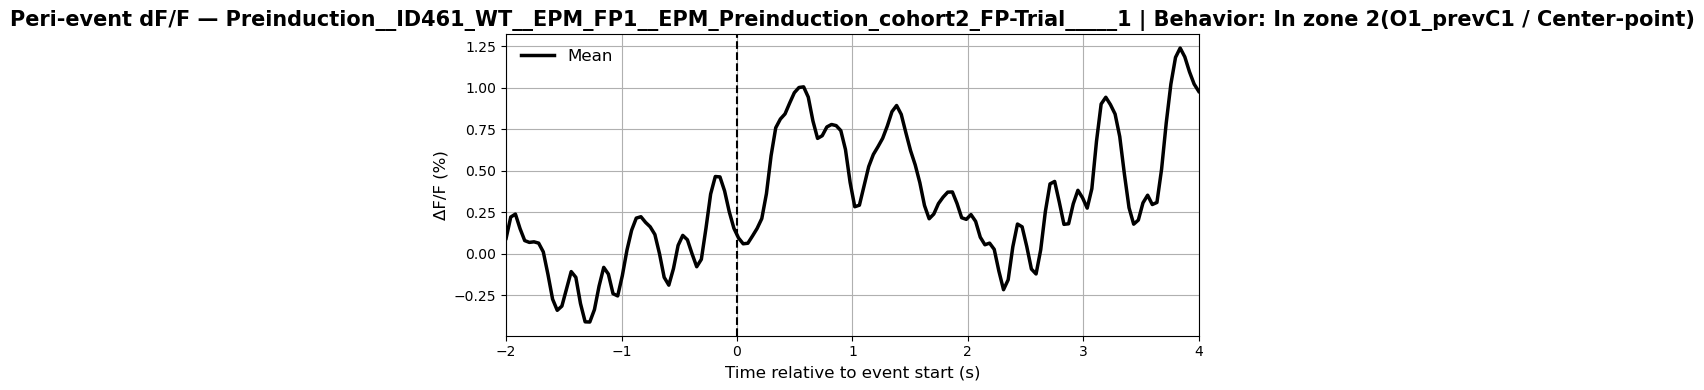

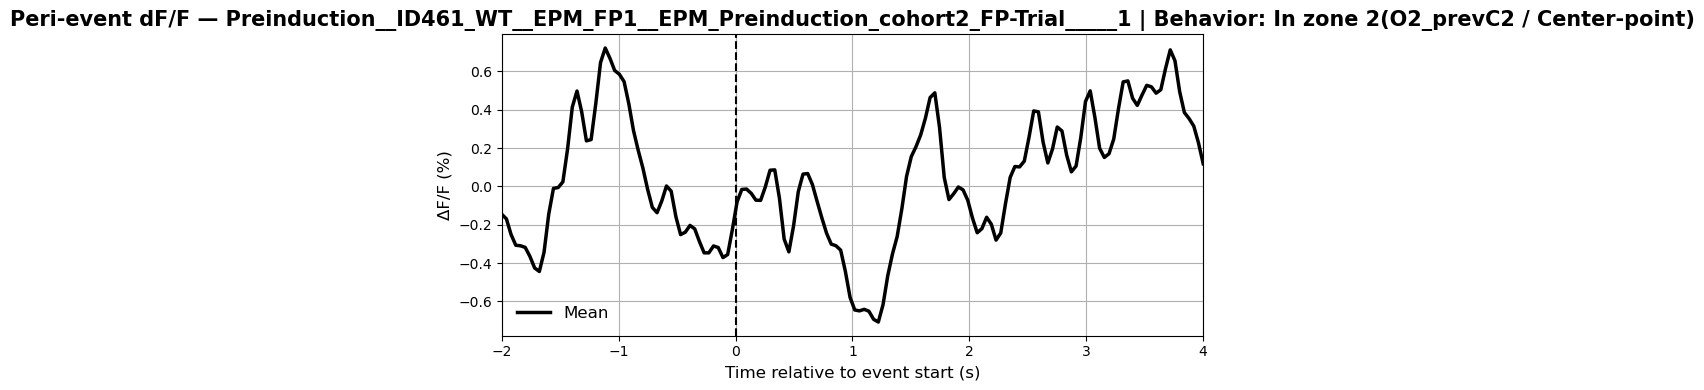

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
pre_s = 2.0   # seconds before event
post_s = 4.0  # seconds after event

# Pick first trial
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()
timeline_kernel = fp_traces[example_key]["timeline_kernel"]

signal_vec = df["gcamp_dF_F"].values
time_vec = df["Time_video"].values

# Loop over behaviors using the ethogram segments
for beh in timeline_kernel["Behavior"].unique():
    segments = []

    # Find all start-end intervals for this behavior
    intervals = timeline_kernel[timeline_kernel["Behavior"] == beh]

    for _, row in intervals.iterrows():
        # Find closest index in the FP time vector
        start_idx = np.searchsorted(time_vec, row["Start_time_s"])
        end_idx   = np.searchsorted(time_vec, row["End_time_s"])

        # Peri-event window: pre_s before start, post_s after start
        fps = 1 / np.mean(np.diff(time_vec))
        pre_n = int(pre_s * fps)
        post_n = int(post_s * fps)
        if start_idx >= pre_n and (start_idx + post_n) < len(signal_vec):
            seg = signal_vec[start_idx-pre_n : start_idx+post_n].copy()
            seg = seg - np.mean(seg[:pre_n])  # baseline correction
            segments.append(seg)

    if len(segments) == 0:
        print(f"No valid peri-event segments for {beh}")
        continue

    ERF = np.column_stack(segments)
    t_window = np.linspace(-pre_s, post_s, pre_n + post_n)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8,4))
    # Individual traces
    colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
    for i, col in enumerate(colors):
        ax.plot(t_window, ERF[:,i], color=col, alpha=0.3, lw=1)
    # Mean trace
    ax.plot(t_window, ERF.mean(axis=1), color="black", lw=2.5, label="Mean")

    ax.axvline(0, color="k", linestyle="--")
    ax.set_title(f"Peri-event dF/F — {example_key} | Behavior: {beh}")
    ax.set_xlabel("Time relative to event start (s)")
    ax.set_ylabel("ΔF/F (%)")
    ax.grid(True)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [53]:
example_key = list(combined_trials.keys())[0]
df = combined_trials[example_key].copy()

if "timeline_kernel" in fp_traces[example_key]:
    timeline_kernel = fp_traces[example_key]["timeline_kernel"]
else:
    raise ValueError(f"timeline_kernel not found for trial {example_key}")


In [54]:
# bar plots

def map_kernel_to_time_vector(time_vector, timeline_kernel):
    """
    Assign behavior to each FP timepoint exactly as in the ethogram plots.
    Fills gaps with 'Other'.
    """
    behavior_at_time = np.array(["Other"] * len(time_vector), dtype=object)
    
    for _, row in timeline_kernel.iterrows():
        mask = (time_vector >= row["Start_time_s"]) & (time_vector < row["End_time_s"])
        behavior_at_time[mask] = row["Behavior"]
    
    return behavior_at_time


combined_trials = {}

for key in coregistered_traces.keys():
    df = coregistered_traces[key].copy()
    if "timeline_kernel" in fp_traces[key]:
        timeline_kernel = fp_traces[key]["timeline_kernel"]
        df["Behavior"] = map_kernel_to_time_vector(df["Time_video"].values, timeline_kernel)
    else:
        df["Behavior"] = "Other"  # fallback
    combined_trials[key] = df

import numpy as np
import pandas as pd

# -------------------------------------------------------------
# BUILD mean_summary_df from combined_trials + fp_traces
# -------------------------------------------------------------

mean_rows = []

for trial_key, df in combined_trials.items():

    fp_info = fp_traces[trial_key]

    mouse_id  = fp_info.get("mouse_id")
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")
    week      = fp_info.get("week")

    # behavior labels + signal
    beh = df["Behavior"].values
    dff = df["gcamp_dF_F"].values

    # list of behaviors in the trial
    unique_behaviors = np.unique(beh)

    for b in unique_behaviors:

        mask = beh == b
        if mask.sum() == 0:
            continue

        mean_dff = np.nanmean(dff[mask])
        npoints  = mask.sum()

        mean_rows.append({
            "mouse_id":  mouse_id,
            "genotype":  genotype,
            "condition": condition,
            "week":      week,
            "behavior":  b,
            "mean_dFF":  mean_dff,
            "n_points":  npoints,
            "trial_key": trial_key
        })

mean_summary_df = pd.DataFrame(mean_rows)

print("Created mean_summary_df with shape:", mean_summary_df.shape)
mean_summary_df.head()


Created mean_summary_df with shape: (6, 8)


,mouse_id,genotype,condition,week,behavior,mean_dFF,n_points,trial_key
0,461,WT,None,None,In zone 2(C1_prevO1 / Center-point),0.238094,567,Preinduction__ID461_WT__EPM_FP1__EPM_Preinduct...
1,461,WT,None,None,In zone 2(C2_prevO2 / Center-point),-0.046494,13372,Preinduction__ID461_WT__EPM_FP1__EPM_Preinduct...
2,461,WT,None,None,In zone 2(NeutralZone / Center-point),0.485259,489,Preinduction__ID461_WT__EPM_FP1__EPM_Preinduct...
3,461,WT,None,None,In zone 2(O1_prevC1 / Center-point),0.707157,144,Preinduction__ID461_WT__EPM_FP1__EPM_Preinduct...
4,461,WT,None,None,In zone 2(O2_prevC2 / Center-point),0.337847,418,Preinduction__ID461_WT__EPM_FP1__EPM_Preinduct...


In [55]:
from collections import Counter

week_counts = Counter()
for fp_info in fp_traces.values():
    week_counts[fp_info.get("week")] += 1

print("Week occurrences:")
for week, count in week_counts.items():
    print(f"{week}: {count}")
    
behavior_counts = Counter()
for trial_key, trial_data in combined_trials.items():
    behaviors = trial_data["Behavior"].values
    behavior_counts.update([str(b).strip().capitalize() for b in behaviors])

print("Behavior occurrences:")
for beh, count in behavior_counts.items():
    print(f"{beh}: {count}")

Week occurrences:
None: 1
Behavior occurrences:
In zone 2(c2_prevo2 / center-point): 13372
In zone 2(neutralzone / center-point): 489
Other: 8
In zone 2(c1_prevo1 / center-point): 567
In zone 2(o1_prevc1 / center-point): 144
In zone 2(o2_prevc2 / center-point): 418


In [56]:
from collections import defaultdict, Counter

# Initialize a dict-of-dicts: week → behavior → count
behavior_per_week = defaultdict(Counter)

for trial_key, trial_data in combined_trials.items():
    fp_info = fp_traces[trial_key]
    week = fp_info.get("week", "Unknown")  # handle missing weeks

    behaviors = trial_data["Behavior"].values
    for b in behaviors:
        if b != "Other":  # skip "Other"
            behavior_per_week[week][b] += 1

# Print counts per week
for week, counts in behavior_per_week.items():
    print(f"\n=== Week: {week} ===")
    for beh, count in counts.items():
        print(f"{beh}: {count}")


=== Week: Unknown ===
In zone 2(C2_prevO2 / Center-point): 13372
In zone 2(NeutralZone / Center-point): 489
In zone 2(C1_prevO1 / Center-point): 567
In zone 2(O1_prevC1 / Center-point): 144
In zone 2(O2_prevC2 / Center-point): 418


In [57]:
import re

for trial_key, fp_info in fp_traces.items():
    # Capture W1, W2, W3, or Preinduction
    m = re.search(r"(W\d+|Preinduction)", trial_key, flags=re.IGNORECASE)
    if m:
        fp_info["week"] = m.group(1).upper().strip()  # normalize
    else:
        fp_info["week"] = "Unknown"

In [58]:
# import re
# import numpy as np
# import matplotlib.pyplot as plt


# # ==========================================================
# # NORMALIZATION HELPERS (UNCHANGED)
# # ==========================================================
# def norm(s):
#     return re.sub(r"\s+", " ", str(s)).strip().lower()


# def is_neutral(s):
#     return "neutralzone" in norm(s)


# def is_other(s):
#     return norm(s) == "other"


# # ==========================================================
# # PRECEDING BEHAVIOR LOGIC (FIXED TO MATCH ETHOGRAM)
# # ==========================================================
# def valid_preceding_behavior(behaviors, idx, prev_behaviors):
#     """
#     Walk backwards until first meaningful behavior.
#     Skip BOTH neutralzone and other.
#     """

#     if idx <= 0:
#         return False

#     prev_set = set(map(norm, prev_behaviors))

#     i = idx - 1

#     # BACKWARD SCAN (KEY FIX)
#     while i >= 0:
#         b = behaviors[i]
#         nb = norm(b)

#         # SKIP NON-INFORMATIVE STATES
#         if is_neutral(nb) or is_other(nb):
#             i -= 1
#             continue

#         # FIRST MEANINGFUL STATE DECIDES
#         return nb in prev_set

#     return False


# # ==========================================================
# # MAIN FUNCTION (UNCHANGED EXCEPT LOGIC ABOVE)
# # ==========================================================
# def funfunfunction(main_behaviors=None, prev_behaviors=None):

#     print("\n========== RUN DEBUG ==========")
#     print("main_behaviors:", main_behaviors)
#     print("prev_behaviors:", prev_behaviors)
#     print("n trials:", len(combined_trials))

#     # ---------- PARAMETERS ----------
#     pre_s = 2.0
#     post_s = 4.0

#     # ---------- NORMALIZE FP_TRACES AND BEHAVIORS ----------
#     for trial_key, fp_info in fp_traces.items():
#         wk = fp_info.get("week", "")
#         if wk:
#             fp_info["week"] = wk.capitalize()
#         else:
#             m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
#             fp_info["week"] = m.group(1).capitalize() if m else None

#     for trial_key, trial_data in combined_trials.items():
#         normalized = []
#         for b in trial_data["Behavior"].values:
#             if isinstance(b, str) and b.lower() == "other":
#                 normalized.append("Other")
#             else:
#                 normalized.append(re.sub(r"Zone\s*\d*", "Zone", str(b), flags=re.IGNORECASE))
#         trial_data["Behavior"] = np.array(normalized)

#     # ---------- COLLECT METADATA ----------
#     all_weeks = set()
#     all_genotypes = set()

#     for trial_key, trial_data in combined_trials.items():
#         fp_info = fp_traces[trial_key]
#         wk = fp_info.get("week")
#         if wk:
#             all_weeks.add(wk)
#         all_genotypes.add(fp_info.get("genotype"))

#     week_order = ["Preinduction", "W1", "W2", "W3"]
#     all_weeks = sorted(all_weeks, key=lambda w: week_order.index(w))
#     all_genotypes = sorted(all_genotypes)

#     print(f"Weeks detected: {all_weeks}")
#     print(f"Genotypes detected: {all_genotypes}")

#     # ==========================================================
#     # FIGURE
#     # ==========================================================
#     fig, axes = plt.subplots(
#         len(all_weeks),
#         len(all_genotypes),
#         figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
#         sharey=True,
#         sharex=True
#     )

#     if len(all_weeks) == 1:
#         axes = [axes]
#     if len(all_genotypes) == 1:
#         axes = [[axes[r]] for r in range(len(axes))]

#     # ==========================================================
#     # MAIN LOOP
#     # ==========================================================
#     for r, week in enumerate(all_weeks):
#         for c, genotype in enumerate(all_genotypes):
#             ax = axes[r][c]

#             mouse_segments = []
#             mouse_lengths = []

#             for trial_key, trial_data in combined_trials.items():
#                 fp_info = fp_traces[trial_key]

#                 if fp_info.get("week") != week:
#                     continue
#                 if fp_info.get("genotype") != genotype:
#                     continue

#                 df = trial_data.copy()
#                 time_vec = df["Time_video"].values
#                 signal_vec = df["gcamp_dF_F"].values
#                 behaviors = np.array(df["Behavior"].values)

#                 print("\n--- TRIAL ---", trial_key)
#                 print("behavior sample:", behaviors[:10])

#                 # ==================================================
#                 # MAIN EVENT DETECTION (UNCHANGED)
#                 # ==================================================
#                 main_set = set(map(norm, main_behaviors))

#                 is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)

#                 starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

#                 # PRECEDING FILTER (NOW ETHOGRAM-CONSISTENT)
#                 starts = [
#                     i for i in starts
#                     if valid_preceding_behavior(behaviors, i, prev_behaviors)
#                 ]

#                 if len(starts) == 0:
#                     continue

#                 fps = 1.0 / np.mean(np.diff(time_vec))
#                 pre_n = int(pre_s * fps)
#                 post_n = int(post_s * fps)

#                 event_segments = []

#                 for idx in starts:
#                     start_idx = idx - pre_n
#                     stop_idx = idx + post_n

#                     seg = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()
#                     if len(seg) == 0:
#                         continue

#                     pre_end = min(pre_n, len(seg))
#                     seg -= np.mean(seg[:pre_end])

#                     event_segments.append(seg)

#                 if len(event_segments) == 0:
#                     continue

#                 max_len = max(len(s) for s in event_segments)
#                 padded = np.full((len(event_segments), max_len), np.nan)

#                 for i, s in enumerate(event_segments):
#                     padded[i, :len(s)] = s

#                 mouse_mean = np.nanmean(padded, axis=0)
#                 mouse_segments.append(mouse_mean)
#                 mouse_lengths.append(len(mouse_mean))

#             # ==================================================
#             # NOTHING TO PLOT
#             # ==================================================
#             if len(mouse_segments) == 0:
#                 ax.set_title(f"{week} | {genotype}\n(no events)")
#                 ax.grid(True)
#                 continue

#             # ==================================================
#             # PLOT
#             # ==================================================
#             target_len = max(mouse_lengths)
#             padded_mouse = np.full((len(mouse_segments), target_len), np.nan)

#             for i, seg in enumerate(mouse_segments):
#                 padded_mouse[i, :len(seg)] = seg

#             t_window = np.linspace(-pre_s, post_s, target_len)

#             for i, seg in enumerate(padded_mouse):
#                 ax.plot(t_window, seg, alpha=0.4, lw=1.5)

#             ax.plot(t_window, np.nanmean(padded_mouse, axis=0), color="black", lw=2.5)

#             ax.axvline(0, color='k', linestyle='--')
#             ax.set_title(f"{week} | {genotype}")
#             ax.grid(True)

#             if r == len(all_weeks) - 1:
#                 ax.set_xlabel("Time (s)")
#             if c == 0:
#                 ax.set_ylabel("ΔF/F (%)")

#     plt.suptitle(
#         "Peri-event dF/F\n"
#         "Main behaviors: " + ", ".join(main_behaviors) + "\n"
#         "Preceding behaviors: " + ", ".join(prev_behaviors),
#         fontsize=18
#     )

#     plt.tight_layout()
#     plt.show()


# # ==========================================================
# # RUN
# # ==========================================================

# funfunfunction(
#     main_behaviors=['In Zone(c1_prevo1 / nose-point)', 'In Zone(c2_prevo2 / nose-point)'],
#     prev_behaviors=['In Zone(o1_prevc1 / nose-point)', 'In Zone(o2_prevc2 / nose-point)','In Zone(o1_round / nose-point)','In Zone(o2_round / nose-point)']
# )

# # funfunfunction(
# #     main_behaviors=['In Zone(o1_prevc1 / nose-point)', 'In Zone(o2_prevc2 / nose-point)','In Zone(o1_round / nose-point)','In Zone(o2_round / nose-point)'],
# #     prev_behaviors=['In Zone(c1_prevo1 / nose-point)', 'In Zone(c2_prevo2 / nose-point)']
# # )

#IMPORTANT the peri event plots use baseline normalization

for every detected behaviour event, you subtract the average signal calculated during the time JUST BEFORE THE EVENT STARTS, so the baseline becomes zero - makes sense so all plot traces are aligned

In [59]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# NORMALIZATION HELPERS
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"


# ==========================================================
# PRECEDING BEHAVIOR LOGIC
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(map(norm, prev_behaviors))

    i = idx - 1

    while i >= 0:
        b = behaviors[i]
        nb = norm(b)

        if is_neutral(nb) or is_other(nb):
            i -= 1
            continue

        return nb in prev_set

    return False


# ==========================================================
# MAIN FUNCTION
# ==========================================================
def funfunfunction(
    main_behaviors=None,
    prev_behaviors=None,
    plot_title="peri_event_plot",
    weeks_to_plot=None,
    genotype_include=None   # 🔥 NEW
):

    print("\n========== RUN DEBUG ==========")
    print("main_behaviors:", main_behaviors)
    print("prev_behaviors:", prev_behaviors)
    print("weeks_to_plot:", weeks_to_plot)
    print("genotype_include:", genotype_include)
    print("n trials:", len(combined_trials))

    # ---------- PARAMETERS ----------
    pre_s = 2.0
    post_s = 4.0

    # ---------- NORMALIZE FP_TRACES AND BEHAVIORS ----------
    for trial_key, fp_info in fp_traces.items():
        wk = fp_info.get("week", "")
        if wk:
            fp_info["week"] = wk.capitalize()
        else:
            m = re.search(r"(Preinduction|W1|W2|W3)", trial_key, flags=re.IGNORECASE)
            fp_info["week"] = m.group(1).capitalize() if m else None

    for trial_key, trial_data in combined_trials.items():
        normalized = []
        for b in trial_data["Behavior"].values:
            if isinstance(b, str) and b.lower() == "other":
                normalized.append("Other")
            else:
                normalized.append(re.sub(r"Zone\s*\d*", "Zone", str(b), flags=re.IGNORECASE))
        trial_data["Behavior"] = np.array(normalized)

    # ---------- COLLECT METADATA ----------
    all_weeks = set()
    all_genotypes = set()

    for trial_key, trial_data in combined_trials.items():
        fp_info = fp_traces[trial_key]

        wk = fp_info.get("week")
        if wk:
            all_weeks.add(wk)

        g = fp_info.get("genotype")
        if g:
            all_genotypes.add(g)

    week_order = ["Preinduction", "W1", "W2", "W3"]
    all_weeks = sorted(all_weeks, key=lambda w: week_order.index(w))
    all_genotypes = sorted(all_genotypes)

    # ---------- FILTER WEEKS ----------
    if weeks_to_plot is not None:
        weeks_to_plot = set(map(str, weeks_to_plot))
        all_weeks = [w for w in all_weeks if w in weeks_to_plot]

    # ---------- FILTER GENOTYPES (WT SUPPORT) ----------
    if genotype_include is not None:
        allowed = set(g.lower() for g in genotype_include)
        all_genotypes = [g for g in all_genotypes if g.lower() in allowed]

    print(f"Weeks used: {all_weeks}")
    print(f"Genotypes used: {all_genotypes}")

    # ==========================================================
    # FIGURE
    # ==========================================================
    fig, axes = plt.subplots(
        len(all_weeks),
        len(all_genotypes),
        figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
        sharey=True,
        sharex=True
    )

    if len(all_weeks) == 1:
        axes = [axes]
    if len(all_genotypes) == 1:
        axes = [[axes[r]] for r in range(len(axes))]

    main_set = set(map(norm, main_behaviors))

    # ==========================================================
    # MAIN LOOP
    # ==========================================================
    for r, week in enumerate(all_weeks):
        for c, genotype in enumerate(all_genotypes):

            ax = axes[r][c]

            mouse_segments = []
            mouse_lengths = []

            for trial_key, trial_data in combined_trials.items():
                fp_info = fp_traces[trial_key]

                if fp_info.get("week") != week:
                    continue
                if fp_info.get("genotype") != genotype:
                    continue

                df = trial_data.copy()
                time_vec = df["Time_video"].values
                signal_vec = df["gcamp_dF_F"].values #this is where it grabs the dff values
                behaviors = np.array(df["Behavior"].values)

                is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
                starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

                starts = [
                    i for i in starts
                    if valid_preceding_behavior(behaviors, i, prev_behaviors)
                ]

                if len(starts) == 0:
                    continue

                fps = 1.0 / np.mean(np.diff(time_vec))
                pre_n = int(pre_s * fps)
                post_n = int(post_s * fps)

                event_segments = []

                for idx in starts:
                    start_idx = idx - pre_n
                    stop_idx = idx + post_n

                    seg = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()
                    if len(seg) == 0:
                        continue

                    pre_end = min(pre_n, len(seg))
                    seg -= np.mean(seg[:pre_end])

                    event_segments.append(seg)

                if len(event_segments) == 0:
                    continue

                max_len = max(len(s) for s in event_segments)
                padded = np.full((len(event_segments), max_len), np.nan)

                for i, s in enumerate(event_segments):
                    padded[i, :len(s)] = s

                mouse_segments.append(np.nanmean(padded, axis=0))
                mouse_lengths.append(len(mouse_segments[-1]))

            if len(mouse_segments) == 0:
                ax.set_title(f"{week} | {genotype}\n(no events)")
                ax.grid(True)
                continue

            target_len = max(mouse_lengths)
            padded_mouse = np.full((len(mouse_segments), target_len), np.nan)

            for i, seg in enumerate(mouse_segments):
                padded_mouse[i, :len(seg)] = seg

            t_window = np.linspace(-pre_s, post_s, target_len)

            for i, seg in enumerate(padded_mouse):
                ax.plot(t_window, seg, alpha=0.4, lw=1.5)

            ax.plot(t_window, np.nanmean(padded_mouse, axis=0), color="black", lw=2.5)

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f"{week} | {genotype}")
            ax.grid(True)

            if r == len(all_weeks) - 1:
                ax.set_xlabel("Time (s)")
            if c == 0:
                ax.set_ylabel("ΔF/F (%)")

    # ==========================================================
    # SAVE
    # ==========================================================
    plt.suptitle(plot_title, fontsize=18)
    plt.tight_layout()

    save_dir = "transition trace plots"
    os.makedirs(save_dir, exist_ok=True)

    safe_title = re.sub(r"[^\w\-]+", "_", plot_title.strip())
    save_path = os.path.join(save_dir, safe_title + ".svg")
 
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"\nSaved figure to: {save_path}")

    plt.show()

# ==========================================================
# RUN
# ==========================================================
funfunfunction(
    main_behaviors=['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)'],
    prev_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],weeks_to_plot=["Preinduction", "W2"],
    genotype_include=["NE"],
    plot_title="Open to Closed transition trace plots Pre and W2"
)

funfunfunction(
    main_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],weeks_to_plot=["Preinduction", "W2"], # edit ehich weeks are included
    prev_behaviors=['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)'],
    genotype_include=["NE"],
    plot_title="Closed to Open transition trace plots Pre and W2"
)




========== RUN DEBUG ==========
main_behaviors: ['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)']
prev_behaviors: ['In Zone(o1_prevc1 / center-point)', 'In Zone(o2_prevc2 / center-point)', 'In Zone(o1_round / center-point)', 'In Zone(o2_round / center-point)']
weeks_to_plot: ['Preinduction', 'W2']
genotype_include: ['NE']
n trials: 1
Weeks used: ['Preinduction']
Genotypes used: []


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x400 with 0 Axes>

In [60]:
# ==============================
# PRINT MICE THAT ACTUALLY GOT PLOTTED
# (robust version using your data directly)
# ==============================

plotted_mice = set()

# grab filters directly from what you used in the function call
weeks_to_plot_used = ["Preinduction", "W2"]
genotype_include_used = ["NE"]

for trial_key, trial_data in combined_trials.items():

    fp_info = fp_traces.get(trial_key, {})

    week = fp_info.get("week")
    genotype = fp_info.get("genotype")

    if week is None or genotype is None:
        continue

    # same filters you used in plotting
    if week not in weeks_to_plot_used:
        continue

    if genotype not in genotype_include_used:
        continue

    df = trial_data.copy()
    behaviors = np.array(df["Behavior"].values)

    # rebuild same main logic used in plot
    main_set = set([
        "in zone(c1_prevo1 / center-point)",
        "in zone(c2_prevo2 / center-point)"
    ])

    is_main = np.array([str(b).strip().lower() in main_set for b in behaviors]).astype(int)
    starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

    # must have valid transitions
    if len(starts) > 0:
        plotted_mice.add(fp_info.get("mouse_id", trial_key))


print("\n============================")
print("MICE ACTUALLY PLOTTED")
print("============================")

for m in sorted(plotted_mice):
    print(m)

print(f"\nTotal mice plotted: {len(plotted_mice)}")


MICE ACTUALLY PLOTTED

Total mice plotted: 0


In [62]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# NORMALIZATION HELPERS
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"


# ==========================================================
# PRECEDING BEHAVIOR LOGIC
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(map(norm, prev_behaviors))

    i = idx - 1

    while i >= 0:
        b = behaviors[i]
        nb = norm(b)

        if is_neutral(nb) or is_other(nb):
            i -= 1
            continue

        return nb in prev_set

    return False


# ==========================================================
# MAIN FUNCTION
# ==========================================================
def funfunfunction(
    main_behaviors=None,
    prev_behaviors=None,
    plot_title="peri_event_plot",
    weeks_to_plot=None,
    genotype_include=None   # 🔥 NEW
):

    print("\n========== RUN DEBUG ==========")
    print("main_behaviors:", main_behaviors)
    print("prev_behaviors:", prev_behaviors)
    print("weeks_to_plot:", weeks_to_plot)
    print("genotype_include:", genotype_include)
    print("n trials:", len(combined_trials))

    # ---------- PARAMETERS ----------
    pre_s = 2.0
    post_s = 4.0

    # ---------- NORMALIZE FP_TRACES AND BEHAVIORS ----------
    for trial_key, fp_info in fp_traces.items():
        wk = fp_info.get("week", "")
        if wk:
            fp_info["week"] = wk.capitalize()
        else:
            m = re.search(r"(Preinduction|W1|W2|W3)", trial_key, flags=re.IGNORECASE)
            fp_info["week"] = m.group(1).capitalize() if m else None

    for trial_key, trial_data in combined_trials.items():
        normalized = []
        for b in trial_data["Behavior"].values:
            if isinstance(b, str) and b.lower() == "other":
                normalized.append("Other")
            else:
                normalized.append(re.sub(r"Zone\s*\d*", "Zone", str(b), flags=re.IGNORECASE))
        trial_data["Behavior"] = np.array(normalized)

    # ---------- COLLECT METADATA ----------
    all_weeks = set()
    all_genotypes = set()

    for trial_key, trial_data in combined_trials.items():
        fp_info = fp_traces[trial_key]

        wk = fp_info.get("week")
        if wk:
            all_weeks.add(wk)

        g = fp_info.get("genotype")
        if g:
            all_genotypes.add(g)

    week_order = ["Preinduction", "W1", "W2", "W3"]
    all_weeks = sorted(all_weeks, key=lambda w: week_order.index(w))
    all_genotypes = sorted(all_genotypes)

    # ---------- FILTER WEEKS ----------
    if weeks_to_plot is not None:
        weeks_to_plot = set(map(str, weeks_to_plot))
        all_weeks = [w for w in all_weeks if w in weeks_to_plot]

    # ---------- FILTER GENOTYPES (WT SUPPORT) ----------
    if genotype_include is not None:
        allowed = set(g.lower() for g in genotype_include)
        all_genotypes = [g for g in all_genotypes if g.lower() in allowed]

    print(f"Weeks used: {all_weeks}")
    print(f"Genotypes used: {all_genotypes}")

    # ==========================================================
    # FIGURE
    # ==========================================================
    fig, axes = plt.subplots(
        len(all_weeks),
        len(all_genotypes),
        figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
        sharey=True,
        sharex=True
    )

    if len(all_weeks) == 1:
        axes = [axes]
    if len(all_genotypes) == 1:
        axes = [[axes[r]] for r in range(len(axes))]

    main_set = set(map(norm, main_behaviors))

    # ==========================================================
    # MAIN LOOP
    # ==========================================================
    for r, week in enumerate(all_weeks):
        for c, genotype in enumerate(all_genotypes):

            ax = axes[r][c]

            mouse_segments = []
            mouse_lengths = []

            for trial_key, trial_data in combined_trials.items():
                fp_info = fp_traces[trial_key]

                if fp_info.get("week") != week:
                    continue
                if fp_info.get("genotype") != genotype:
                    continue

                df = trial_data.copy()
                time_vec = df["Time_video"].values
                signal_vec = df["gcamp_dF_F"].values #this is where it grabs the dff values
                behaviors = np.array(df["Behavior"].values)

                is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
                starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

                starts = [
                    i for i in starts
                    if valid_preceding_behavior(behaviors, i, prev_behaviors)
                ]

                if len(starts) == 0:
                    continue

                fps = 1.0 / np.mean(np.diff(time_vec))
                pre_n = int(pre_s * fps)
                post_n = int(post_s * fps)

                event_segments = []

                for idx in starts:
                    start_idx = idx - pre_n
                    stop_idx = idx + post_n

                    seg = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()
                    if len(seg) == 0:
                        continue

                    pre_end = min(pre_n, len(seg))
                    #seg -= np.mean(seg[:pre_end])

                    event_segments.append(seg)

                if len(event_segments) == 0:
                    continue

                max_len = max(len(s) for s in event_segments)
                padded = np.full((len(event_segments), max_len), np.nan)

                for i, s in enumerate(event_segments):
                    padded[i, :len(s)] = s

                mouse_segments.append(np.nanmean(padded, axis=0))
                mouse_lengths.append(len(mouse_segments[-1]))

            if len(mouse_segments) == 0:
                ax.set_title(f"{week} | {genotype}\n(no events)")
                ax.grid(True)
                continue

            target_len = max(mouse_lengths)
            padded_mouse = np.full((len(mouse_segments), target_len), np.nan)

            for i, seg in enumerate(mouse_segments):
                padded_mouse[i, :len(seg)] = seg

            t_window = np.linspace(-pre_s, post_s, target_len)

            for i, seg in enumerate(padded_mouse):
                ax.plot(t_window, seg, alpha=0.4, lw=1.5)

            ax.plot(t_window, np.nanmean(padded_mouse, axis=0), color="black", lw=2.5)

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f"{week} | {genotype}")
            ax.grid(True)

            if r == len(all_weeks) - 1:
                ax.set_xlabel("Time (s)")
            if c == 0:
                ax.set_ylabel("ΔF/F (%)")

    # ==========================================================
    # SAVE
    # ==========================================================
    plt.suptitle(plot_title, fontsize=18)
    plt.tight_layout()

    save_dir = "transition trace plots"
    os.makedirs(save_dir, exist_ok=True)

    safe_title = re.sub(r"[^\w\-]+", "_", plot_title.strip())
    save_path = os.path.join(save_dir, safe_title + ".svg")
 
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"\nSaved figure to: {save_path}")

    plt.show()

# ==========================================================
# RUN
# ==========================================================
funfunfunction(
    main_behaviors=['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)'],
    prev_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],weeks_to_plot=["Preinduction", "W2"],
    genotype_include=["NE"],
    plot_title="Open to Closed transition trace plots Pre and W2 no baseline subtraction"
)

funfunfunction(
    main_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],weeks_to_plot=["Preinduction", "W2"], # edit ehich weeks are included
    prev_behaviors=['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)'],
    genotype_include=["NE"],
    plot_title="Closed to Open transition trace plots Pre and W2 no baseline subtraction"
)



========== RUN DEBUG ==========
main_behaviors: ['In Zone(c1_prevo1 / center-point)', 'In Zone(c2_prevo2 / center-point)']
prev_behaviors: ['In Zone(o1_prevc1 / center-point)', 'In Zone(o2_prevc2 / center-point)', 'In Zone(o1_round / center-point)', 'In Zone(o2_round / center-point)']
weeks_to_plot: ['Preinduction', 'W2']
genotype_include: ['NE']
n trials: 1
Weeks used: ['Preinduction']
Genotypes used: []


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x400 with 0 Axes>

#ethogram code using peri event logic


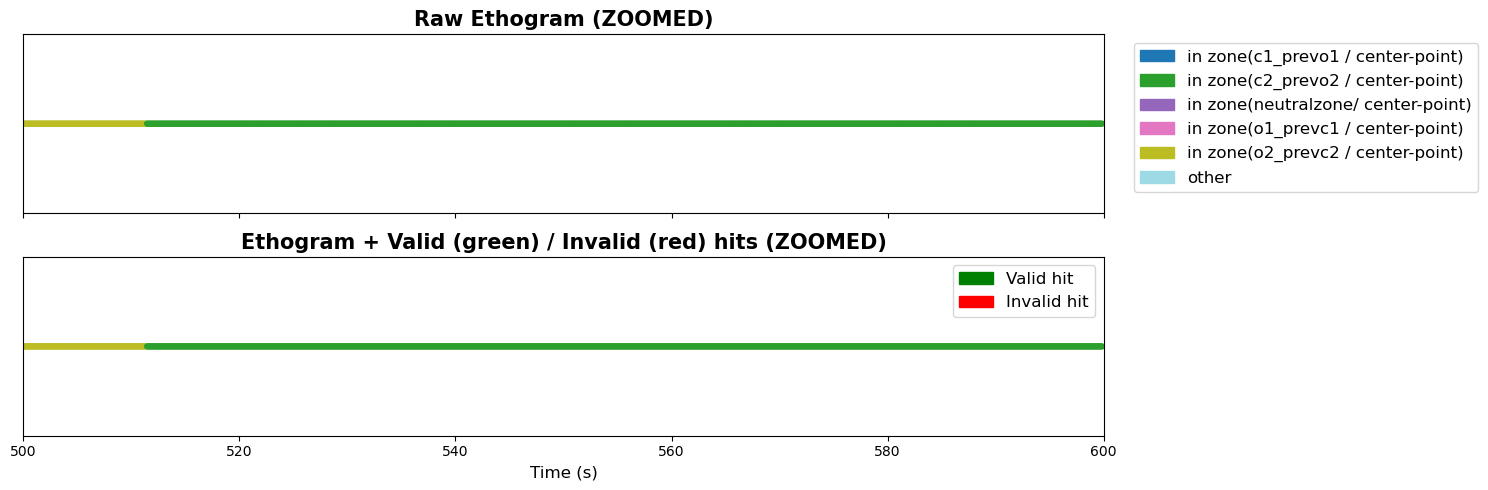

In [65]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ==========================================================
# NORMALIZATION (MATCHES PERI-EVENT STYLE)
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"

 
# ==========================================================
# PRECEDING LOGIC (UPDATED: SKIP neutral + other like peri-event fix)
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(map(norm, prev_behaviors))

    i = idx - 1

    # walk backwards until we find meaningful behavior
    while i >= 0:
        b = behaviors[i]
        nb = norm(b)

        # SKIP non-informative states (KEY FIX)
        if is_neutral(nb) or is_other(nb):
            i -= 1
            continue

        # first meaningful behavior decides validity
        return nb in prev_set

    return False


# ==========================================================
# PICK ONE TRIAL
# ==========================================================
trial_key = list(combined_trials.keys())[0]
trial_data = combined_trials[trial_key]

behaviors = np.array(trial_data["Behavior"].values)
time_vec = np.array(trial_data["Time_video"].values)


# ==========================================================
# NORMALISE BEHAVIOURS
# ==========================================================
behaviors = np.array([norm(b) for b in behaviors])


# ==========================================================
# DEFINE BEHAVIOURS
# ==========================================================
main_behaviors = [
    'In Zone(o1_prevc1 / center-point)',
    'In Zone(o2_prevc2 / center-point)',
    'In Zone(o1_round / center-point)',
    'In Zone(o2_round / center-point)'
]

prev_behaviors = [
    'In Zone(c1_prevo1 / center-point)',
    'In Zone(c2_prevo2 / center-point)'
]

# main_behaviors = [
#         'In Zone(c1_prevo1 / center-point)',
#     'In Zone(c2_prevo2 / center-point)'
# ]


# prev_behaviors = [
#     'In Zone(o1_prevc1 / center-point)',
#     'In Zone(o2_prevc2 / center-point)',
#     'In Zone(o1_round / center-point)',
#     'In Zone(o2_round / center-point)'
# ]

main_behaviors = set(map(norm, main_behaviors))
prev_behaviors = list(map(norm, prev_behaviors))


# ==========================================================
# BOUT DETECTION (UNCHANGED STRUCTURE, FIXED LOGIC ONLY)
# ==========================================================
is_main = np.array([b in main_behaviors for b in behaviors]).astype(int)

starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

valid_hits = [
    i for i in starts
    if valid_preceding_behavior(behaviors, i, prev_behaviors)
]

invalid_hits = [i for i in starts if i not in valid_hits]


# ==========================================================
# COLOR MAP
# ==========================================================
unique_behaviors = np.unique(behaviors)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_behaviors)))
color_map = dict(zip(unique_behaviors, colors))
color_array = [color_map[b] for b in behaviors]


# ==========================================================
# ZOOM WINDOW
# ==========================================================
t_start = 500
t_end = 600

mask = (time_vec >= t_start) & (time_vec <= t_end)

time_vec_z = time_vec[mask]
behaviors_z = behaviors[mask]
color_array_z = [color_map[b] for b in behaviors_z]

valid_hits_z = [v for v in valid_hits if t_start <= time_vec[v] <= t_end]
invalid_hits_z = [v for v in invalid_hits if t_start <= time_vec[v] <= t_end]


# ==========================================================
# FIGURE (UNCHANGED VISUAL OUTPUT)
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)


# RAW ETHOGRAM
ax1.scatter(time_vec_z, np.ones_like(time_vec_z),
            c=color_array_z, s=10)
ax1.set_yticks([])
ax1.set_title("Raw Ethogram (ZOOMED)")


# ETHOGRAM + HITS
ax2.scatter(time_vec_z, np.ones_like(time_vec_z),
            c=color_array_z, s=10)

for v in valid_hits_z:
    ax2.axvline(time_vec[v], color="green", lw=2, alpha=0.8)

for v in invalid_hits_z:
    ax2.axvline(time_vec[v], color="red", lw=2, alpha=0.8)

ax2.set_yticks([])
ax2.set_title("Ethogram + Valid (green) / Invalid (red) hits (ZOOMED)")


# LEGENDS
patches = [mpatches.Patch(color=color_map[b], label=b) for b in unique_behaviors]
ax1.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc="upper left")

hit_legend = [
    mpatches.Patch(color="green", label="Valid hit"),
    mpatches.Patch(color="red", label="Invalid hit")
]
ax2.legend(handles=hit_legend, loc="upper right")


ax2.set_xlabel("Time (s)")
ax1.set_xlim(t_start, t_end)

plt.tight_layout()
plt.show()

# longitudinal comparison of the first 2 s after a transition behaviour (open to closed to closed to open) occurs.

In [66]:
# # import re
# # import numpy as np
# # import pandas as pd
# # import seaborn as sns
# # import matplotlib.pyplot as plt


# # # ==========================================================
# # # NORMALIZATION
# # # ==========================================================
# # def norm(s):
# #     return re.sub(r"\s+", " ", str(s)).strip().lower()


# # def is_neutral(s):
# #     return "neutralzone" in norm(s)


# # def is_other(s):
# #     return norm(s) == "other"


# # # ==========================================================
# # # PRECEDING LOGIC (UNCHANGED)
# # # ==========================================================
# # def valid_preceding_behavior(behaviors, idx, prev_behaviors):

# #     if idx <= 0:
# #         return False

# #     prev_set = set(map(norm, prev_behaviors))
# #     i = idx - 1

# #     while i >= 0:
# #         b = behaviors[i]
# #         nb = norm(b)

# #         if is_neutral(nb) or is_other(nb):
# #             i -= 1
# #             continue

# #         return nb in prev_set

# #     return False


# # # ==========================================================
# # # BUILD EVENT TABLE (0–2s PER EVENT)
# # # ==========================================================
# # def build_event_table(main_behaviors, prev_behaviors):

# #     main_set = set(map(norm, main_behaviors))
# #     rows = []

# #     for trial_key, trial_data in combined_trials.items():

# #         fp_info = fp_traces[trial_key]
# #         week = fp_info.get("week", "")
# #         genotype = fp_info.get("genotype", "")
# #         mouse_id = trial_key

# #         df = trial_data.copy()

# #         time_vec = df["Time_video"].values
# #         signal_vec = df["gcamp_dF_F"].values
# #         behaviors = np.array(df["Behavior"].values)

# #         is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
# #         starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

# #         starts = [
# #             i for i in starts
# #             if valid_preceding_behavior(behaviors, i, prev_behaviors)
# #         ]

# #         if len(starts) == 0:
# #             continue

# #         fps = 1.0 / np.mean(np.diff(time_vec))
# #         post_n = int(2.0 * fps)   # ONLY 0–2s window

# #         for eid, idx in enumerate(starts):

# #             seg = signal_vec[idx: idx + post_n]

# #             if len(seg) < 3:
# #                 continue

# #             base_end = min(len(seg), int(0.5 * fps))
# #             seg = seg - np.mean(seg[:base_end])

# #             rows.append({
# #                 "mouse_id": mouse_id,
# #                 "week": week,
# #                 "genotype": genotype,
# #                 "mean_dFF": np.mean(seg),
# #                 "peak_dFF": np.max(seg)
# #             })

# #     return pd.DataFrame(rows)


# # # ==========================================================
# # # COLLAPSE TO MOUSE × WEEK
# # # ==========================================================
# # def collapse_to_mouse_week(event_df):

# #     return (
# #         event_df
# #         .groupby(["mouse_id", "week", "genotype"])
# #         .agg({
# #             "mean_dFF": "mean",
# #             "peak_dFF": "mean"   # average across events per mouse
# #         })
# #         .reset_index()
# #     )


# # # ==========================================================
# # # PLOT (MOUSE-LEVEL DATA)
# # # ==========================================================
# # def plot_mouse_level(df, plot_title="Mouse-level 0–2s response",
# #                      weeks_to_plot=None, genotype_include=None):

# #     #week_order = ["Preinduction", "W1", "W2", "W3"]
# #     week_order = ["Preinduction", "W1", "W2"]

# #     df["week"] = df["week"].apply(lambda w: w.capitalize() if isinstance(w, str) else None)
# #     df = df[df["week"].notna()]
# #     df["week"] = pd.Categorical(df["week"], categories=week_order, ordered=True)

# #     # filters
# #     if weeks_to_plot is not None:
# #         weeks_to_plot = set(map(str, weeks_to_plot))
# #         df = df[df["week"].astype(str).isin(weeks_to_plot)]

# #     if genotype_include is not None:
# #         allowed = set(g.lower() for g in genotype_include)
# #         df = df[df["genotype"].str.lower().isin(allowed)]

# #     if df.empty:
# #         print("[WARN] No data after filtering")
# #         return

# #     # ======================================================
# #     for metric in ["mean_dFF", "peak_dFF"]:

# #         g = sns.FacetGrid(df, col="genotype", height=5, aspect=1.2, sharey=True)

# #         sns.barplot(
# #             data=df,
# #             x="week",
# #             y=metric,
# #             order=week_order,
# #             errorbar="se",
# #             palette="Set2",
# #             ax=g.ax if hasattr(g, "ax") else None
# #         )

# #         # rebuild properly per facet
# #         g.map_dataframe(
# #             sns.barplot,
# #             x="week",
# #             y=metric,
# #             order=week_order,
# #             palette="Set2",
# #             errorbar="se"
# #         )

# #         g.map_dataframe(
# #             sns.stripplot,
# #             x="week",
# #             y=metric,
# #             color="black",
# #             size=6,
# #             jitter=False
# #         )

# #         def add_lines(data, **kwargs):
# #             for m in data["mouse_id"].unique():
# #                 d = data[data["mouse_id"] == m].sort_values("week")
# #                 x = [week_order.index(w) for w in d["week"]]
# #                 y = d[metric].values
# #                 plt.plot(x, y, color="black", alpha=0.4, linewidth=1)

# #         g.map_dataframe(add_lines)

# #         g.set_axis_labels("Week", metric)
# #         g.set_titles("{col_name}")

# #         for ax in g.axes.flatten():
# #             ax.set_xticks(range(len(week_order)))
# #             ax.set_xticklabels(week_order)
# #             ax.grid(axis="y", alpha=0.3)

# #         g.fig.suptitle(f"{plot_title} — {metric}", y=1.05)
# #         plt.tight_layout()
# #         plt.show()


# # # ==========================================================
# # # RUN
# # # ==========================================================

# # event_df = build_event_table(
# #     main_behaviors=[
# #         "In Zone(c1_prevo1 / center-point)",
# #         "In Zone(c2_prevo2 / center-point)"
# #     ],
# #     prev_behaviors=[
# #         "In Zone(o1_prevc1 / center-point)",
# #         "In Zone(o2_prevc2 / center-point)",
# #         "In Zone(o1_round / center-point)",
# #         "In Zone(o2_round / center-point)"
# #     ]
# # )

# # mouse_df = collapse_to_mouse_week(event_df)

# # plot_mouse_level(
# #     mouse_df,
# #     weeks_to_plot=["Preinduction", "W1","W2"],
# #     genotype_include=["NE"],
# #     plot_title="Mouse-averaged 0–2s transition response open to closed"
# # )

# import re
# import numpy as np
# import matplotlib.pyplot as plt


# # ==========================================================
# # NORMALIZATION
# # ==========================================================
# def norm(s):
#     return re.sub(r"\s+", " ", str(s)).strip().lower()


# def is_neutral(s):
#     return "neutralzone" in norm(s)


# def is_other(s):
#     return norm(s) == "other"


# # ==========================================================
# # PRECEDING BEHAVIOR LOGIC
# # ==========================================================
# def valid_preceding_behavior(behaviors, idx, prev_behaviors):

#     if idx <= 0:
#         return False

#     prev_set = set(map(norm, prev_behaviors))
#     i = idx - 1

#     while i >= 0:
#         b = behaviors[i]
#         nb = norm(b)

#         if is_neutral(nb) or is_other(nb):
#             i -= 1
#             continue

#         return nb in prev_set

#     return False


# # ==========================================================
# # CORE EXTRACTION (PERI-EVENT, SAME AS YOUR TRACE CODE)
# # ==========================================================
# def extract_mouse_level_means(main_behaviors, prev_behaviors):

#     main_set = set(map(norm, main_behaviors))

#     week_order = ["Preinduction", "W1", "W2"]

#     results = {}

#     for trial_key, trial_data in combined_trials.items():

#         fp_info = fp_traces[trial_key]
#         week = fp_info.get("week", "")
#         genotype = fp_info.get("genotype", "")
#         mouse_id = trial_key

#         if week is None or genotype is None:
#             continue

#         df = trial_data.copy()

#         time_vec = df["Time_video"].values
#         signal_vec = df["gcamp_dF_F"].values
#         behaviors = np.array(df["Behavior"].values)

#         # smooth FPS
#         fps = 1.0 / np.mean(np.diff(time_vec))
#         pre_n = int(2.0 * fps)
#         post_n = int(2.0 * fps)

#         is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
#         starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

#         starts = [
#             i for i in starts
#             if valid_preceding_behavior(behaviors, i, prev_behaviors)
#         ]

#         if len(starts) == 0:
#             continue

#         event_means = []

#         for idx in starts:

#             start = idx - pre_n
#             stop = idx + post_n

#             seg = signal_vec[max(0, start):min(len(signal_vec), stop)].copy()

#             if len(seg) < 5:
#                 continue

#             # ==================================================
#             # SAME BASELINE LOGIC AS YOUR PERI-EVENT PLOTS
#             # ==================================================
#             base_end = min(len(seg), pre_n)
#             seg = seg - np.mean(seg[:base_end])

#             post_seg = seg[pre_n:]  # ONLY POST-EVENT WINDOW

#             if len(post_seg) == 0:
#                 continue

#             event_means.append(np.mean(post_seg))

#         if len(event_means) == 0:
#             continue

#         mouse_mean = np.mean(event_means)

#         key = (mouse_id, week, genotype)

#         if key not in results:
#             results[key] = []

#         results[key].append(mouse_mean)

#     # collapse per mouse-week-genotype
#     collapsed = {}

#     for (mouse, week, genotype), vals in results.items():
#         collapsed[(mouse, week, genotype)] = np.mean(vals)

#     return collapsed


# # ==========================================================
# # PLOT BAR PLOT (NO DATAFRAME)
# # ==========================================================
# def plot_peri_event_bars(collapsed_dict,
#                          plot_title="Peri-event ΔF/F (0–2s post, baseline corrected)"):

#     week_order = ["Preinduction", "W1", "W2"]

#     genotypes = sorted(set(k[2] for k in collapsed_dict.keys()))

#     fig, axes = plt.subplots(1, len(genotypes),
#                              figsize=(6 * len(genotypes), 5),
#                              sharey=True)

#     if len(genotypes) == 1:
#         axes = [axes]

#     for ax, genotype in zip(axes, genotypes):

#         x_positions = np.arange(len(week_order))

#         means = []
#         sems = []

#         for week in week_order:

#             vals = [
#                 v for (m, w, g), v in collapsed_dict.items()
#                 if w == week and g == genotype
#             ]

#             if len(vals) == 0:
#                 means.append(np.nan)
#                 sems.append(np.nan)
#             else:
#                 means.append(np.mean(vals))
#                 sems.append(np.std(vals) / np.sqrt(len(vals)))

#         ax.bar(x_positions, means, yerr=sems, capsize=5, alpha=0.8)

#         # scatter individual mice
#         for i, week in enumerate(week_order):
#             vals = [
#                 v for (m, w, g), v in collapsed_dict.items()
#                 if w == week and g == genotype
#             ]
#             ax.scatter(
#                 np.repeat(i, len(vals)),
#                 vals,
#                 color="black",
#                 zorder=3
#             )

#         ax.set_title(genotype)
#         ax.set_xticks(x_positions)
#         ax.set_xticklabels(week_order)
#         ax.set_ylabel("ΔF/F (post-event baseline corrected)")
#         ax.grid(axis="y", alpha=0.3)

#     plt.suptitle(plot_title)
#     plt.tight_layout()
#     plt.show()


# # ==========================================================
# # RUN
# # ==========================================================

# collapsed = extract_mouse_level_means(
#     main_behaviors=[
#         "In Zone(c1_prevo1 / center-point)",
#         "In Zone(c2_prevo2 / center-point)"
#     ],
#     prev_behaviors=[
#         "In Zone(o1_prevc1 / center-point)",
#         "In Zone(o2_prevc2 / center-point)",
#         "In Zone(o1_round / center-point)",
#         "In Zone(o2_round / center-point)"
#     ]
# )

# plot_peri_event_bars(collapsed)

# Data export for bar plots - using post-event mean dff values that are NOT baseline subtracted
Does not make sense to do O_round since there are not many values in W1 or 2

In [67]:
# Export data for R processing - 2 s post behaviour
import re
import os
import numpy as np
import pandas as pd

# ==========================================================
# NORMALIZATION HELPERS
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"


# ==========================================================
# PRECEDING BEHAVIOR LOGIC
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(map(norm, prev_behaviors))
    i = idx - 1

    while i >= 0:
        b = behaviors[i]
        nb = norm(b)

        if is_neutral(nb) or is_other(nb):
            i -= 1
            continue

        return nb in prev_set

    return False


# ==========================================================
# EXPORT FUNCTION
# ==========================================================
def export_mouse_week_post2s(
    main_behaviors,
    prev_behaviors,
    post_window_s=2.0,
    weeks_to_include=None,
    genotype_include=None
):

    summary = []

    # ---------- NORMALISE WEEK META ----------
    for trial_key, fp_info in fp_traces.items():
        wk = fp_info.get("week", "")
        if wk:
            fp_info["week"] = wk.capitalize()
        else:
            m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
            fp_info["week"] = m.group(1).capitalize() if m else None

    main_set = set(map(norm, main_behaviors))

    # ==========================================================
    # LOOP TRIALS
    # ==========================================================
    for trial_key, trial_data in combined_trials.items():

        fp_info = fp_traces.get(trial_key, {})

        week = fp_info.get("week")
        genotype = fp_info.get("genotype")
        mouse_id = fp_info.get("mouse_id", trial_key)
        condition = fp_info.get("condition")

        if week is None or genotype is None:
            continue

        # filters
        if weeks_to_include and week not in weeks_to_include:
            continue

        if genotype_include and genotype not in genotype_include:
            continue

        if "gcamp_dF_F" not in trial_data.columns:
            continue

        df = trial_data.copy()
        signal = df["gcamp_dF_F"].values
        behaviors = np.array(df["Behavior"].values)

        # --------------------------------------------------
        # EVENT ONSET DETECTION
        # --------------------------------------------------
        is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
        starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

        starts = [
            i for i in starts
            if valid_preceding_behavior(behaviors, i, prev_behaviors)
        ]

        if len(starts) == 0:
            continue

        # --------------------------------------------------
        # FPS ESTIMATE
        # --------------------------------------------------
        time_vec = df["Time_video"].values
        fps = 1.0 / np.median(np.diff(time_vec))
        post_n = int(post_window_s * fps)

        post_means = []

        # --------------------------------------------------
        # 0–2s POST-ONSET WINDOW
        # --------------------------------------------------
        for idx in starts:

            start = idx
            stop = idx + post_n

            if start < 0 or stop >= len(signal):
                continue

            seg = signal[start:stop]
            if len(seg) == 0:
                continue

            post_means.append(np.nanmean(seg))

        if len(post_means) == 0:
            continue

        summary.append({
            "mouse_id": mouse_id,
            "genotype": genotype,
            "condition": condition,
            "week": week,
            "mean_dFF": np.nanmean(post_means),
            "n_events": len(post_means)
        })

    df_out = pd.DataFrame(summary)

    print("Shape:", df_out.shape)
    print(df_out.head())

    return df_out


# ==========================================================
# RUN + EXPORT TO R
# ==========================================================

post2s_df = export_mouse_week_post2s(
    main_behaviors=[
        'In Zone(c1_prevo1 / center-point)',
        'In Zone(c2_prevo2 / center-point)'
    ],
    prev_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],
    post_window_s=2.0,
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"]
)

# ==========================================================
# SAVE FOR R
# ==========================================================
out_dir = "R_processing"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "post2s_open_to_closed.csv")

post2s_df.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")

# ==========================================================
# RUN + EXPORT TO R
# ==========================================================

post2s_df = export_mouse_week_post2s(
    main_behaviors= 
    [
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point',
        'In Zone(o2_round / center-point)'
    ],
    prev_behaviors=[
        'In Zone(c1_prevo1 / center-point)',
        'In Zone(c2_prevo2 / center-point)'
    ],
    post_window_s=2.0,
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"]
)

# ==========================================================
# SAVE FOR R
# ==========================================================
out_dir = "R_processing"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "post2s_closed_to_open.csv")

post2s_df.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")

Shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Saved to: R_processing/post2s_open_to_closed.csv
Shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Saved to: R_processing/post2s_closed_to_open.csv


# Data export for bar plots, WITH baseline subtraction of post event values using pre-event -2 to 0 s period up to event
Does not make sense to do O_round since there are not many values in W1 or 2

In [68]:
# Export data for R processing - 2 s post behaviour
import re
import os
import numpy as np
import pandas as pd

# ==========================================================
# NORMALIZATION HELPERS
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"


# ==========================================================
# PRECEDING BEHAVIOR LOGIC
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(map(norm, prev_behaviors))
    i = idx - 1

    while i >= 0:
        b = behaviors[i]
        nb = norm(b)

        if is_neutral(nb) or is_other(nb):
            i -= 1
            continue

        return nb in prev_set

    return False


# ==========================================================
# EXPORT FUNCTION
# ==========================================================
def export_mouse_week_post2s(
    main_behaviors,
    prev_behaviors,
    post_window_s=2.0,
    weeks_to_include=None,
    genotype_include=None
):

    summary = []

    # ---------- NORMALISE WEEK META ----------
    for trial_key, fp_info in fp_traces.items():
        wk = fp_info.get("week", "")
        if wk:
            fp_info["week"] = wk.capitalize()
        else:
            m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
            fp_info["week"] = m.group(1).capitalize() if m else None

    main_set = set(map(norm, main_behaviors))

    # ==========================================================
    # LOOP TRIALS
    # ==========================================================
    for trial_key, trial_data in combined_trials.items():

        fp_info = fp_traces.get(trial_key, {})

        week = fp_info.get("week")
        genotype = fp_info.get("genotype")
        mouse_id = fp_info.get("mouse_id", trial_key)
        condition = fp_info.get("condition")

        if week is None or genotype is None:
            continue

        # filters
        if weeks_to_include and week not in weeks_to_include:
            continue

        if genotype_include and genotype not in genotype_include:
            continue

        if "gcamp_dF_F" not in trial_data.columns:
            continue

        df = trial_data.copy()
        signal = df["gcamp_dF_F"].values
        behaviors = np.array(df["Behavior"].values)

        # --------------------------------------------------
        # EVENT ONSET DETECTION
        # --------------------------------------------------
        is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
        starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

        starts = [
            i for i in starts
            if valid_preceding_behavior(behaviors, i, prev_behaviors)
        ]

        if len(starts) == 0:
            continue

        # --------------------------------------------------
        # FPS ESTIMATE
        # --------------------------------------------------
        time_vec = df["Time_video"].values
        fps = 1.0 / np.median(np.diff(time_vec))
        post_n = int(post_window_s * fps)

        post_means = []

        # --------------------------------------------------
        # 0–2s POST-ONSET WINDOW
        # --------------------------------------------------
        # for idx in starts:

        #     start = idx
        #     stop = idx + post_n

        #     if start < 0 or stop >= len(signal):
        #         continue

        #     seg = signal[start:stop]
        #     if len(seg) == 0:
        #         continue

        #     post_means.append(np.nanmean(seg))


        # --------------------------------------------------
        # -2 to 0 baseline + 0 to +2s response
        # --------------------------------------------------
        pre_n = post_n  # same duration as post window (2s)

        for idx in starts:

            baseline_start = idx - pre_n
            baseline_end = idx

            signal_start = idx
            signal_end = idx + post_n

            # skip edge cases
            if baseline_start < 0 or signal_end >= len(signal):
                continue

            baseline = signal[baseline_start:baseline_end]
            seg = signal[signal_start:signal_end]

            if len(baseline) == 0 or len(seg) == 0:
                continue

            baseline_mean = np.nanmean(baseline)

            seg_corrected = seg - baseline_mean

            post_means.append(np.nanmean(seg_corrected))

        if len(post_means) == 0:
            continue

        summary.append({
            "mouse_id": mouse_id,
            "genotype": genotype,
            "condition": condition,
            "week": week,
            "mean_dFF": np.nanmean(post_means),
            "n_events": len(post_means)
        })

    df_out = pd.DataFrame(summary)

    print("Shape:", df_out.shape)
    print(df_out.head())

    return df_out


# ==========================================================
# RUN + EXPORT TO R
# ==========================================================

post2s_df = export_mouse_week_post2s(
    main_behaviors=[
        'In Zone(c1_prevo1 / center-point)',
        'In Zone(c2_prevo2 / center-point)'
    ],
    prev_behaviors=[
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],
    post_window_s=2.0,
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"]
)

# ==========================================================
# SAVE FOR R
# ==========================================================
out_dir = "R_processing"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "post2s_open_to_closed_BaselineSubtracted.csv")

post2s_df.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")

# ==========================================================
# RUN + EXPORT TO R
# ==========================================================

post2s_df = export_mouse_week_post2s(
    main_behaviors= 
    [
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],
    prev_behaviors=[
        'In Zone(c1_prevo1 / center-point)',
        'In Zone(c2_prevo2 / center-point)'
    ],
    post_window_s=2.0,
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"]
)

# ==========================================================
# SAVE FOR R
# ==========================================================
out_dir = "R_processing"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "post2s_closed_to_open_BaselineSubtracted.csv")

post2s_df.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")

post2s_df = export_mouse_week_post2s(
    main_behaviors= 
[
        'In Zone(c1_prevo1 / center-point)',
        'In Zone(c2_prevo2 / center-point)'
    ],
    prev_behaviors=
        [
        'In Zone(o1_prevc1 / center-point)',
        'In Zone(o2_prevc2 / center-point)',
        'In Zone(o1_round / center-point)',
        'In Zone(o2_round / center-point)'
    ],
    post_window_s=2.0,
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"]
)

# ==========================================================
# SAVE FOR R
# ==========================================================
out_dir = "R_processing"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "post2s_open_to_closed_BaselineSubtracted.csv")

post2s_df.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")

Shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Saved to: R_processing/post2s_open_to_closed_BaselineSubtracted.csv
Shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Saved to: R_processing/post2s_closed_to_open_BaselineSubtracted.csv
Shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Saved to: R_processing/post2s_open_to_closed_BaselineSubtracted.csv


In [69]:
# import os
# import re
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import ttest_1samp
# from statsmodels.stats.multitest import multipletests


# # ==========================================================
# # HELPERS (same as peri-event code)
# # ==========================================================
# def norm(s):
#     return re.sub(r"\s+", " ", str(s)).strip().lower()

# def is_neutral(s):
#     return "neutralzone" in norm(s)

# def is_other(s):
#     return norm(s) == "other"

# def valid_preceding_behavior(behaviors, idx, prev_behaviors):
#     if idx <= 0:
#         return False

#     prev_set = set(map(norm, prev_behaviors))
#     i = idx - 1

#     while i >= 0:
#         b = behaviors[i]
#         nb = norm(b)

#         if is_neutral(nb) or is_other(nb):
#             i -= 1
#             continue

#         return nb in prev_set

#     return False


# # ==========================================================
# # MAIN FUNCTION
# # ==========================================================
# def plot_epm_prepost(
#     main_behaviors,
#     prev_behaviors,
#     weeks_to_include=None,
#     genotype_include=None,
#     pre_s=2.0,
#     post_s=2.0,
#     value_name="mean_dFF",
#     save_prefix="epm_prepost"
# ):

#     results = []
#     main_set = set(map(norm, main_behaviors))

#     # ----------------------------------------------------------
#     # LOOP TRIALS
#     # ----------------------------------------------------------
#     for trial_key, trial_data in combined_trials.items():

#         fp_info = fp_traces.get(trial_key, {})
#         week = fp_info.get("week")
#         genotype = fp_info.get("genotype")
#         mouse_id = fp_info.get("mouse_id", trial_key)
#         condition = fp_info.get("condition")

#         if week is None or genotype is None:
#             continue

#         if weeks_to_include and week not in weeks_to_include:
#             continue

#         if genotype_include and genotype not in genotype_include:
#             continue

#         df = trial_data.copy()

#         signal = df["gcamp_dF_F"].values
#         behaviors = np.array(df["Behavior"].values)
#         time_vec = df["Time_video"].values

#         fps = 1.0 / np.median(np.diff(time_vec))
#         pre_n = int(pre_s * fps)
#         post_n = int(post_s * fps)

#         # ----------------------------------------------------------
#         # FIND EVENTS (prev → main)
#         # ----------------------------------------------------------
#         is_main = np.array([norm(b) in main_set for b in behaviors]).astype(int)
#         starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

#         starts = [
#             i for i in starts
#             if valid_preceding_behavior(behaviors, i, prev_behaviors)
#         ]

#         if len(starts) == 0:
#             continue

#         pre_vals = []
#         post_vals = []

#         # ----------------------------------------------------------
#         # EXTRACT WINDOWS
#         # ----------------------------------------------------------
#         for idx in starts:

#             start = idx - pre_n
#             stop = idx + post_n

#             if start < 0 or stop >= len(signal):
#                 continue

#             window = signal[start:stop]

#             if len(window) != (pre_n + post_n):
#                 continue

#             pre_vals.append(np.nanmean(window[:pre_n]))
#             post_vals.append(np.nanmean(window[pre_n:]))

#         if len(pre_vals) == 0:
#             continue

#         results.append({
#             "mouse_id": mouse_id,
#             "genotype": genotype,
#             "week": week,
#             "condition": condition,
#             "pre": np.nanmean(pre_vals),
#             "post": np.nanmean(post_vals),
#             "n_events": len(pre_vals)
#         })

#     df_out = pd.DataFrame(results)

#     if df_out.empty:
#         print("[WARN] No data produced")
#         return df_out

#     # ==========================================================
#     # PLOT
#     # ==========================================================
#     os.makedirs("pre post comparison", exist_ok=True)

#     week_order = ["Preinduction", "W1", "W2"]
#     df_out["week"] = pd.Categorical(df_out["week"], categories=week_order, ordered=True)

#     for genotype in df_out["genotype"].unique():

#         sub = df_out[df_out["genotype"] == genotype]

#         # --------------------------
#         # STATS (paired per mouse per week)
#         # --------------------------
#         stats_results = []

#         for week, grp in sub.groupby("week"):

#             if len(grp) < 2:
#                 continue

#             diff = grp["post"] - grp["pre"]
#             diff = diff.dropna()

#             if len(diff) < 2:
#                 continue

#             stat, p = ttest_1samp(diff, 0)

#             stats_results.append({
#                 "week": week,
#                 "p_value": p
#             })

#         stats_df = pd.DataFrame(stats_results)

#         if not stats_df.empty:
#             stats_df["p_corrected"] = multipletests(
#                 stats_df["p_value"],
#                 method="bonferroni"
#             )[1]

#         # --------------------------
#         # PRINT P-VALUES
#         # --------------------------
#         print(f"\n--- Stats: {genotype} ({save_prefix}) ---")
#         if stats_df.empty:
#             print("  No weeks with sufficient data for stats.")
#         else:
#             for _, row in stats_df.iterrows():
#                 p_raw = row["p_value"]
#                 p_corr = row["p_corrected"]
#                 sig = (
#                     "***" if p_corr < 0.001 else
#                     "**"  if p_corr < 0.01  else
#                     "*"   if p_corr < 0.05  else
#                     "ns"
#                 )
#                 print(
#                     f"  Week {str(row['week']):>12s} | "
#                     f"p (raw) = {p_raw:.4f} | "
#                     f"p (Bonferroni) = {p_corr:.4f}  {sig}"
#                 )

#         # --------------------------
#         # LONG FORMAT
#         # --------------------------
#         long_df = sub.melt(
#             id_vars=["mouse_id", "genotype", "week"],
#             value_vars=["pre", "post"],
#             var_name="window",
#             value_name=value_name
#         )

#         long_df["window"] = long_df["window"].map({
#             "pre": "Pre (-2 to 0s)",
#             "post": "Post (0 to 2s)"
#         })

#         # --------------------------
#         # PLOT (same style as your 3CT)
#         # --------------------------
#         g = sns.FacetGrid(long_df, col="genotype", height=5, aspect=1.1, sharey=True)

#         g.map_dataframe(
#             sns.barplot,
#             x="week",
#             y=value_name,
#             hue="window",
#             palette="Set2",
#             errorbar="se",
#             capsize=0.1
#         )

#         g.map_dataframe(
#             sns.stripplot,
#             x="week",
#             y=value_name,
#             hue="window",
#             dodge=True,
#             size=6,
#             alpha=0.7
#         )

#         if g._legend:
#             g._legend.remove()

#         g.add_legend(title="Window")
#         g._legend.set_bbox_to_anchor((1.02, 0.85))
#         g._legend._loc = 2

#         g.fig.suptitle(f"EPM Pre/Post ({genotype})", y=1.03)

#         # --------------------------
#         # SAVE SVG
#         # --------------------------
#         save_name = f"{save_prefix}_{genotype}"
#         save_name = re.sub(r"[^\w\-]+", "_", save_name)

#         save_path = os.path.join("pre post comparison", save_name + ".svg")

#         plt.tight_layout()
#         plt.savefig(save_path, format="svg", bbox_inches="tight")
#         plt.show()

#         print(f"Saved: {save_path}")

#     return df_out

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests


# ==========================================================
# GLOBAL CLEANER (IMPORTANT FIX)
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in s


def is_other(s):
    return s == "other"


# ==========================================================
# PRECEDING BEHAVIOR LOGIC (FIXED)
# ==========================================================
def valid_preceding_behavior(behaviors, idx, prev_behaviors):

    if idx <= 0:
        return False

    prev_set = set(norm(b) for b in prev_behaviors)

    i = idx - 1
    while i >= 0:

        b = behaviors[i]

        if is_neutral(b) or is_other(b):
            i -= 1
            continue

        return b in prev_set

    return False


# ==========================================================
# MAIN FUNCTION
# ==========================================================
def plot_epm_prepost(
    main_behaviors,
    prev_behaviors,
    weeks_to_include=None,
    genotype_include=None,
    pre_s=2.0,
    post_s=2.0,
    value_name="mean_dFF",
    save_prefix="epm_prepost"
):

    results = []

    # NORMALIZE ONCE HERE
    main_set = set(norm(b) for b in main_behaviors)
    prev_list = [norm(b) for b in prev_behaviors]

    # ----------------------------------------------------------
    # LOOP TRIALS
    # ----------------------------------------------------------
    for trial_key, trial_data in combined_trials.items():

        fp_info = fp_traces.get(trial_key, {})
        week = fp_info.get("week")
        genotype = fp_info.get("genotype")
        mouse_id = fp_info.get("mouse_id", trial_key)
        condition = fp_info.get("condition")

        if week is None or genotype is None:
            continue

        if weeks_to_include and week not in weeks_to_include:
            continue

        if genotype_include and genotype not in genotype_include:
            continue

        if "gcamp_dF_F" not in trial_data.columns:
            continue

        df = trial_data.copy()

        # 🔥 NORMALIZE BEHAVIOR COLUMN ONCE
        signal = df["gcamp_dF_F"].values
        behaviors = np.array([norm(b) for b in df["Behavior"].values])
        time_vec = df["Time_video"].values

        fps = 1.0 / np.median(np.diff(time_vec))
        pre_n = int(pre_s * fps)
        post_n = int(post_s * fps)

        # ----------------------------------------------------------
        # FIND EVENTS
        # ----------------------------------------------------------
        is_main = np.array([b in main_set for b in behaviors]).astype(int)

        starts = np.where(np.diff(np.r_[0, is_main]) == 1)[0]

        starts = [
            i for i in starts
            if valid_preceding_behavior(behaviors, i, prev_list)
        ]

        if len(starts) == 0:
            continue

        pre_vals = []
        post_vals = []

        # ----------------------------------------------------------
        # EXTRACT WINDOWS
        # ----------------------------------------------------------
        for idx in starts:

            start = idx - pre_n
            stop = idx + post_n

            if start < 0 or stop >= len(signal):
                continue

            window = signal[start:stop]

            if len(window) != (pre_n + post_n):
                continue

            pre_vals.append(np.nanmean(window[:pre_n]))
            post_vals.append(np.nanmean(window[pre_n:]))

        if len(pre_vals) == 0:
            continue

        results.append({
            "mouse_id": mouse_id,
            "genotype": genotype,
            "week": week,
            "condition": condition,
            "pre": np.nanmean(pre_vals),
            "post": np.nanmean(post_vals),
            "n_events": len(pre_vals)
        })

    df_out = pd.DataFrame(results)

    if df_out.empty:
        print("[WARN] No data produced")
        return df_out

    # ==========================================================
    # PLOT
    # ==========================================================
    os.makedirs("pre post comparison", exist_ok=True)

    week_order = ["Preinduction", "W1", "W2"]
    df_out["week"] = pd.Categorical(df_out["week"], categories=week_order, ordered=True)

    for genotype in df_out["genotype"].unique():

        sub = df_out[df_out["genotype"] == genotype]

        stats_results = []

        for week, grp in sub.groupby("week"):

            if len(grp) < 2:
                continue

            diff = (grp["post"] - grp["pre"]).dropna()

            if len(diff) < 2:
                continue

            _, p = ttest_1samp(diff, 0)

            stats_results.append({"week": week, "p_value": p})

        stats_df = pd.DataFrame(stats_results)

        if not stats_df.empty:
            stats_df["p_corrected"] = multipletests(
                stats_df["p_value"],
                method="bonferroni"
            )[1]

        print(f"\n--- Stats: {genotype} ({save_prefix}) ---")
        if stats_df.empty:
            print("  No stats")
        else:
            for _, row in stats_df.iterrows():
                print(
                    f"Week {row['week']} | p={row['p_value']:.4f} | "
                    f"p_corr={row['p_corrected']:.4f}"
                )

        # LONG FORMAT
        long_df = sub.melt(
            id_vars=["mouse_id", "genotype", "week"],
            value_vars=["pre", "post"],
            var_name="window",
            value_name=value_name
        )

        long_df["window"] = long_df["window"].map({
            "pre": "Pre (-2 to 0s)",
            "post": "Post (0 to 2s)"
        })

        # PLOT
        g = sns.FacetGrid(long_df, col="genotype", height=5, aspect=1.1)

        g.map_dataframe(
            sns.barplot,
            x="week",
            y=value_name,
            hue="window",
            palette="Set2",
            errorbar="se"
        )

        g.map_dataframe(
            sns.stripplot,
            x="week",
            y=value_name,
            hue="window",
            dodge=True,
            alpha=0.7
        )

        if g._legend:
            g._legend.remove()

        g.add_legend(title="Window")
        g._legend.set_bbox_to_anchor((1.02, 0.85))
        g._legend._loc = 2

        g.fig.suptitle(f"EPM Pre/Post ({genotype})", y=1.03)

        save_path = os.path.join(
            "pre post comparison",
            re.sub(r"[^\w\-]+", "_", save_prefix + "_" + genotype) + ".svg"
        )

        plt.tight_layout()
        plt.savefig(save_path, format="svg", bbox_inches="tight")
        plt.show()

        print("Saved:", save_path)

    return df_out

epm_df = plot_epm_prepost(
    main_behaviors=[
        "In Zone(c1_prevo1 / center-point)",
        "In Zone(c2_prevo2 / center-point)"
    ],
    prev_behaviors=[
        "In Zone(o1_prevc1 / center-point)",
        "In Zone(o2_prevc2 / center-point)",
        "In Zone(o1_round / center-point)",
        "In Zone(o2_round / center-point)"
    ],
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"],
    save_prefix="EPM_open_to_closed_prepost"
)

epm_df = plot_epm_prepost(
    main_behaviors=[
        "In Zone(o1_prevc1 / center-point)",
        "In Zone(o2_prevc2 / center-point)",
        "In Zone(o1_round / center-point)",
        "In Zone(o2_round / center-point)"
    ],
    prev_behaviors=[
        "In Zone(c1_prevo1 / center-point)",
        "In Zone(c2_prevo2 / center-point)"
    ],
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"],
    save_prefix="EPM_closed_to_open_prepost"
)

[WARN] No data produced
[WARN] No data produced


# Using Open_round zones as a proxy for head dips, no matter what behaviour preceded it 

In [70]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# NORMALIZATION HELPERS
# ==========================================================
def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()


def is_neutral(s):
    return "neutralzone" in norm(s)


def is_other(s):
    return norm(s) == "other"


# ==========================================================
# MAIN FUNCTION (OPEN_ROUND ONLY)
# ==========================================================
def funfunfunction(
    event_behaviors,
    plot_title="open_round_peri_event",
    weeks_to_plot=None,
    genotype_include=None   # optional WT filtering
):

    print("\n========== RUN DEBUG ==========")
    print("event_behaviors:", event_behaviors)
    print("weeks_to_plot:", weeks_to_plot)
    print("genotype_include:", genotype_include)
    print("n trials:", len(combined_trials))

    # ---------- PARAMETERS ----------
    pre_s = 2.0
    post_s = 4.0

    # ---------- NORMALIZE FP_TRACES AND BEHAVIORS ----------
    for trial_key, fp_info in fp_traces.items():
        wk = fp_info.get("week", "")
        if wk:
            fp_info["week"] = wk.capitalize()
        else:
            m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
            fp_info["week"] = m.group(1).capitalize() if m else None

    for trial_key, trial_data in combined_trials.items():
        normalized = []
        for b in trial_data["Behavior"].values:
            if isinstance(b, str) and b.lower() == "other":
                normalized.append("Other")
            else:
                normalized.append(re.sub(r"Zone\s*\d*", "Zone", str(b), flags=re.IGNORECASE))
        trial_data["Behavior"] = np.array(normalized)

    # ---------- COLLECT METADATA ----------
    all_weeks = set()
    all_genotypes = set()

    for trial_key, trial_data in combined_trials.items():
        fp_info = fp_traces[trial_key]

        wk = fp_info.get("week")
        if wk:
            all_weeks.add(wk)

        g = fp_info.get("genotype")
        if g:
            all_genotypes.add(g)

    week_order = ["Preinduction", "W1", "W2", "W3"]
    all_weeks = sorted(all_weeks, key=lambda w: week_order.index(w))
    all_genotypes = sorted(all_genotypes)

    # ---------- FILTER WEEKS ----------
    if weeks_to_plot is not None:
        weeks_to_plot = set(map(str, weeks_to_plot))
        all_weeks = [w for w in all_weeks if w in weeks_to_plot]

    # ---------- FILTER GENOTYPES (WT OPTION) ----------
    if genotype_include is not None:
        allowed = set(g.lower() for g in genotype_include)
        all_genotypes = [g for g in all_genotypes if g.lower() in allowed]

    print(f"Weeks used: {all_weeks}")
    print(f"Genotypes used: {all_genotypes}")

    # ==========================================================
    # FIGURE
    # ==========================================================
    fig, axes = plt.subplots(
        len(all_weeks),
        len(all_genotypes),
        figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
        sharey=True,
        sharex=True
    )

    if len(all_weeks) == 1:
        axes = [axes]
    if len(all_genotypes) == 1:
        axes = [[axes[r]] for r in range(len(axes))]

    main_set = set(map(norm, event_behaviors))

    # ==========================================================
    # MAIN LOOP
    # ==========================================================
    for r, week in enumerate(all_weeks):
        for c, genotype in enumerate(all_genotypes):

            ax = axes[r][c]

            mouse_segments = []
            mouse_lengths = []

            for trial_key, trial_data in combined_trials.items():
                fp_info = fp_traces[trial_key]

                if fp_info.get("week") != week:
                    continue
                if fp_info.get("genotype") != genotype:
                    continue

                df = trial_data.copy()
                time_vec = df["Time_video"].values
                signal_vec = df["gcamp_dF_F"].values
                behaviors = np.array(df["Behavior"].values)

                # --------------------------------------------------
                # OPEN ROUND EVENT DETECTION ONLY
                # --------------------------------------------------
                is_event = np.array([norm(b) in main_set for b in behaviors]).astype(int)
                starts = np.where(np.diff(np.r_[0, is_event]) == 1)[0]

                if len(starts) == 0:
                    continue

                fps = 1.0 / np.mean(np.diff(time_vec))
                pre_n = int(pre_s * fps)
                post_n = int(post_s * fps)

                event_segments = []

                for idx in starts:
                    start_idx = idx - pre_n
                    stop_idx = idx + post_n

                    seg = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()
                    if len(seg) == 0:
                        continue

                    pre_end = min(pre_n, len(seg))
                    seg -= np.mean(seg[:pre_end])

                    event_segments.append(seg)

                if len(event_segments) == 0:
                    continue

                max_len = max(len(s) for s in event_segments)
                padded = np.full((len(event_segments), max_len), np.nan)

                for i, s in enumerate(event_segments):
                    padded[i, :len(s)] = s

                mouse_segments.append(np.nanmean(padded, axis=0))
                mouse_lengths.append(len(mouse_segments[-1]))

            if len(mouse_segments) == 0:
                ax.set_title(f"{week} | {genotype}\n(no events)")
                ax.grid(True)
                continue

            target_len = max(mouse_lengths)
            padded_mouse = np.full((len(mouse_segments), target_len), np.nan)

            for i, seg in enumerate(mouse_segments):
                padded_mouse[i, :len(seg)] = seg

            t_window = np.linspace(-pre_s, post_s, target_len)

            for i, seg in enumerate(padded_mouse):
                ax.plot(t_window, seg, alpha=0.4, lw=1.5)

            ax.plot(t_window, np.nanmean(padded_mouse, axis=0), color="black", lw=2.5)

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f"{week} | {genotype}")
            ax.grid(True)

            if r == len(all_weeks) - 1:
                ax.set_xlabel("Time (s)")
            if c == 0:
                ax.set_ylabel("ΔF/F (%)")

    # ==========================================================
    # SAVE
    # ==========================================================
    plt.suptitle(plot_title, fontsize=18)
    plt.tight_layout()

    save_dir = "transition trace plots"
    os.makedirs(save_dir, exist_ok=True)

    safe_title = re.sub(r"[^\w\-]+", "_", plot_title.strip())
    save_path = os.path.join(save_dir, safe_title + ".svg")

    plt.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"\nSaved figure to: {save_path}")

    plt.show()


# ==========================================================
# RUN EXAMPLE
# ==========================================================
open_round_behaviors = [
    "In Zone(o1_round / center-point)",
    "In Zone(o2_round / center-point)"
]

funfunfunction(
    event_behaviors=open_round_behaviors,
    weeks_to_plot=["Preinduction", "W2"],
    genotype_include=["NE"],   # <- optional WT filter
    plot_title="Open Round peri-event traces (Pre + W2)"
)


========== RUN DEBUG ==========
event_behaviors: ['In Zone(o1_round / center-point)', 'In Zone(o2_round / center-point)']
weeks_to_plot: ['Preinduction', 'W2']
genotype_include: ['NE']
n trials: 1
Weeks used: ['Preinduction']
Genotypes used: []


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x400 with 0 Axes>

# Code using all individual zone types, not collapsed into open and closed

In [71]:
# import re
# import numpy as np
# import matplotlib.pyplot as plt

# # ---------- PARAMETERS ----------
# pre_s = 2.0
# post_s = 4.0

# # ---------- NORMALIZE FP_TRACES AND BEHAVIORS ----------
# for trial_key, fp_info in fp_traces.items():
#     wk = fp_info.get("week", "")
#     if wk:  # standardize capitalization
#         fp_info["week"] = wk.capitalize()
#     else:
#         m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
#         if m:
#             fp_info["week"] = m.group(1).capitalize()
#         else:
#             fp_info["week"] = None
#             print(f"[WARNING] No week found for trial key: {trial_key}")

# for trial_key, trial_data in combined_trials.items():
#     normalized_behaviors = []
#     for b in trial_data["Behavior"].values:
#         if b.lower() == "other":
#             normalized_behaviors.append("Other")
#         else:
#             # make agnostic to "Zone", "Zone 2", "Zone 3", etc.
#             b_clean = re.sub(r"Zone\s*\d*", "Zone", b, flags=re.IGNORECASE)
#             normalized_behaviors.append(b_clean)
#     trial_data["Behavior"] = normalized_behaviors

# # ---------- COLLECT METADATA ----------
# all_behaviors = set()
# all_weeks = set()
# all_genotypes = set()

# for trial_key, trial_data in combined_trials.items():
#     fp_info = fp_traces[trial_key]

#     behs = np.unique(trial_data["Behavior"].values)
#     all_behaviors.update([b for b in behs if b != "Other"])

#     wk = fp_info.get("week")
#     if wk is not None:
#         all_weeks.add(wk)
#     else:
#         print(f"[WARNING] Week is None for trial {trial_key}")

#     all_genotypes.add(fp_info.get("genotype"))

# # sort metadata logically
# week_order = ["Preinduction", "W1", "W2", "W3"]
# all_weeks = sorted(all_weeks, key=lambda w: week_order.index(w))
# all_genotypes = sorted(all_genotypes)
# all_behaviors = sorted(all_behaviors)

# print(f"Weeks detected: {all_weeks}")
# print(f"Genotypes detected: {all_genotypes}")
# print(f"Behaviors detected: {all_behaviors}")

# # =====================================================
# #      MAIN LOOP: BEHAVIOR × GENOTYPE × WEEK
# # =====================================================
# for beh in all_behaviors:

#     fig, axes = plt.subplots(
#         len(all_weeks),
#         len(all_genotypes),
#         figsize=(6 * len(all_genotypes), 4 * len(all_weeks)),
#         sharey=True,
#         sharex=True
#     )

#     # ensure axes is 2D array
#     if len(all_weeks) == 1:
#         axes = [axes]
#     if len(all_genotypes) == 1:
#         axes = [[axes[r]] for r in range(len(axes))]

#     for r, week in enumerate(all_weeks):
#         for c, genotype in enumerate(all_genotypes):
#             ax = axes[r][c]

#             mouse_segments = []
#             mouse_ids = []
#             mouse_lengths = []

#             # collect data for this week × genotype × behavior
#             for trial_key, trial_data in combined_trials.items():
#                 fp_info = fp_traces[trial_key]

#                 if fp_info.get("week") != week:
#                     continue
#                 if fp_info.get("genotype") != genotype:
#                     continue

#                 df = trial_data.copy()
#                 time_vec = df["Time_video"].values
#                 signal_vec = df["gcamp_dF_F"].values
#                 behaviors = df["Behavior"].values

#                 if beh not in behaviors:
#                     continue

#                 # ---------- EVENT STARTS ----------
#                 starts = np.where(np.diff(np.r_[0, (behaviors == beh).astype(int)]) == 1)[0]
#                 if len(starts) == 0:
#                     continue

#                 fps = 1.0 / np.mean(np.diff(time_vec))
#                 pre_n = int(pre_s * fps)
#                 post_n = int(post_s * fps)

#                 event_segments = []
#                 for idx in starts:
#                     start_idx = idx - pre_n
#                     stop_idx = idx + post_n
#                     seg_raw = signal_vec[max(0, start_idx):min(stop_idx, len(signal_vec))].copy()
#                     if len(seg_raw) > 0:
#                         pre_end = min(pre_n, len(seg_raw))
#                         seg_raw -= np.mean(seg_raw[:pre_end])
#                     event_segments.append(seg_raw)

#                 if len(event_segments) == 0:
#                     continue

#                 # pad event segments to same length for this mouse
#                 max_len_mouse = max(len(s) for s in event_segments)
#                 padded_events = []
#                 for s in event_segments:
#                     padded = np.full(max_len_mouse, np.nan)
#                     padded[:len(s)] = s
#                     padded_events.append(padded)

#                 mouse_mean = np.nanmean(np.vstack(padded_events), axis=0)
#                 mouse_segments.append(mouse_mean)
#                 mouse_ids.append(fp_info.get("mouse_id", trial_key))
#                 mouse_lengths.append(len(mouse_mean))

#             # =================================================
#             #     NOTHING FOR THIS WEEK × GENOTYPE CELL
#             # =================================================
#             if len(mouse_segments) == 0:
#                 ax.set_title(f"{week} | {genotype}\n(no events)")
#                 ax.grid(True)
#                 continue

#             # =================================================
#             #     PLOT PERI-EVENT TRACES
#             # =================================================
#             target_len = max(mouse_lengths)
#             padded_mouse_segments = []
#             for seg in mouse_segments:
#                 padded = np.full(target_len, np.nan)
#                 padded[:len(seg)] = seg
#                 padded_mouse_segments.append(padded)
#             padded_mouse_segments = np.vstack(padded_mouse_segments)

#             t_window = np.linspace(-pre_s, post_s, target_len)
#             for i, seg in enumerate(padded_mouse_segments):
#                 ax.plot(t_window, seg, color=plt.cm.tab20(i % 20), alpha=0.4, lw=1.5)

#             # mean trace
#             grand_mean = np.nanmean(padded_mouse_segments, axis=0)
#             ax.plot(t_window, grand_mean, color="black", lw=2.5)

#             ax.axvline(0, color='k', linestyle='--')
#             ax.set_title(f"{week} | {genotype}")
#             ax.grid(True)

#             if r == len(all_weeks) - 1:
#                 ax.set_xlabel("Time (s)")
#             if c == 0:
#                 ax.set_ylabel("ΔF/F (%)")

#     plt.suptitle(f"Peri-event dF/F — Behavior: {beh}", fontsize=18)
#     plt.tight_layout()
#     plt.show()

In [72]:
import numpy as np
import pandas as pd
import os

# ==========================================================
# ASSUMPTION CHECKS
# ==========================================================
if "fp_traces" not in globals():
    raise NameError("fp_traces not found in global scope")

if "combined_trials" not in globals():
    raise NameError("combined_trials not found in global scope")

# ==========================================================
# EXTRACT BOUT DURATIONS
# ==========================================================
rows = []

for trial_key, trial_data in combined_trials.items():

    fp_info  = fp_traces.get(trial_key, {})
    week     = fp_info.get("week", None)
    mouse_id = fp_info.get("mouse_id", trial_key)

    if "Behavior" not in trial_data.columns or "Time_video" not in trial_data.columns:
        continue

    behaviors = trial_data["Behavior"].values
    time_vec  = trial_data["Time_video"].values
    fps       = 1 / np.median(np.diff(time_vec))

    unique_behaviors = np.unique(behaviors)

    for beh in unique_behaviors:

        mask   = (behaviors == beh).astype(int)
        diffs  = np.diff(np.r_[0, mask, 0])
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]

        for s, e in zip(starts, ends):
            duration_s = (e - s) / fps
            if duration_s <= 0:
                continue
            rows.append({
                "week":       week,
                "mouse_id":   f"ID{mouse_id}",
                "behavior":   beh,
                "duration_s": duration_s
            })

# ==========================================================
# BUILD DATAFRAME + CLEAN
# ==========================================================
df_bouts = pd.DataFrame(rows).dropna(subset=["duration_s"])
df_bouts = df_bouts[df_bouts["duration_s"] > 0]

print("Final shape:", df_bouts.shape)
print(df_bouts.head())

# ==========================================================
# EXPORT
# ==========================================================
save_dir = os.path.join("R_processing", "behaviour_bouts")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "behaviour_bouts_raw_vol2.csv")

df_bouts.to_csv(save_path, index=False)
print(f"✅ Saved: {save_path}")

Final shape: (15, 4)
           week mouse_id                           behavior  duration_s
0  Preinduction    ID461  In Zone(C1_prevO1 / Center-point)        3.32
1  Preinduction    ID461  In Zone(C1_prevO1 / Center-point)       19.36
2  Preinduction    ID461  In Zone(C2_prevO2 / Center-point)      298.88
3  Preinduction    ID461  In Zone(C2_prevO2 / Center-point)       43.16
4  Preinduction    ID461  In Zone(C2_prevO2 / Center-point)      104.36
✅ Saved: R_processing/behaviour_bouts/behaviour_bouts_raw_vol2.csv


In [73]:
# ==========================================================
# WHOLE-TRIAL MEAN dFF ACROSS WEEKS  (EPM)
# Mean of gcamp_dF_F over the entire recording, one value per
# trial, collapsed to one per mouse per week, plotted by week.
# Uses the same signal/data access as plot_epm_prepost.
# ==========================================================

def plot_epm_whole_trial_mean(
    weeks_to_include=None,
    genotype_include=None,
    key_must_contain=None,      # e.g. "EPM" if combined_trials mixes tasks
    value_name="mean_dFF",
    save_prefix="EPM_whole_trial_mean",
):

    rows = []

    # ----------------------------------------------------------
    # LOOP TRIALS
    # ----------------------------------------------------------
    for trial_key, trial_data in combined_trials.items():

        if key_must_contain and key_must_contain not in trial_key:
            continue

        fp_info   = fp_traces.get(trial_key, {})
        week      = fp_info.get("week")
        genotype  = fp_info.get("genotype")
        mouse_id  = fp_info.get("mouse_id", trial_key)
        condition = fp_info.get("condition")

        if week is None or genotype is None:
            continue

        if weeks_to_include and week not in weeks_to_include:
            continue

        if genotype_include and genotype not in genotype_include:
            continue

        if "gcamp_dF_F" not in trial_data.columns:
            continue

        signal = trial_data["gcamp_dF_F"].values

        rows.append({
            "mouse_id":       mouse_id,
            "genotype":       genotype,
            "week":           week,
            "condition":      condition,
            "whole_mean_dFF": float(np.nanmean(signal)),
            "trial_key":      trial_key,
        })

    df_out = pd.DataFrame(rows)

    if df_out.empty:
        print("[WARN] No data produced")
        return df_out

    # ----------------------------------------------------------
    # COLLAPSE TO ONE VALUE PER MOUSE / GENOTYPE / WEEK
    # ----------------------------------------------------------
    week_order = ["Preinduction", "W1", "W2"]

    data = (
        df_out.groupby(["mouse_id", "genotype", "week"], observed=True)["whole_mean_dFF"]
        .mean()
        .reset_index()
        .rename(columns={"whole_mean_dFF": value_name})
    )
    data["week"] = pd.Categorical(data["week"], categories=week_order, ordered=True)

    # ----------------------------------------------------------
    # EXPORT (for R)
    # ----------------------------------------------------------
    os.makedirs("pre post comparison", exist_ok=True)
    csv_path = os.path.join("pre post comparison", f"{save_prefix}.csv")
    data.to_csv(csv_path, index=False)
    print(f"✅ CSV saved to: {csv_path}")

    # ----------------------------------------------------------
    # PLOT
    # ----------------------------------------------------------
    g = sns.FacetGrid(data, col="genotype", height=5, aspect=1.1, sharey=True)

    g.map_dataframe(
        sns.barplot,
        x="week", y=value_name, order=week_order,
        palette="Set2", errorbar="se", capsize=0.1
    )
    g.map_dataframe(
        sns.stripplot,
        x="week", y=value_name, order=week_order,
        color="black", size=6, alpha=0.6, jitter=True
    )

    g.fig.suptitle(f"EPM whole-trial mean dFF over weeks", y=1.03)

    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")

    save_name = re.sub(r"[^\w\-]+", "_", save_prefix)
    save_path = os.path.join("pre post comparison", save_name + ".svg")

    plt.tight_layout()
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

    return data


epm_whole_df = plot_epm_whole_trial_mean(
    weeks_to_include=["Preinduction", "W1", "W2"],
    genotype_include=["NE"],         # try with WT
    key_must_contain="EPM",          # set to None if combined_trials is EPM-only
    save_prefix="EPM_whole_trial_mean",
)

[WARN] No data produced


Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1   49 peaks  (4.90/min)

Total trials included: 1


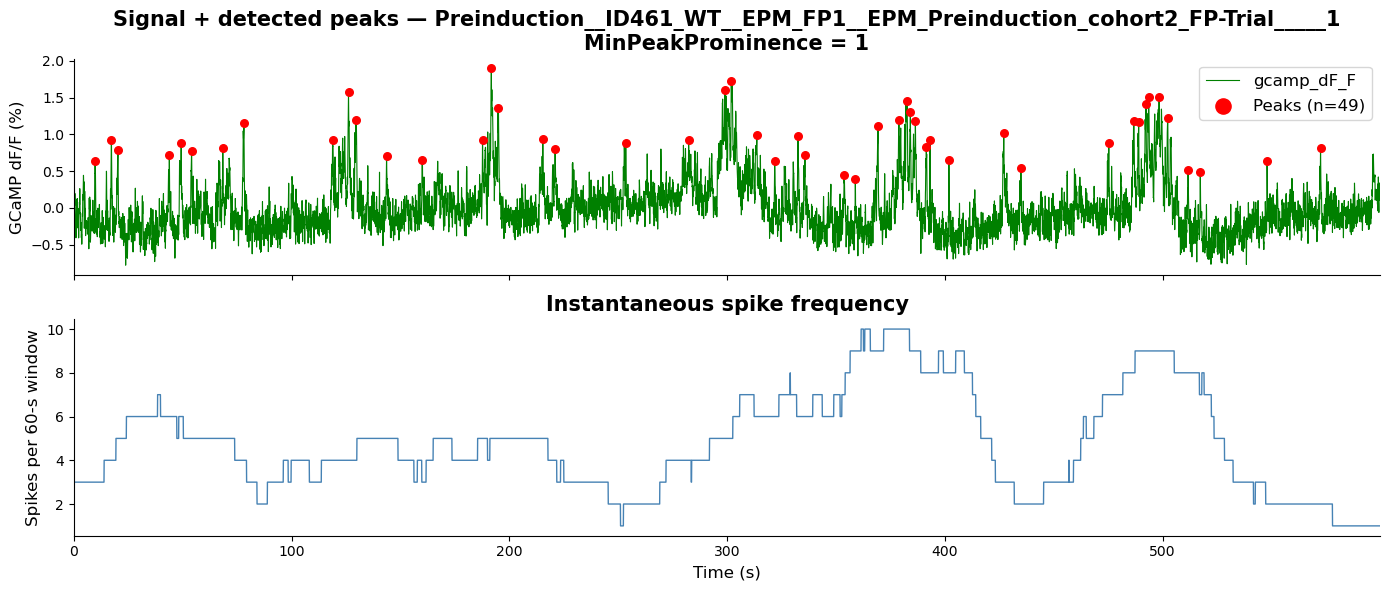

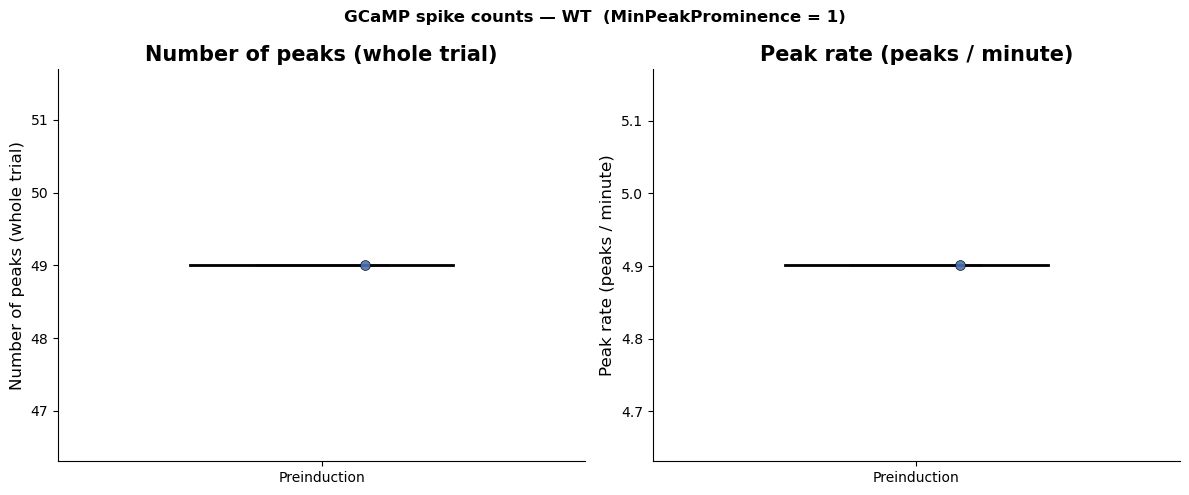


Saved: R_processing/peak_counts_per_trial.csv


In [82]:
# ==========================================================
# PEAK / SPIKE DETECTION
# Python translation of the Neurophotometrics FP3002 guide approach.
#
# Guide (MATLAB):
#   [~, FP.peaks] = findpeaks(FP.data(:,5), 'MinPeakProminence', 0.06)
#   FP.peak_freq = zeros(size(FP.data(:,5)))
#   FP.peak_freq(FP.peaks) = 1
#   plot(movsum(FP.peak_freq, round(FP.fps*60)))   % 60-s sliding window
# ==========================================================
import re
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------- PARAMETERS ----------
MIN_PEAK_PROMINENCE = 1   # NOTE: guide/comment say 0.06 — this is 10x higher. Confirm which you want.
SIGNAL_COL          = "gcamp_dF_F"
GENOTYPE_FILTER     = "WT"   # set to None for all genotypes
WEEKS               = ["Preinduction", "W1", "W2"]
WINDOW_S            = 60     # sliding-window size for instantaneous frequency (seconds)
# --------------------------------

# Normalise week labels
for trial_key, fp_info in fp_traces.items():
    wk = fp_info.get("week", "")
    if not wk:
        m = re.search(r"(Preinduction|W\d+)", trial_key, flags=re.IGNORECASE)
        fp_info["week"] = m.group(1).capitalize() if m else None
    else:
        fp_info["week"] = wk.capitalize()

# ==========================================================
# LOOP: detect peaks + build instantaneous frequency trace
# ==========================================================
rows = []
inst_freq_store = {}      # trial_key -> (time_vec, signal, inst_freq, peaks)
skip_reasons    = Counter()

for trial_key, trial_data in combined_trials.items():

    fp_info   = fp_traces.get(trial_key, {})
    week      = fp_info.get("week")
    mouse_id  = fp_info.get("mouse_id", trial_key)
    genotype  = fp_info.get("genotype")
    condition = fp_info.get("condition")

    # ---- filter gates (counted, not silent) ----
    if not fp_info:
        skip_reasons["no fp_info (key mismatch)"] += 1
        continue
    if week not in WEEKS:
        skip_reasons[f"week={week!r} not in WEEKS"] += 1
        continue
    if GENOTYPE_FILTER and genotype != GENOTYPE_FILTER:
        skip_reasons[f"genotype={genotype!r}"] += 1
        continue
    if SIGNAL_COL not in trial_data.columns:
        skip_reasons["signal col missing"] += 1
        continue

    signal   = trial_data[SIGNAL_COL].values
    time_vec = trial_data["Time_video"].values
    fps      = 1.0 / np.median(np.diff(time_vec))

    # ------------------------------------------------------------------
    # 1. Detect peaks  (guide: findpeaks(..., 'MinPeakProminence', 0.06))
    # ------------------------------------------------------------------
    peaks, _ = find_peaks(signal, prominence=MIN_PEAK_PROMINENCE)

    # ------------------------------------------------------------------
    # 2. Binary spike array  (guide: FP.peak_freq = zeros; FP.peak_freq(peaks) = 1)
    # ------------------------------------------------------------------
    peak_freq = np.zeros(len(signal))
    peak_freq[peaks] = 1

    # ------------------------------------------------------------------
    # 3. Instantaneous frequency  (guide: movsum(FP.peak_freq, round(FP.fps*60)))
    #    MATLAB movsum uses a centred window; pandas rolling center=True matches this.
    # ------------------------------------------------------------------
    window_samples = int(round(fps * WINDOW_S))
    inst_freq = (
        pd.Series(peak_freq)
        .rolling(window=window_samples, center=True, min_periods=1)
        .sum()
        .values
    )

    inst_freq_store[trial_key] = (time_vec, signal, inst_freq, peaks)

    n_peaks           = len(peaks)
    trial_duration_s  = time_vec[-1] - time_vec[0]
    peak_rate_per_min = n_peaks / trial_duration_s * 60

    rows.append({
        "trial_key":         trial_key,
        "mouse_id":          mouse_id,
        "genotype":          genotype,
        "condition":         condition,
        "week":              week,
        "n_peaks":           n_peaks,
        "trial_duration_s":  round(trial_duration_s, 2),
        "peak_rate_per_min": round(peak_rate_per_min, 3),
    })

    print(f"{trial_key:50s}  {n_peaks:3d} peaks  ({peak_rate_per_min:.2f}/min)")

df_peaks = pd.DataFrame(rows)
print(f"\nTotal trials included: {len(df_peaks)}")

# ---- if nothing passed, say why instead of crashing downstream ----
if not inst_freq_store:
    raise RuntimeError(
        "No trials passed the filters, so there is nothing to plot or export.\n"
        f"Skip reasons: {dict(skip_reasons)}\n"
        f"combined_trials keys with no fp_info: "
        f"{list(set(combined_trials) - set(fp_traces))[:10]}"
    )
elif skip_reasons:
    print(f"Skipped {sum(skip_reasons.values())} trial(s): {dict(skip_reasons)}")

# ==========================================================
# GUIDE-STYLE PLOT: signal trace + instantaneous frequency
# (guide: tiledlayout(4,1) — ax1 normalised data, ax2 inst. frequency)
# Shown here for the first trial as a sanity check.
# ==========================================================
example_key = list(inst_freq_store.keys())[0]
t, sig, inst_freq, peaks = inst_freq_store[example_key]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ax1: normalised (corrected) data with peaks marked
ax1.plot(t, sig, color="green", lw=0.8, label=SIGNAL_COL)
ax1.scatter(t[peaks], sig[peaks], color="red", zorder=5, s=30, label=f"Peaks (n={len(peaks)})")
ax1.set_ylabel("GCaMP dF/F (%)")
ax1.set_title(f"Signal + detected peaks — {example_key}\n"
              f"MinPeakProminence = {MIN_PEAK_PROMINENCE}")
ax1.legend(loc="upper right")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ax2: instantaneous spike frequency (movsum equivalent)
ax2.plot(t, inst_freq, color="steelblue", lw=1.0)
ax2.set_ylabel(f"Spikes per {WINDOW_S}-s window")
ax2.set_xlabel("Time (s)")
ax2.set_title("Instantaneous spike frequency")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ==========================================================
# COMPARISON: peak counts across Preinduction / W1 / W2
# ==========================================================
week_order = [w for w in WEEKS if w in df_peaks["week"].unique()]
colors     = {"Preinduction": "#4C72B0", "W1": "#55A868", "W2": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, ylabel in zip(
    axes,
    ["n_peaks", "peak_rate_per_min"],
    ["Number of peaks (whole trial)", "Peak rate (peaks / minute)"]
):
    grouped = [df_peaks.loc[df_peaks["week"] == w, metric].values for w in week_order]

    bp = ax.boxplot(grouped, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    for patch, w in zip(bp["boxes"], week_order):
        patch.set_facecolor(colors.get(w, "grey"))
        patch.set_alpha(0.7)

    rng = np.random.default_rng(42)
    for i, (vals, w) in enumerate(zip(grouped, week_order)):
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jitter, vals,
                   color=colors.get(w, "grey"), zorder=5, s=50, alpha=0.9,
                   edgecolors="black", linewidths=0.5)

    ax.set_xticks(range(1, len(week_order) + 1))
    ax.set_xticklabels(week_order)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    f"GCaMP spike counts — {GENOTYPE_FILTER or 'all genotypes'}  "
    f"(MinPeakProminence = {MIN_PEAK_PROMINENCE})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ==========================================================
# EXPORT FOR R
# ==========================================================
out_dir  = "R_processing"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "peak_counts_per_trial.csv")
df_peaks.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

In [78]:
key = list(combined_trials.keys())[0]
trial_data = combined_trials[key]
fp_info = fp_traces.get(key, {})

print(f"trial key:        {key!r}")
print(f"key in fp_traces? {key in fp_traces}")
print(f"fp_info:          {fp_info}")
print()
print(f"week:             {fp_info.get('week')!r}  -> in WEEKS? {fp_info.get('week') in WEEKS}")
print(f"genotype:         {fp_info.get('genotype')!r}  | GENOTYPE_FILTER = {GENOTYPE_FILTER!r}")
print(f"signal col:       {SIGNAL_COL!r} present? {SIGNAL_COL in trial_data.columns}")
print(f"columns:          {list(trial_data.columns)}")


trial key:        'Preinduction__ID461_WT__EPM_FP1__EPM_Preinduction_cohort2_FP-Trial_____1'
key in fp_traces? True
fp_info:          {'iso':        Time_video  G0_iso415
0         0.02000   0.025181
1         0.06000   0.025314
2         0.10000   0.025165
3         0.14000   0.025175
4         0.18000   0.025189
...           ...        ...
14993   599.73984   0.024748
14994   599.77984   0.024760
14995   599.81984   0.024750
14996   599.85984   0.024802
14997   599.89984   0.024775

[14998 rows x 2 columns], 'gcamp':        Time_video  G0_gcamp470
0         0.00000     0.029073
1         0.04000     0.029003
2         0.08000     0.029127
3         0.12000     0.029096
4         0.16000     0.029093
...           ...          ...
14993   599.71984     0.028504
14994   599.75984     0.028555
14995   599.79984     0.028511
14996   599.83984     0.028540
14997   599.87984     0.028558

[14998 rows x 2 columns], 'mouse_id': '461', 'genotype': 'WT', 'timeline':                           